In [5]:
# 0. Setup: import libraries and define API key

import requests
import pandas as pd

API_KEY = "c0d18a0f217bfb86aeb4a9b089540c9a77a34f5b"

In [6]:
# 1. Constants (dataset configuration)

STATE_FIPS_CA = "06"
ACS_YEAR = 2024
ACS_BASE = f"https://api.census.gov/data/{ACS_YEAR}/acs/acs5"

# Start with one variable (total population)
VARS = ["NAME", "B01003_001E"]

In [7]:
# 2. Pull all California places (sanity test)

params = {
    "get": ",".join(VARS),                     # Variables to retrieve
    "for": "place:*",                          # All places (cities + CDPs)
    "in": f"state:{STATE_FIPS_CA}",            # California (FIPS 06)
    "key": API_KEY                             # Census API key
}

response = requests.get(ACS_BASE, params=params)
response.raise_for_status()

data = response.json()

ca_places = pd.DataFrame(data[1:], columns=data[0])

# Convert population column to numeric
ca_places["B01003_001E"] = pd.to_numeric(
    ca_places["B01003_001E"], errors="coerce"
)

ca_places.head()

,NAME,B01003_001E,state,place
0,"Acalanes Ridge CDP, California",1006,06,00135
1,"Acampo CDP, California",234,06,00156
2,"Acton CDP, California",7880,06,00212
3,"Adelanto city, California",37964,06,00296
4,"Adin CDP, California",153,06,00310


In [9]:
# 3. Load in unfiltered dataset

zvhi = pd.read_excel("Ca_Zip_Home_Value.xlsx", header=1)
zvhi.head(2)

,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,1/31/2000,...,4/30/2025,5/31/2025,6/30/2025,7/31/2025,8/31/2025,9/30/2025,10/31/2025,11/30/2025,12/31/2025,1/31/2026
0,91982,1,77494,zip,TX,TX,Katy,"Houston-The Woodlands-Sugar Land, TX",Fort Bend County,204988.3686,...,486136.1090,484000.3527,481473.2672,479455.2354,478365.6216,478562.4520,479293.4729,480341.6326,480930.8672,480543.6336
1,61148,2,8701,zip,NJ,NJ,Lakewood,"New York-Newark-Jersey City, NY-NJ-PA",Ocean County,111719.9414,...,529389.7484,532145.3507,534655.0414,536426.4444,537661.4257,540194.5829,545049.8352,550925.6822,557122.8387,561559.0286


In [10]:
# 4. Filter ZVHI to CA + (San Diego County OR Los Angeles County) and extract unique city names

zvhi_ca = zvhi[zvhi["State"] == "CA"].copy()

zvhi_sd_la = zvhi_ca[zvhi_ca["CountyName"].isin(["San Diego County", "Los Angeles County"])].copy()

zvhi_city_names = sorted(zvhi_sd_la["City"].dropna().unique())

len(zvhi_city_names), zvhi_city_names[:25]

(135,
 ['Acton',
  'Agoura Hills',
  'Alhambra',
  'Alpine',
  'Altadena',
  'Arcadia',
  'Artesia',
  'Avalon',
  'Azusa',
  'Baldwin Park',
  'Bell',
  'Bellflower',
  'Beverly Hills',
  'Bonita',
  'Bonsall',
  'Boulevard',
  'Bradbury',
  'Burbank',
  'Calabasas',
  'Campo',
  'Carlsbad',
  'Carson',
  'Castaic',
  'Cerritos',
  'Chula Vista'])

In [11]:
# 5. Create ACS-style city name format from Zillow city list
    # This makes the ZHVI cities match the ACS city format

zvhi_city_names_acs = [
    f"{city} city, California"
    for city in zvhi_city_names
]

zvhi_city_names_acs[:20]

['Acton city, California',
 'Agoura Hills city, California',
 'Alhambra city, California',
 'Alpine city, California',
 'Altadena city, California',
 'Arcadia city, California',
 'Artesia city, California',
 'Avalon city, California',
 'Azusa city, California',
 'Baldwin Park city, California',
 'Bell city, California',
 'Bellflower city, California',
 'Beverly Hills city, California',
 'Bonita city, California',
 'Bonsall city, California',
 'Boulevard city, California',
 'Bradbury city, California',
 'Burbank city, California',
 'Calabasas city, California',
 'Campo city, California']

In [12]:
# 6. Check how many Zillow cities match ACS places, should be 135
    # 94/135 match

matches = ca_places[ca_places["NAME"].isin(zvhi_city_names_acs)]

len(matches), matches.head()

(94,
                              NAME  B01003_001E state  place
 5   Agoura Hills city, California        19721    06  00394
 15      Alhambra city, California        81022    06  00884
 49       Arcadia city, California        55170    06  02462
 56       Artesia city, California        15889    06  02896
 68        Avalon city, California         3338    06  03274)

In [13]:
# 6a. Single step: report unmatched cities from the simple "City city, California" mapping
    # this shows 30/41 missing cities are CDP (unincorporated)
acs_names = set(ca_places["NAME"].astype(str))
zvhi_raw = sorted(zvhi_city_names)                            # raw city names from Zillow
zvhi_acs = [f"{c} city, California" for c in zvhi_raw]       # current ACS-style list

unmatched = [city for city, acs in zip(zvhi_raw, zvhi_acs) if acs not in acs_names]

print("total_zillow_cities =", len(zvhi_raw))
print("matched_with_simple_city_suffix =", len(zvhi_raw) - len(unmatched))
print("unmatched_count =", len(unmatched))
print("\nFirst 30 unmatched (sample):")
print(unmatched[:30])

total_zillow_cities = 135
matched_with_simple_city_suffix = 94
unmatched_count = 41

First 30 unmatched (sample):
['Acton', 'Alpine', 'Altadena', 'Bonita', 'Bonsall', 'Boulevard', 'Campo', 'Castaic', 'Descanso', 'Dulzura', 'East Los Angeles', 'Fallbrook', 'Florence-Graham', 'Hacienda Heights', 'Jacumba', 'Jamul', 'Julian', 'La Canada Flintridge', 'La Crescenta-Montrose', 'Ladera Heights', 'Lake Hughes', 'Lakeside', 'Littlerock', 'Llano', 'Marina del Rey', 'Pala', 'Palomar Mountain', 'Pauma Valley', 'Pearblossom', 'Ramona']


In [14]:
# 6b. Check which unmatched cities exist as CDPs in ACS
    # prints the 30 CDP's
cdp_matches = []

for city in unmatched:
    candidate = f"{city} CDP, California"
    if candidate in acs_names:
        cdp_matches.append(candidate)

len(cdp_matches), cdp_matches[:20]

(30,
 ['Acton CDP, California',
  'Alpine CDP, California',
  'Altadena CDP, California',
  'Bonita CDP, California',
  'Bonsall CDP, California',
  'Boulevard CDP, California',
  'Campo CDP, California',
  'Castaic CDP, California',
  'Descanso CDP, California',
  'East Los Angeles CDP, California',
  'Fallbrook CDP, California',
  'Florence-Graham CDP, California',
  'Hacienda Heights CDP, California',
  'Jacumba CDP, California',
  'Jamul CDP, California',
  'Julian CDP, California',
  'La Crescenta-Montrose CDP, California',
  'Ladera Heights CDP, California',
  'Lake Hughes CDP, California',
  'Littlerock CDP, California'])

In [15]:
# 6c. Remove CDP-resolved cities from unmatched
    # prints the 11 nonCDP's
resolved_cdp_cities = [name.replace(" CDP, California", "") for name in cdp_matches]

still_unmatched = [city for city in unmatched if city not in resolved_cdp_cities]

len(still_unmatched), still_unmatched

(11,
 ['Dulzura',
  'La Canada Flintridge',
  'Lakeside',
  'Llano',
  'Palomar Mountain',
  'Pauma Valley',
  'Pearblossom',
  'Ranchita',
  'Santa Ysabel',
  'Spring Valley',
  'Warner Springs'])

In [16]:
# 6d. Single step: normalized-match the remaining unmatched cities against ACS names
    # normalization
import re

def normalize(s):
    s = s.lower()
    s = re.sub(r"[^a-z0-9\s]", " ", s)
    s = re.sub(r"\b(city|cdp|town|village)\b", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

acs_norm_map = {}
for a in acs_names:
    acs_norm_map.setdefault(normalize(a), []).append(a)

still_unmatched = ['Dulzura','La Canada Flintridge','Lakeside','Llano',
                   'Palomar Mountain','Pauma Valley','Pearblossom',
                   'Ranchita','Santa Ysabel','Spring Valley','Warner Springs']

results = {}
for city in still_unmatched:
    n = normalize(city)
    results[city] = acs_norm_map.get(n, [])

results

{'Dulzura': [],
 'La Canada Flintridge': [],
 'Lakeside': [],
 'Llano': [],
 'Palomar Mountain': [],
 'Pauma Valley': [],
 'Pearblossom': [],
 'Ranchita': [],
 'Santa Ysabel': [],
 'Spring Valley': [],
 'Warner Springs': []}

In [17]:
# 6e. Final ACS-matched Zillow cities (city + CDP)
final_acs_names = set(matches["NAME"]).union(set(cdp_matches))

len(final_acs_names)

124

In [18]:
# 7. Final ACS subset aligned with Zillow cities
    # 124, 4
        # This drops the 11 non census cities to make the list 124 cities

final_acs_df = ca_places[ca_places["NAME"].isin(final_acs_names)].copy()

final_acs_df.shape

(124, 4)

In [19]:
# 8. Create GEOID for consistent merging across years
    # creates clean geographic ID that's reusable across all years

final_acs_df["GEOID"] = final_acs_df["state"] + final_acs_df["place"]

final_acs_df = final_acs_df[["GEOID", "NAME", "B01003_001E"]]

final_acs_df.head()

,GEOID,NAME,B01003_001E
2,0600212,"Acton CDP, California",7880
5,0600394,"Agoura Hills city, California",19721
15,0600884,"Alhambra city, California",81022
24,0601192,"Alpine CDP, California",15180
27,0601290,"Altadena CDP, California",41705


In [20]:
# 9. Define ACS 5-year panel years

years = list(range(2009, 2025))
years

[2009,
 2010,
 2011,
 2012,
 2013,
 2014,
 2015,
 2016,
 2017,
 2018,
 2019,
 2020,
 2021,
 2022,
 2023,
 2024]

In [21]:
# 9a. Pull ACS total population (B01003_001E) for 2009-2024 into a panel keyed by GEOID
    # Merge w 2009-2024 Population numbers
import time

years = list(range(2009, 2025))
vars_to_get = ["NAME", "B01003_001E"]   # name + total population
panel_df = final_acs_df[["GEOID", "NAME"]].set_index("GEOID").copy()

for yr in years:
    BASE = f"https://api.census.gov/data/{yr}/acs/acs5"
    params = {
        "get": ",".join(vars_to_get),
        "for": "place:*",
        "in": f"state:{STATE_FIPS_CA}",
        "key": API_KEY
    }
    print(f"Fetching {yr}...", end=" ", flush=True)
    r = requests.get(BASE, params=params)
    r.raise_for_status()
    data = r.json()
    df = pd.DataFrame(data[1:], columns=data[0])
    # create GEOID and keep only places we care about
    df["GEOID"] = df["state"] + df["place"]
    df["B01003_001E"] = pd.to_numeric(df["B01003_001E"], errors="coerce")
    df_sub = df.set_index("GEOID")[["NAME", "B01003_001E"]].reindex(panel_df.index)
    panel_df[f"pop_{yr}"] = df_sub["B01003_001E"]
    print("done")
    time.sleep(1)  # polite pause to avoid hammering the API

# quick checks
panel_df.reset_index(inplace=True)
print("\npanel shape:", panel_df.shape)
panel_df.head()

Fetching 2009... done
Fetching 2010... done
Fetching 2011... done
Fetching 2012... done
Fetching 2013... done
Fetching 2014... done
Fetching 2015... done
Fetching 2016... done
Fetching 2017... done
Fetching 2018... done
Fetching 2019... done
Fetching 2020... done
Fetching 2021... done
Fetching 2022... done
Fetching 2023... done
Fetching 2024... done

panel shape: (124, 18)


,GEOID,NAME,pop_2009,pop_2010,pop_2011,pop_2012,pop_2013,pop_2014,pop_2015,pop_2016,pop_2017,pop_2018,pop_2019,pop_2020,pop_2021,pop_2022,pop_2023,pop_2024
0,0600212,"Acton CDP, California",1804.0,7150.0,7138.0,7117.0,7022.0,6956.0,7058,7170,7278,7185,7232,7054,6809,7286,7721,7880
1,0600394,"Agoura Hills city, California",22207.0,20328.0,20353.0,20431.0,20488.0,20630.0,20697,20689,20736,20636,20533,20269,20362,20088,19881,19721
2,0600884,"Alhambra city, California",84959.0,83389.0,83301.0,83513.0,83799.0,84400.0,84782,84866,85168,84974,84647,84509,83174,82295,81483,81022
3,0601192,"Alpine CDP, California",12627.0,13326.0,13332.0,13511.0,13717.0,14580.0,14830,15188,14795,15233,14878,14958,15648,15911,15470,15180
4,0601290,"Altadena CDP, California",44693.0,45446.0,45006.0,44578.0,45015.0,44622.0,44621,45001,45236,45146,44850,43037,43384,42719,41921,41705


In [22]:
# 10. Convert population panel to long format

panel_long = panel_df.melt(
    id_vars=["GEOID", "NAME"],
    var_name="year",
    value_name="population"
)

# Clean year column
panel_long["year"] = panel_long["year"].str.replace("pop_", "").astype(int)

panel_long.head()

,GEOID,NAME,year,population
0,0600212,"Acton CDP, California",2009,1804.0
1,0600394,"Agoura Hills city, California",2009,22207.0
2,0600884,"Alhambra city, California",2009,84959.0
3,0601192,"Alpine CDP, California",2009,12627.0
4,0601290,"Altadena CDP, California",2009,44693.0


In [23]:
# 11. Create mapping from normalized city name to GEOID
    # confirm the city + unique GEOID works
def normalize_city(s):
    return s.lower().replace(" city, california", "").replace(" cdp, california", "").strip()

acs_lookup = {
    normalize_city(name): geoid
    for geoid, name in zip(panel_df["GEOID"], panel_df["NAME"])
}

list(acs_lookup.items())[:10]

[('acton', '0600212'),
 ('agoura hills', '0600394'),
 ('alhambra', '0600884'),
 ('alpine', '0601192'),
 ('altadena', '0601290'),
 ('arcadia', '0602462'),
 ('artesia', '0602896'),
 ('avalon', '0603274'),
 ('azusa', '0603386'),
 ('baldwin park', '0603666')]

In [24]:
# 12. Attach ACS GEOID to each Zillow row using Zillow City
    # Attach unique GEOID to each Zillow city

zvhi_sd_la["city_norm"] = zvhi_sd_la["City"].astype(str).str.lower().str.strip()
zvhi_sd_la["GEOID"] = zvhi_sd_la["city_norm"].map(acs_lookup)

# Check match rate
total = len(zvhi_sd_la)
matched = zvhi_sd_la["GEOID"].notna().sum()
unmatched = total - matched

total, matched, unmatched

(369, np.int64(357), np.int64(12))

In [25]:
# 12a. Show Zillow city names that did not map to an ACS GEOID
sorted(
    zvhi_sd_la.loc[
        zvhi_sd_la["GEOID"].isna(),
        "City"
    ].unique()
)

['Dulzura',
 'La Canada Flintridge',
 'Lakeside',
 'Llano',
 'Palomar Mountain',
 'Pauma Valley',
 'Pearblossom',
 'Ranchita',
 'Santa Ysabel',
 'Spring Valley',
 'Warner Springs']

In [26]:
# 13. Remove ZIP rows that do not map to ACS places
    # dropped these 11 cities from the df

zvhi_aligned = zvhi_sd_la[zvhi_sd_la["GEOID"].notna()].copy()

zvhi_aligned.shape

(357, 324)

In [27]:
# 14. Raw ACS columns required to construct the 18 modeled variables

acs_vars = [

    # --------------------------------------------------
    # 1. Median household income
    # --------------------------------------------------
    "B19013_001E",  # Median household income (USD)

    # --------------------------------------------------
    # 2. Per capita income
    # --------------------------------------------------
    "B19301_001E",  # Per capita income (USD)

    # --------------------------------------------------
    # 3. Poverty rate (derived)
    # poverty_rate = below_poverty / poverty_universe
    # --------------------------------------------------
    "B17001_001E",  # Total population for whom poverty status is determined
    "B17001_002E",  # Population below poverty line

    # --------------------------------------------------
    # 4. Unemployment rate (derived)
    # unemployment_rate = unemployed / labor_force
    # --------------------------------------------------
    "B23025_003E",  # Civilian labor force
    "B23025_005E",  # Unemployed population

    # --------------------------------------------------
    # 5. Total population
    # --------------------------------------------------
    "B01003_001E",  # Total population

    # --------------------------------------------------
    # 7. Median age
    # --------------------------------------------------
    "B01002_001E",  # Median age (years)

    # --------------------------------------------------
    # 8. % Bachelor’s degree or higher (derived)
    # bachelors_or_higher = sum(bachelor+ degrees) / total 25+
    # --------------------------------------------------
    "B15003_001E",  # Total population age 25+
    "B15003_022E",  # Bachelor's degree
    "B15003_023E",  # Master's degree
    "B15003_024E",  # Professional degree
    "B15003_025E",  # Doctorate degree

    # --------------------------------------------------
    # 10. Total housing units
    # --------------------------------------------------
    "B25001_001E",  # Total housing units

    # --------------------------------------------------
    # 12. Vacancy rate (derived)
    # vacancy_rate = vacant_units / total_units
    # --------------------------------------------------
    "B25002_001E",  # Total housing units
    "B25002_003E",  # Vacant housing units

    # --------------------------------------------------
    # 13. Owner-occupied rate (derived)
    # owner_rate = owner_occupied / total_occupied
    # --------------------------------------------------
    "B25003_001E",  # Total occupied housing units
    "B25003_002E",  # Owner-occupied units

    # --------------------------------------------------
    # 14. % Built after 2000 (derived)
    # built_after_2000 = units_2000+ / total_units
    # --------------------------------------------------
    "B25034_001E",  # Total housing units (by year built)
    "B25034_010E",  # Built 2000–2009
    "B25034_011E",  # Built 2010 or later

    # --------------------------------------------------
    # 15. % Single-family detached (derived)
    # single_family_rate = detached_units / total_units
    # --------------------------------------------------
    "B25024_001E",  # Total housing units (by structure type)
    "B25024_002E",  # 1-unit detached structure

    # --------------------------------------------------
    # 16. Median home value
    # --------------------------------------------------
    "B25077_001E",  # Median home value (USD)

    # --------------------------------------------------
    # 17. Median gross rent
    # --------------------------------------------------
    "B25064_001E",  # Median gross rent (USD)

    # --------------------------------------------------
    # 18. % Owners cost-burdened (derived)
    # cost_burden_rate = owners paying >30% income on housing / total owners
    # --------------------------------------------------
    "B25091_001E",  # Total owner-occupied units with mortgage
    "B25091_010E",  # Owners paying 30–34.9%
    "B25091_011E",  # Owners paying 35–39.9%
    "B25091_012E"   # Owners paying 40%+
]

len(acs_vars)

29

In [28]:
# 15. Pull ACS 5-year place-level data for 2009–2022,
#     automatically requesting only the variables that exist in each year.
#     Missing vars for early years will be created as NaN so columns align.

years = list(range(2009, 2023))  # 2009–2022

# ---------------------------------------------
# Helper 1: pick a working ACS5 endpoint for a year
# ---------------------------------------------
def get_acs5_base_url(year: int) -> str:
    candidates = [
        f"https://api.census.gov/data/{year}/acs/acs5",
        f"https://api.census.gov/data/{year}/acs5",
    ]
    for url in candidates:
        test = requests.get(url, params={"get": "NAME", "for": "place:*", "in": "state:06"})
        if test.status_code == 200:
            return url
    raise ValueError(f"No working ACS5 endpoint found for year {year}")

# ---------------------------------------------
# Helper 2: load that year's variable dictionary
# (this tells us what variables are valid for that year)
# ---------------------------------------------
def get_year_variable_set(year: int, base_url: str) -> set:
    vars_url = base_url + "/variables.json"
    r = requests.get(vars_url)
    if r.status_code != 200:
        raise ValueError(f"Could not fetch variables.json for {year} from {vars_url}")
    j = r.json()
    return set(j["variables"].keys())

acs_all_years = []

for year in years:
    print(f"Pulling {year}...")

    base_url = get_acs5_base_url(year)

    # Identify which of our desired raw vars actually exist for this year
    var_set = get_year_variable_set(year, base_url)
    available_vars = [v for v in acs_vars if v in var_set]
    missing_vars = [v for v in acs_vars if v not in var_set]

    # Show a short warning if anything is missing (expected in early years)
    if missing_vars:
        print(f"  {year}: missing {len(missing_vars)} vars (will be NaN). Example: {missing_vars[:3]}")

    # Request ONLY the vars that exist for this year
    params = {
        "get": ",".join(["NAME"] + available_vars),
        "for": "place:*",
        "in": "state:06",
        "key": API_KEY
    }

    response = requests.get(base_url, params=params)
    if response.status_code != 200:
        print(f"  Error {response.status_code} for {year} using {base_url}")
        print(" ", response.text[:300])
        continue  # skip this year, try the next

    data = response.json()
    df = pd.DataFrame(data[1:], columns=data[0])

    # Convert pulled ACS numeric columns to numeric
    for col in available_vars:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Create missing columns (so every year has the same set of raw vars)
    for col in missing_vars:
        df[col] = pd.NA

    # Add year
    df["year"] = year

    # Reorder columns consistently
    df = df[["NAME"] + acs_vars + ["state", "place", "year"]]

    acs_all_years.append(df)

# Combine all years we successfully pulled
acs_raw_panel = pd.concat(acs_all_years, ignore_index=True)

acs_raw_panel.shape

Pulling 2009...
  2009: missing 8 vars (will be NaN). Example: ['B23025_003E', 'B23025_005E', 'B15003_001E']
Pulling 2010...
  2010: missing 8 vars (will be NaN). Example: ['B23025_003E', 'B23025_005E', 'B15003_001E']
Pulling 2011...
  2011: missing 6 vars (will be NaN). Example: ['B15003_001E', 'B15003_022E', 'B15003_023E']
Pulling 2012...
  2012: missing 1 vars (will be NaN). Example: ['B25034_011E']
Pulling 2013...
  2013: missing 1 vars (will be NaN). Example: ['B25034_011E']
Pulling 2014...
  2014: missing 1 vars (will be NaN). Example: ['B25034_011E']
Pulling 2015...
Pulling 2016...
Pulling 2017...
Pulling 2018...
Pulling 2019...
Pulling 2020...
Pulling 2021...
Pulling 2022...


(21103, 33)

In [29]:
# 16. Construct the 18 modeled variables from the raw ACS panel
#     - Computes rates safely (avoids divide-by-zero)
#     - Renames columns to readable names
#     - Adds population_growth and housing_unit_growth using year-over-year change

import numpy as np

acs = acs_raw_panel.copy()

# -----------------------------
# Helper: safe divide (returns NaN if denom is 0/NaN)
# -----------------------------
def safe_div(numer, denom):
    numer = pd.to_numeric(numer, errors="coerce")
    denom = pd.to_numeric(denom, errors="coerce")
    return np.where((denom == 0) | (pd.isna(denom)), np.nan, numer / denom)

# -----------------------------
# 1–5, 7, 10, 16–17: direct pulls (rename)
# -----------------------------
acs["median_household_income"] = acs["B19013_001E"]   # 1
acs["per_capita_income"]       = acs["B19301_001E"]   # 2
acs["total_population"]        = acs["B01003_001E"]   # 5
acs["median_age"]              = acs["B01002_001E"]   # 7
acs["total_housing_units"]     = acs["B25001_001E"]   # 10
acs["median_home_value_acs"]   = acs["B25077_001E"]   # 16
acs["median_gross_rent"]       = acs["B25064_001E"]   # 17

# -----------------------------
# 3. Poverty rate
# -----------------------------
acs["poverty_rate"] = safe_div(acs["B17001_002E"], acs["B17001_001E"])  # 3

# -----------------------------
# 4. Unemployment rate
# -----------------------------
acs["unemployment_rate"] = safe_div(acs["B23025_005E"], acs["B23025_003E"])  # 4

# -----------------------------
# 8. % bachelor’s degree or higher (25+)
# -----------------------------
bachelors_or_higher_num = (
    pd.to_numeric(acs["B15003_022E"], errors="coerce") +  # bachelor's
    pd.to_numeric(acs["B15003_023E"], errors="coerce") +  # master's
    pd.to_numeric(acs["B15003_024E"], errors="coerce") +  # professional
    pd.to_numeric(acs["B15003_025E"], errors="coerce")    # doctorate
)
acs["pct_bachelors_or_higher"] = safe_div(bachelors_or_higher_num, acs["B15003_001E"])  # 8

# -----------------------------
# 9. % graduate degree (25+)
# -----------------------------
grad_num = (
    pd.to_numeric(acs["B15003_023E"], errors="coerce") +  # master's
    pd.to_numeric(acs["B15003_024E"], errors="coerce") +  # professional
    pd.to_numeric(acs["B15003_025E"], errors="coerce")    # doctorate
)
acs["pct_graduate_degree"] = safe_div(grad_num, acs["B15003_001E"])  # 9

# -----------------------------
# 12. Vacancy rate
# -----------------------------
acs["vacancy_rate"] = safe_div(acs["B25002_003E"], acs["B25002_001E"])  # 12

# -----------------------------
# 13. Owner-occupied rate (share of occupied units)
# -----------------------------
acs["owner_occupied_rate"] = safe_div(acs["B25003_002E"], acs["B25003_001E"])  # 13

# -----------------------------
# 14. % built after 2000
# -----------------------------
built_after_2000_num = (
    pd.to_numeric(acs["B25034_010E"], errors="coerce") +  # 2000-2009
    pd.to_numeric(acs["B25034_011E"], errors="coerce")    # 2010+
)
acs["pct_built_after_2000"] = safe_div(built_after_2000_num, acs["B25034_001E"])  # 14

# -----------------------------
# 15. % single-family detached
# -----------------------------
acs["pct_single_family_detached"] = safe_div(acs["B25024_002E"], acs["B25024_001E"])  # 15

# -----------------------------
# 18. % owners cost-burdened (>30%)
# NOTE: Using B25091 (owners w/ mortgage). Early years may be NaN (API missing vars).
# -----------------------------
cost_burden_num = (
    pd.to_numeric(acs["B25091_010E"], errors="coerce") +
    pd.to_numeric(acs["B25091_011E"], errors="coerce") +
    pd.to_numeric(acs["B25091_012E"], errors="coerce")
)
acs["pct_owners_cost_burdened"] = safe_div(cost_burden_num, acs["B25091_001E"])  # 18

# -----------------------------
# 6. Population growth (YoY, derived from panel)
# 11. Housing unit growth (YoY, derived from panel)
# Compute within each place across years
# -----------------------------
acs = acs.sort_values(["state", "place", "year"])

acs["population_growth"] = (
    acs.groupby(["state", "place"])["total_population"]
       .pct_change()
)

acs["housing_unit_growth"] = (
    acs.groupby(["state", "place"])["total_housing_units"]
       .pct_change()
)

# -----------------------------
# Keep only the final 18 variables + identifiers
# -----------------------------
acs_features = acs[[
    "NAME", "state", "place", "year",

    # 1–4
    "median_household_income",
    "per_capita_income",
    "poverty_rate",
    "unemployment_rate",

    # 5–7
    "total_population",
    "population_growth",
    "median_age",

    # 8–9
    "pct_bachelors_or_higher",
    "pct_graduate_degree",

    # 10–15
    "total_housing_units",
    "housing_unit_growth",
    "vacancy_rate",
    "owner_occupied_rate",
    "pct_built_after_2000",
    "pct_single_family_detached",

    # 16–18
    "median_home_value_acs",
    "median_gross_rent",
    "pct_owners_cost_burdened"
]].copy()

acs_features.shape

(21103, 22)

In [30]:
# 17. Keep only ACS rows for the places (cities) that appear in zvhi_aligned via GEOID

# GEOID in your workflow is the 7-digit place GEOID stored as a string
# ACS uses state + place; GEOID = state + place (for CA, state='06')

# Build the set of GEOIDs present in your Zillow-aligned dataset
geoids_used = set(zvhi_aligned["GEOID"].dropna().astype(str))

# Create GEOID in ACS features to filter with the same key
acs_features["GEOID"] = acs_features["state"].astype(str) + acs_features["place"].astype(str)

# Filter down to only the mapped cities
acs_features_sdla = acs_features[acs_features["GEOID"].isin(geoids_used)].copy()

# Sanity checks
print("Unique GEOIDs in Zillow:", len(geoids_used))
print("Unique GEOIDs in ACS after filter:", acs_features_sdla["GEOID"].nunique())
acs_features_sdla.shape

Unique GEOIDs in Zillow: 124
Unique GEOIDs in ACS after filter: 124


(1722, 23)

In [31]:
# 18. Build monthly ZHVI panel + merge annual ACS features
#     - ZHVI stays monthly (no aggregation)
#     - We add a derived 'year' column from the monthly date
#     - Merge ACS on GEOID + year so each month inherits that year's ACS values

# ---------------------------------------------------------
# A) Identify ID columns and monthly ZHVI date columns
# ---------------------------------------------------------
id_cols = ["RegionID", "City", "CountyName", "State", "GEOID"]

# Date columns in your Zillow file are strings like "2018-01-31" (or similar)
date_cols = [c for c in zvhi_aligned.columns if isinstance(c, str) and c[:4].isdigit()]

print("ID cols found:", [c for c in id_cols if c in zvhi_aligned.columns])
print("Number of monthly ZHVI columns:", len(date_cols))
print("First 3 date cols:", date_cols[:3])
print("Last 3 date cols:", date_cols[-3:])

# ---------------------------------------------------------
# B) Convert ZHVI from wide format to long format (monthly rows)
#     wide: one row per city with many date columns
#     long: one row per city-month
# ---------------------------------------------------------
zvhi_long = zvhi_aligned[id_cols + date_cols].melt(
    id_vars=id_cols,
    value_vars=date_cols,
    var_name="date",
    value_name="zhvi"
)

# ---------------------------------------------------------
# C) Parse the 'date' strings into real datetimes and create 'year'
#     - This does NOT change monthly ZHVI values
#     - It only adds a merge key for annual ACS data
# ---------------------------------------------------------
zvhi_long["date"] = pd.to_datetime(zvhi_long["date"], errors="coerce")
zvhi_long = zvhi_long.dropna(subset=["date"]).copy()

zvhi_long["year"] = zvhi_long["date"].dt.year

# ---------------------------------------------------------
# D) Ensure GEOID/year types match on both datasets
#     - Prevents silent merge failures due to dtype mismatch
# ---------------------------------------------------------
zvhi_long["GEOID"] = zvhi_long["GEOID"].astype(str)
zvhi_long["year"] = zvhi_long["year"].astype(int)

acs_features_sdla["GEOID"] = acs_features_sdla["GEOID"].astype(str)
acs_features_sdla["year"] = acs_features_sdla["year"].astype(int)

# ---------------------------------------------------------
# E) Merge annual ACS features onto monthly ZHVI rows
#     - Each month in a given year receives the same ACS values for that year
# ---------------------------------------------------------
zvhi_with_acs = zvhi_long.merge(
    acs_features_sdla.drop(columns=["NAME", "state", "place"]),
    on=["GEOID", "year"],
    how="left"
)

# ---------------------------------------------------------
# F) Sanity checks: confirm row counts and missingness
# ---------------------------------------------------------
print("ZHVI long shape:", zvhi_long.shape)
print("After merge shape:", zvhi_with_acs.shape)

# Pick one ACS feature as a match indicator
match_indicator = "median_household_income"
if match_indicator in zvhi_with_acs.columns:
    print("ACS missing rate (median_household_income):",
          zvhi_with_acs[match_indicator].isna().mean())
else:
    print(f"Warning: '{match_indicator}' not found in merged df")

zvhi_with_acs.head()

ID cols found: ['RegionID', 'City', 'CountyName', 'State', 'GEOID']
Number of monthly ZHVI columns: 0
First 3 date cols: []
Last 3 date cols: []
ZHVI long shape: (0, 8)
After merge shape: (0, 26)
ACS missing rate (median_household_income): nan


,RegionID,City,CountyName,State,GEOID,date,zhvi,year,median_household_income,per_capita_income,...,pct_graduate_degree,total_housing_units,housing_unit_growth,vacancy_rate,owner_occupied_rate,pct_built_after_2000,pct_single_family_detached,median_home_value_acs,median_gross_rent,pct_owners_cost_burdened


In [32]:
# 18A. Inspect columns to identify the ZHVI monthly time-series column naming pattern

cols = zvhi_aligned.columns.astype(str).tolist()

print("Total columns:", len(cols))
print("First 30 columns:", cols[:30])
print("Last 30 columns:", cols[-30:])

# Show columns that contain a year-like pattern anywhere (e.g., '2018', '2020')
year_like = [c for c in cols if "20" in c]
print("Count of columns containing '20':", len(year_like))
print("Sample of columns containing '20':", year_like[:20])

Total columns: 324
First 30 columns: ['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName', 'State', 'City', 'Metro', 'CountyName', '1/31/2000', '2/29/2000', '3/31/2000', '4/30/2000', '5/31/2000', '6/30/2000', '7/31/2000', '8/31/2000', '9/30/2000', '10/31/2000', '11/30/2000', '12/31/2000', '1/31/2001', '2/28/2001', '3/31/2001', '4/30/2001', '5/31/2001', '6/30/2001', '7/31/2001', '8/31/2001', '9/30/2001']
Last 30 columns: ['10/31/2023', '11/30/2023', '12/31/2023', '1/31/2024', '2/29/2024', '3/31/2024', '4/30/2024', '5/31/2024', '6/30/2024', '7/31/2024', '8/31/2024', '9/30/2024', '10/31/2024', '11/30/2024', '12/31/2024', '1/31/2025', '2/28/2025', '3/31/2025', '4/30/2025', '5/31/2025', '6/30/2025', '7/31/2025', '8/31/2025', '9/30/2025', '10/31/2025', '11/30/2025', '12/31/2025', '1/31/2026', 'city_norm', 'GEOID']
Count of columns containing '20': 313
Sample of columns containing '20': ['1/31/2000', '2/29/2000', '3/31/2000', '4/30/2000', '5/31/2000', '6/30/2000', '7/31/2000', '8/

In [33]:
# 18B. Identify monthly ZHVI date columns in MM/DD/YYYY format

id_cols = ["RegionID", "City", "CountyName", "State", "GEOID"]

# Date columns look like '1/31/2000' so detect by the presence of '/'
date_cols = [c for c in zvhi_aligned.columns if isinstance(c, str) and "/" in c]

print("Monthly date columns:", len(date_cols))
print("First 3:", date_cols[:3])
print("Last 3:", date_cols[-3:])

Monthly date columns: 313
First 3: ['1/31/2000', '2/29/2000', '3/31/2000']
Last 3: ['11/30/2025', '12/31/2025', '1/31/2026']


In [34]:
# 18C. Wide -> long (monthly), add year, merge ACS

# --- wide to long ---
zvhi_long = zvhi_aligned[id_cols + date_cols].melt(
    id_vars=id_cols,
    value_vars=date_cols,
    var_name="date",
    value_name="zhvi"
)

# --- parse date + derive year (ZHVI remains monthly) ---
zvhi_long["date"] = pd.to_datetime(zvhi_long["date"], format="%m/%d/%Y", errors="coerce")
zvhi_long = zvhi_long.dropna(subset=["date"]).copy()
zvhi_long["year"] = zvhi_long["date"].dt.year.astype(int)

# --- type alignment for merge keys ---
zvhi_long["GEOID"] = zvhi_long["GEOID"].astype(str)
acs_features_sdla["GEOID"] = acs_features_sdla["GEOID"].astype(str)

# --- merge annual ACS onto monthly ZHVI using GEOID + year ---
zvhi_with_acs = zvhi_long.merge(
    acs_features_sdla.drop(columns=["NAME", "state", "place"]),
    on=["GEOID", "year"],
    how="left"
)

# --- sanity checks ---
print("ZHVI long shape:", zvhi_long.shape)
print("After merge shape:", zvhi_with_acs.shape)
print("ACS missing rate (median_household_income):", zvhi_with_acs["median_household_income"].isna().mean())

zvhi_with_acs.head()

ZHVI long shape: (111741, 8)
After merge shape: (111741, 26)
ACS missing rate (median_household_income): 0.4651918275297339


,RegionID,City,CountyName,State,GEOID,date,zhvi,year,median_household_income,per_capita_income,...,pct_graduate_degree,total_housing_units,housing_unit_growth,vacancy_rate,owner_occupied_rate,pct_built_after_2000,pct_single_family_detached,median_home_value_acs,median_gross_rent,pct_owners_cost_burdened
0,95992,Los Angeles,Los Angeles County,CA,0644000,2000-01-31,115350.92,2000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,96193,Norwalk,Los Angeles County,CA,0652526,2000-01-31,156967.64,2000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,96361,Los Angeles,Los Angeles County,CA,0644000,2000-01-31,122178.14,2000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,96025,Los Angeles,Los Angeles County,CA,0644000,2000-01-31,131738.84,2000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,96083,Bell,Los Angeles County,CA,0604870,2000-01-31,143054.50,2000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
# 19. Keep only years >= 2009 (drop 2000–2008)
#     Do NOT forward-fill yet — we need real ACS values to compute growth correctly
    # 2009-2026 ZHVI data w 73,185 rows and 26 columns

zvhi_model_panel = zvhi_with_acs[
    zvhi_with_acs["year"] >= 2009
].copy()

print("Shape after dropping 2000–2008:", zvhi_model_panel.shape)

# Confirm ACS year coverage
print("Min year:", zvhi_model_panel["year"].min())
print("Max year:", zvhi_model_panel["year"].max())

# Check missingness before synthetic projection
print("Current missing rate (median_household_income):",
      zvhi_model_panel["median_household_income"].isna().mean())

Shape after dropping 2000–2008: (73185, 26)
Min year: 2009
Max year: 2026
Current missing rate (median_household_income): 0.1834392293502767


In [36]:
# 20. Compute 5-year average growth parameters per GEOID (2017–2022)
#     Use ONLY annual ACS (acs_features_sdla), not the monthly ZHVI panel.

# ------------------------------------------------------------
# A) Choose the window of real ACS years to estimate "typical" growth
# ------------------------------------------------------------
growth_start = 2017   # first year in the growth window
growth_end   = 2022   # last year in the growth window (last real ACS year we have)

In [37]:
# 20b. Work from the annual ACS table (one row per GEOID-year)
# ------------------------------------------------------------
acs_annual = acs_features_sdla.copy()                     # make a copy so we don't modify original
acs_annual = acs_annual.sort_values(["GEOID", "year"])    # ensure rows are ordered for pct_change/diff

# Keep only the years we want for estimating growth
acs_growth_window = acs_annual[
    (acs_annual["year"] >= growth_start) &
    (acs_annual["year"] <= growth_end)
].copy()

# Quick sanity check: confirm the window is correct
print("Growth window:", acs_growth_window["year"].min(), "to", acs_growth_window["year"].max())
print("Unique GEOIDs in window:", acs_growth_window["GEOID"].nunique())

Growth window: 2017 to 2022
Unique GEOIDs in window: 124


In [38]:
# 20c. Define which variables are "levels" vs "rates"
#    Levels: project multiplicatively using % growth
#    Rates:  project additively using absolute change
# ------------------------------------------------------------
level_vars = [
    "median_household_income",   # 1
    "per_capita_income",         # 2
    "total_population",          # 5
    "median_age",                # 7
    "total_housing_units",       # 10
    "median_home_value_acs",     # 16
    "median_gross_rent",         # 17
]

rate_vars = [
    "poverty_rate",              # 3
    "unemployment_rate",         # 4
    "pct_bachelors_or_higher",   # 8
    "pct_graduate_degree",       # 9
    "vacancy_rate",              # 12
    "owner_occupied_rate",       # 13
    "pct_built_after_2000",      # 14
    "pct_single_family_detached",# 15
    "pct_owners_cost_burdened",  # 18
]

# (Optional) sanity check: confirm columns exist
missing = [c for c in level_vars + rate_vars if c not in acs_growth_window.columns]
if missing:
    raise ValueError(f"Missing expected ACS feature columns: {missing}")

In [39]:
# 20d.5 Compute yearly percent changes for level variables within each GE0ID
level_growth = (
    acs_growth_window
    .groupby("GEOID")[level_vars]
    .pct_change()
)

In [40]:
# 20d. Average the yearly % changes to get one growth rate per GE0ID
level_growth_avg = (
    pd.concat([acs_growth_window[["GEOID"]], level_growth], axis=1)
    .groupby("GEOID")
    .mean(numeric_only=True)
    .reset_index()
)

level_growth_avg = level_growth_avg.rename(columns={c: f"{c}_g" for c in level_vars})

In [41]:
# 20e. Compute yearly absolute changes for rate variables
#      Then average those changes across 2017–2022

# ---------------------------------------------
# Step 1: Compute year-over-year absolute change within each GEOID
# ---------------------------------------------
rate_change = (
    acs_growth_window
        .groupby("GEOID")[rate_vars]
        .diff()   # (current year - prior year)
)

# ---------------------------------------------
# Step 2: Average those yearly changes per GEOID
# ---------------------------------------------
rate_change_avg = (
    rate_change
        .groupby(acs_growth_window["GEOID"])
        .mean(numeric_only=True)
        .reset_index()
)

# Ensure first column is named GEOID
rate_change_avg = rate_change_avg.rename(
    columns={rate_change_avg.columns[0]: "GEOID"}
)

# Rename columns to indicate annual delta (d = delta)
rate_change_avg = rate_change_avg.rename(
    columns={c: f"{c}_d" for c in rate_vars}
)

rate_change_avg.head()

,GEOID,poverty_rate_d,unemployment_rate_d,pct_bachelors_or_higher_d,pct_graduate_degree_d,vacancy_rate_d,owner_occupied_rate_d,pct_built_after_2000_d,pct_single_family_detached_d,pct_owners_cost_burdened_d
0,0600212,0.006763,-0.018429,0.006095,-0.002542,-0.002180,0.002110,0.002684,-0.004983,-0.011764
1,0600394,-0.004791,0.002078,0.026424,0.010039,0.001297,0.008928,0.002406,0.004098,-0.002570
2,0600884,-0.005078,-0.000197,0.009629,0.004171,0.000791,0.001324,-0.005258,-0.003073,0.000345
3,0601192,0.002906,0.003412,0.002977,-0.002081,0.001335,-0.000849,0.001328,0.001685,-0.017235
4,0601290,-0.007522,0.001501,0.015538,0.008211,-0.001638,0.009862,0.003784,0.000937,0.003390


In [42]:
# 20f. Recombine it all
acs_growth_params = level_growth_avg.merge(
    rate_change_avg,
    on="GEOID",
    how="outer"
)

acs_growth_params.shape

(124, 17)

In [43]:
# 21. Create synthetic ACS annual rows for 2023–2026

projection_years = [2023, 2024, 2025, 2026]

# ------------------------------------------
# A) Extract 2022 real ACS values (anchor)
# ------------------------------------------
acs_2022 = acs_features_sdla[
    acs_features_sdla["year"] == 2022
].copy()

print("2022 anchor rows:", acs_2022.shape)

2022 anchor rows: (124, 23)


In [44]:
# 21b. Merge growth parameters onto 2022 base
# ------------------------------------------
acs_projection_base = acs_2022.merge(
    acs_growth_params,
    on="GEOID",
    how="left"
)

print("Projection base shape:", acs_projection_base.shape)

Projection base shape: (124, 39)


In [45]:
# 21c. Generate synthetic rows year-by-year
# ------------------------------------------
synthetic_rows = []

for year in projection_years:
    
    years_ahead = year - 2022
    
    df_year = acs_projection_base.copy()
    df_year["year"] = year
    
    # ---- Level variables (compound growth) ----
    for col in level_vars:
        g_col = f"{col}_g"
        df_year[col] = df_year[col] * ((1 + df_year[g_col]) ** years_ahead)
    
    # ---- Rate variables (add annual delta) ----
    for col in rate_vars:
        d_col = f"{col}_d"
        df_year[col] = df_year[col] + (df_year[d_col] * years_ahead)
    
    synthetic_rows.append(
        df_year[acs_features_sdla.columns]  # keep only original ACS feature columns
    )

In [46]:
# 21d. Combine synthetic years
# ------------------------------------------
acs_synthetic = pd.concat(synthetic_rows, ignore_index=True)

print("Synthetic ACS rows:", acs_synthetic.shape)
acs_synthetic.head()

Synthetic ACS rows: (496, 23)


,NAME,state,place,year,median_household_income,per_capita_income,poverty_rate,unemployment_rate,total_population,population_growth,...,total_housing_units,housing_unit_growth,vacancy_rate,owner_occupied_rate,pct_built_after_2000,pct_single_family_detached,median_home_value_acs,median_gross_rent,pct_owners_cost_burdened,GEOID
0,"Acton CDP, California",06,00212,2023,125798.032210,50384.920351,0.109067,-0.003151,7292.517489,0.070054,...,2679.353242,-0.013469,0.071621,0.922031,0.056190,0.885054,6.898828e+05,1737.465038,0.184858,0600212
1,"Agoura Hills city, California",06,00394,2023,167938.338149,80504.157303,0.045189,0.056367,19961.287665,-0.013456,...,7419.449583,-0.043467,0.051565,0.797778,0.017956,0.692168,1.025849e+06,3246.824579,0.186194,0600394
2,"Alhambra city, California",06,00884,2023,86425.590301,41091.312616,0.120136,0.054815,81733.390493,-0.010568,...,32272.107132,0.004985,0.063186,0.411386,0.347865,0.418061,8.182797e+05,1910.242259,0.193626,0600884
3,"Alpine CDP, California",06,01192,2023,110101.598069,51497.104377,0.091538,0.062082,16148.434815,0.016807,...,5694.643732,0.001235,0.038176,0.712365,0.049627,0.714007,8.172635e+05,2050.799166,0.116201,0601192
4,"Altadena CDP, California",06,01290,2023,132481.782862,66061.705231,0.060600,0.068271,42238.538487,-0.015328,...,15555.939658,-0.008260,0.059460,0.766633,0.612405,0.868316,1.078756e+06,2266.472444,0.220105,0601290


In [47]:
# 21e. Check 2023-2025 values are truly unique for a specified column

test_geoid = "0600212"   # replace with any GEOID you want to inspect

acs_synthetic[
    (acs_synthetic["GEOID"] == test_geoid) &
    (acs_synthetic["year"].isin([2023, 2024, 2025]))
][["GEOID", "year", "median_household_income"]].sort_values("year")

,GEOID,year,median_household_income
0,0600212,2023,125798.032210
124,0600212,2024,132882.794736
248,0600212,2025,140366.560800


In [48]:
# 22. Combine real and synthetic ACS annual tables with source tagging

# ---------------------------------------
# A) Tag real ACS data
# ---------------------------------------
acs_real = acs_features_sdla.copy()
acs_real["acs_source"] = "real"

# ---------------------------------------
# B) Tag synthetic ACS data
# ---------------------------------------
acs_synthetic_tagged = acs_synthetic.copy()
acs_synthetic_tagged["acs_source"] = "synthetic"

# ---------------------------------------
# C) Combine into one annual ACS table
# ---------------------------------------
acs_full_annual = pd.concat(
    [acs_real, acs_synthetic_tagged],
    ignore_index=True
)

# Sanity check
print("Combined annual ACS shape:", acs_full_annual.shape)
print(acs_full_annual["acs_source"].value_counts())
acs_full_annual.head()

Combined annual ACS shape: (2218, 24)
acs_source
real         1722
synthetic     496
Name: count, dtype: int64


,NAME,state,place,year,median_household_income,per_capita_income,poverty_rate,unemployment_rate,total_population,population_growth,...,housing_unit_growth,vacancy_rate,owner_occupied_rate,pct_built_after_2000,pct_single_family_detached,median_home_value_acs,median_gross_rent,pct_owners_cost_burdened,GEOID,acs_source
0,"Acton CDP, California",06,00212,2009,67336.0,32165.0,0.014412,NaN,1804.0,NaN,...,NaN,0.109317,0.921897,NaN,0.741615,524300.0,1625.0,0.452345,0600212,real
1,"Acton CDP, California",06,00212,2010,90888.0,35943.0,0.062797,NaN,7150.0,2.963415,...,2.196273,0.075787,0.906224,NaN,0.882627,561900.0,2001.0,0.326682,0600212,real
2,"Acton CDP, California",06,00212,2011,87896.0,33279.0,0.083392,0.076000,7138.0,-0.001678,...,0.017489,0.077922,0.886910,NaN,0.858671,510300.0,2001.0,0.322746,0600212,real
3,"Acton CDP, California",06,00212,2012,91888.0,36689.0,0.097441,0.093864,7117.0,-0.002942,...,0.009549,0.069996,0.907242,NaN,0.874007,464300.0,2001.0,0.347982,0600212,real
4,"Acton CDP, California",06,00212,2013,89886.0,34546.0,0.116638,0.126219,7022.0,-0.013348,...,0.017404,0.101153,0.877534,NaN,0.865377,434100.0,1862.0,0.346063,0600212,real


In [49]:
# 22a. Merge combined ACS annual table (real + synthetic) onto monthly ZHVI panel
# ------------------------------------------------------------
# A) Ensure merge keys are the same type on both tables
# ------------------------------------------------------------
acs_full_annual["GEOID"] = acs_full_annual["GEOID"].astype(str)
acs_full_annual["year"]  = acs_full_annual["year"].astype(int)

zvhi_model_panel["GEOID"] = zvhi_model_panel["GEOID"].astype(str)
zvhi_model_panel["year"]  = zvhi_model_panel["year"].astype(int)

In [50]:
# 22b. Drop existing ACS columns from zvhi_model_panel (prevents duplicates)
# ------------------------------------------------------------
acs_feature_cols = [
    "median_household_income",
    "per_capita_income",
    "poverty_rate",
    "unemployment_rate",
    "total_population",
    "population_growth",
    "median_age",
    "pct_bachelors_or_higher",
    "pct_graduate_degree",
    "total_housing_units",
    "housing_unit_growth",
    "vacancy_rate",
    "owner_occupied_rate",
    "pct_built_after_2000",
    "pct_single_family_detached",
    "median_home_value_acs",
    "median_gross_rent",
    "pct_owners_cost_burdened",
    "acs_source",
]

zvhi_model_panel_noacs = zvhi_model_panel.drop(
    columns=[c for c in acs_feature_cols if c in zvhi_model_panel.columns],
    errors="ignore"
)

In [51]:
# 22c. Merge annual ACS onto monthly panel by GEOID + year
# ------------------------------------------------------------
zvhi_final_panel = zvhi_model_panel_noacs.merge(
    acs_full_annual,
    on=["GEOID", "year"],
    how="left"
)

In [52]:
# 22d. Sanity checks: confirm synthetic years are present
# ------------------------------------------------------------
print("zvhi_final_panel shape:", zvhi_final_panel.shape)
print("acs_source counts (incl NaN):")
print(zvhi_final_panel["acs_source"].value_counts(dropna=False))

# Optional: check 2023–2025 specifically
print("\nacs_source counts for 2023–2025:")
print(zvhi_final_panel.loc[zvhi_final_panel["year"].between(2023, 2025), "acs_source"]
      .value_counts(dropna=False))

zvhi_final_panel shape: (73185, 30)
acs_source counts (incl NaN):
acs_source
real         59784
synthetic    13209
NaN            192
Name: count, dtype: int64

acs_source counts for 2023–2025:
acs_source
synthetic    12852
Name: count, dtype: int64


In [53]:
# 22e. Diagnose unmatched rows (acs_source is NaN)

unmatched = zvhi_final_panel[zvhi_final_panel["acs_source"].isna()].copy()

print("Unmatched rows:", unmatched.shape[0])

print("\nUnmatched by year:")
print(unmatched["year"].value_counts().sort_index())

print("\nUnmatched by GEOID (top 20):")
print(unmatched["GEOID"].value_counts().head(20))

# show a few examples so we can see the pattern 
unmatched[["RegionID", "City", "CountyName", "State", "GEOID", "year", "date"]].head(10)

Unmatched rows: 192

Unmatched by year:
year
2009    132
2010     12
2011     12
2012     12
2013     12
2014     12
Name: count, dtype: int64

Unmatched by GEOID (top 20):
GEOID
0655058    72
0618940    24
0610508    24
0611796    12
0674130    12
0639556    12
0678960    12
0607694    12
0637022    12
Name: count, dtype: int64


,RegionID,City,CountyName,State,GEOID,year,date
257,96398,Castaic,Los Angeles County,CA,0611796,2009,2009-01-31
302,96395,Stevenson Ranch,Los Angeles County,CA,0674130,2009,2009-01-31
338,96126,Topanga,Los Angeles County,CA,0678960,2009,2009-01-31
342,96542,Campo,San Diego County,CA,0610508,2009,2009-01-31
343,97316,Lake Hughes,Los Angeles County,CA,0639556,2009,2009-01-31
347,96569,Descanso,San Diego County,CA,0618940,2009,2009-01-31
349,96551,Descanso,San Diego County,CA,0618940,2009,2009-01-31
350,96541,Boulevard,San Diego County,CA,0607694,2009,2009-01-31
351,96615,Pala,San Diego County,CA,0655058,2009,2009-01-31
354,96557,Jacumba,San Diego County,CA,0637022,2009,2009-01-31


In [54]:
# 23. Build 2018–2025 dataset

# Build clean 2018–2025 dataset (monthly, zero ACS missing values)

panel_2018_2025 = zvhi_final_panel[
    (zvhi_final_panel["year"] >= 2018) &
    (zvhi_final_panel["year"] <= 2025)
].copy()

print("2018–2025 shape:", panel_2018_2025.shape)

acs_feature_cols = [
    "median_household_income",
    "per_capita_income",
    "poverty_rate",
    "unemployment_rate",
    "total_population",
    "population_growth",
    "median_age",
    "pct_bachelors_or_higher",
    "pct_graduate_degree",
    "total_housing_units",
    "housing_unit_growth",
    "vacancy_rate",
    "owner_occupied_rate",
    "pct_built_after_2000",
    "pct_single_family_detached",
    "median_home_value_acs",
    "median_gross_rent",
    "pct_owners_cost_burdened"
]

total_nan = panel_2018_2025[acs_feature_cols].isna().sum().sum()

print("Total ACS NaNs (2018–2025):", total_nan)

2018–2025 shape: (34272, 30)
Total ACS NaNs (2018–2025): 0


In [55]:
# 23b. How many unique zips in 2018-2025

print("Unique GEOIDs (2018–2025):", panel_2018_2025["GEOID"].nunique())

Unique GEOIDs (2018–2025): 124


In [56]:
# 24. what 2009 columns are na
# Filter 2009 rows only
panel_2009 = zvhi_final_panel[zvhi_final_panel["year"] == 2009].copy()

# Count NaNs per ACS feature column
na_by_column_2009 = (
    panel_2009[acs_feature_cols]
        .isna()
        .sum()
        .sort_values(ascending=False)
)

# Show only columns that actually have missing values
na_by_column_2009 = na_by_column_2009[na_by_column_2009 > 0]

na_by_column_2009

population_growth             4284
unemployment_rate             4284
pct_built_after_2000          4284
housing_unit_growth           4284
pct_graduate_degree           4284
pct_bachelors_or_higher       4284
per_capita_income              132
median_household_income        132
total_population               132
poverty_rate                   132
total_housing_units            132
median_age                     132
vacancy_rate                   132
owner_occupied_rate            132
pct_single_family_detached     132
median_home_value_acs          132
median_gross_rent              132
pct_owners_cost_burdened       132
dtype: int64

In [57]:
# 24a. what 2010 columns are na
# Filter 2010 rows only
panel_2010 = zvhi_final_panel[zvhi_final_panel["year"] == 2010].copy()

print("Total rows in 2010:", len(panel_2010))

# Count NaNs per ACS feature column
na_by_column_2010 = (
    panel_2010[acs_feature_cols]
        .isna()
        .sum()
        .sort_values(ascending=False)
)

# Show only columns that actually have missing values
na_by_column_2010 = na_by_column_2010[na_by_column_2010 > 0]

na_by_column_2010

Total rows in 2010: 4284


pct_bachelors_or_higher       4284
unemployment_rate             4284
pct_graduate_degree           4284
pct_built_after_2000          4284
housing_unit_growth            132
population_growth              132
per_capita_income               12
median_household_income         12
total_population                12
poverty_rate                    12
total_housing_units             12
median_age                      12
vacancy_rate                    12
owner_occupied_rate             12
pct_single_family_detached      12
median_home_value_acs           12
median_gross_rent               12
pct_owners_cost_burdened        12
dtype: int64

In [58]:
# 25a. what columns are in panel_2018_2025
# Check if both ZHVI and ACS variables exist in 2018–2025 panel

print("Columns in panel_2018_2025:")
print(panel_2018_2025.columns.tolist())

Columns in panel_2018_2025:
['RegionID', 'City', 'CountyName', 'State', 'GEOID', 'date', 'zhvi', 'year', 'NAME', 'state', 'place', 'median_household_income', 'per_capita_income', 'poverty_rate', 'unemployment_rate', 'total_population', 'population_growth', 'median_age', 'pct_bachelors_or_higher', 'pct_graduate_degree', 'total_housing_units', 'housing_unit_growth', 'vacancy_rate', 'owner_occupied_rate', 'pct_built_after_2000', 'pct_single_family_detached', 'median_home_value_acs', 'median_gross_rent', 'pct_owners_cost_burdened', 'acs_source']


In [59]:
# 25b. confirm ZHVI is still monthly (it is)
print("Unique months in 2018–2025:",
      panel_2018_2025["date"].nunique())

print("Rows per year (should be 12 × ZIP count):")
print(panel_2018_2025.groupby("year").size())

Unique months in 2018–2025: 96
Rows per year (should be 12 × ZIP count):
year
2018    4284
2019    4284
2020    4284
2021    4284
2022    4284
2023    4284
2024    4284
2025    4284
dtype: int64


In [60]:
# 25c. Print first 20 rows of panel_2018_2025
# Display first 20 rows with all columns visible

# Temporarily show all columns
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

panel_2018_2025.head(20)

,RegionID,City,CountyName,State,GEOID,date,zhvi,year,NAME,state,place,median_household_income,per_capita_income,poverty_rate,unemployment_rate,total_population,population_growth,median_age,pct_bachelors_or_higher,pct_graduate_degree,total_housing_units,housing_unit_growth,vacancy_rate,owner_occupied_rate,pct_built_after_2000,pct_single_family_detached,median_home_value_acs,median_gross_rent,pct_owners_cost_burdened,acs_source
38556,95992,Los Angeles,Los Angeles County,CA,0644000,2018-01-31,340420.24,2018,"Los Angeles city, California",06,44000,58385.0,33420.0,0.190545,0.070501,3959657.0,0.002502,35.4,0.337062,0.116290,1474043.0,0.011168,0.067962,0.368388,0.305260,0.382101,599700.0,1376.0,0.237359,real
38557,96193,Norwalk,Los Angeles County,CA,0652526,2018-01-31,447875.54,2018,"Norwalk city, California",06,52526,66453.0,22076.0,0.128377,0.063058,105886.0,-0.004868,35.4,0.171741,0.041744,28475.0,-0.004197,0.045478,0.638116,0.145040,0.737981,410400.0,1488.0,0.209756,real
38558,96361,Los Angeles,Los Angeles County,CA,0644000,2018-01-31,405542.60,2018,"Los Angeles city, California",06,44000,58385.0,33420.0,0.190545,0.070501,3959657.0,0.002502,35.4,0.337062,0.116290,1474043.0,0.011168,0.067962,0.368388,0.305260,0.382101,599700.0,1376.0,0.237359,real
38559,96025,Los Angeles,Los Angeles County,CA,0644000,2018-01-31,374108.14,2018,"Los Angeles city, California",06,44000,58385.0,33420.0,0.190545,0.070501,3959657.0,0.002502,35.4,0.337062,0.116290,1474043.0,0.011168,0.067962,0.368388,0.305260,0.382101,599700.0,1376.0,0.237359,real
38560,96083,Bell,Los Angeles County,CA,0604870,2018-01-31,385547.57,2018,"Bell city, California",06,04870,42548.0,14455.0,0.238912,0.068535,35809.0,-0.003700,30.5,0.071603,0.006232,9095.0,-0.015266,0.029687,0.287365,0.363386,0.448708,390100.0,1137.0,0.230284,real
38561,96107,Hawthorne,Los Angeles County,CA,0632548,2018-01-31,545797.62,2018,"Hawthorne city, California",06,32548,50948.0,23792.0,0.155534,0.073607,87370.0,-0.000629,33.4,0.215775,0.061299,30656.0,-0.010714,0.044853,0.263174,0.144768,0.289960,499200.0,1188.0,0.229042,real
38562,96239,Long Beach,Los Angeles County,CA,0643000,2018-01-31,403077.82,2018,"Long Beach city, California",06,43000,60551.0,31114.0,0.181418,0.070864,468883.0,-0.003413,34.6,0.305795,0.109119,175235.0,0.008599,0.050076,0.400691,0.335361,0.399190,519300.0,1252.0,0.193556,real
38563,96125,South Gate,Los Angeles County,CA,0673080,2018-01-31,408275.38,2018,"South Gate city, California",06,73080,50246.0,17174.0,0.187708,0.103635,95103.0,-0.003322,31.6,0.093034,0.025793,24385.0,0.010191,0.018823,0.421968,0.480008,0.554767,375900.0,1125.0,0.248613,real
38564,96368,Los Angeles,Los Angeles County,CA,0644000,2018-01-31,452364.57,2018,"Los Angeles city, California",06,44000,58385.0,33420.0,0.190545,0.070501,3959657.0,0.002502,35.4,0.337062,0.116290,1474043.0,0.011168,0.067962,0.368388,0.305260,0.382101,599700.0,1376.0,0.237359,real
38565,96546,Chula Vista,San Diego County,CA,0613392,2018-01-31,451680.23,2018,"Chula Vista city, California",06,13392,76354.0,29143.0,0.108483,0.090424,266468.0,0.008962,34.9,0.287515,0.088477,85810.0,0.004495,0.080061,0.583481,0.040461,0.533935,465000.0,1536.0,0.187408,real


In [61]:
# 25d. panel_2015_2018 columns (no RegionName)
panel_2018_2025.columns

Index(['RegionID', 'City', 'CountyName', 'State', 'GEOID', 'date', 'zhvi',
       'year', 'NAME', 'state', 'place', 'median_household_income',
       'per_capita_income', 'poverty_rate', 'unemployment_rate',
       'total_population', 'population_growth', 'median_age',
       'pct_bachelors_or_higher', 'pct_graduate_degree', 'total_housing_units',
       'housing_unit_growth', 'vacancy_rate', 'owner_occupied_rate',
       'pct_built_after_2000', 'pct_single_family_detached',
       'median_home_value_acs', 'median_gross_rent',
       'pct_owners_cost_burdened', 'acs_source'],
      dtype='object')

In [62]:
# 25e. Check if RegionName column exists in the original ZHVI dataframe

print("RegionName exists in zhvi:", "RegionName" in zvhi.columns)

# If it exists, show first few values
if "RegionName" in zvhi.columns:
    print(zvhi["RegionName"].head())

RegionName exists in zhvi: True
0    77494
1     8701
2    77449
3    11368
4    77084
Name: RegionName, dtype: int64


In [63]:
# 25f. Check if RegionName column exists in ZHVI_aligned
"RegionName" in zvhi_aligned.columns

True

In [64]:
#25g. Check firtst 2 rows of ZHVI_aligned
zvhi_aligned[["RegionID", "RegionName", "City", "State"]].head(20)

,RegionID,RegionName,City,State
9,95992,90011,Los Angeles,CA
12,96193,90650,Norwalk,CA
13,96361,91331,Los Angeles,CA
21,96025,90044,Los Angeles,CA
26,96083,90201,Bell,CA
27,96107,90250,Hawthorne,CA
30,96239,90805,Long Beach,CA
34,96125,90280,South Gate,CA
36,96368,91342,Los Angeles,CA
50,96546,91911,Chula Vista,CA


In [65]:
# 26. Build cleamn Region to Zip Identifier
# RegionID -> ZIP lookup (RegionName)
zip_lookup = (
    zvhi_aligned[["RegionID", "RegionName"]]
    .dropna(subset=["RegionID", "RegionName"])
    .drop_duplicates(subset=["RegionID"])
    .copy()
)

# Ensure ZIP is a 5-char string (keeps leading zeros)
zip_lookup["RegionName"] = zip_lookup["RegionName"].astype(str).str.zfill(5)

print("Unique RegionIDs in lookup:", zip_lookup["RegionID"].nunique())
zip_lookup.head()

Unique RegionIDs in lookup: 357


,RegionID,RegionName
9,95992,90011
12,96193,90650
13,96361,91331
21,96025,90044
26,96083,90201


In [66]:
# 26a. Attach zip_lookup to panel_2018_2025
panel_2018_2025 = panel_2018_2025.merge(zip_lookup, on="RegionID", how="left")

# Resolve duplicate ZIP column names created by merge
if "RegionName_x" in panel_2018_2025.columns and "RegionName_y" in panel_2018_2025.columns:
    panel_2018_2025 = panel_2018_2025.drop(columns=["RegionName_y"])
    panel_2018_2025 = panel_2018_2025.rename(columns={"RegionName_x": "zip_code"})
elif "RegionName" in panel_2018_2025.columns:
    panel_2018_2025 = panel_2018_2025.rename(columns={"RegionName": "zip_code"})

# Remove accidental duplicate zip_code columns if they exist
panel_2018_2025 = panel_2018_2025.loc[:, ~panel_2018_2025.columns.duplicated()]

# Sanity check
print("ZIP missing rate:", panel_2018_2025["zip_code"].isna().mean())
panel_2018_2025[["RegionID", "zip_code", "City", "CountyName", "State"]].head(10)

ZIP missing rate: 0.0


,RegionID,zip_code,City,CountyName,State
0,95992,90011,Los Angeles,Los Angeles County,CA
1,96193,90650,Norwalk,Los Angeles County,CA
2,96361,91331,Los Angeles,Los Angeles County,CA
3,96025,90044,Los Angeles,Los Angeles County,CA
4,96083,90201,Bell,Los Angeles County,CA
5,96107,90250,Hawthorne,Los Angeles County,CA
6,96239,90805,Long Beach,Los Angeles County,CA
7,96125,90280,South Gate,Los Angeles County,CA
8,96368,91342,Los Angeles,Los Angeles County,CA
9,96546,91911,Chula Vista,San Diego County,CA


In [67]:
# 26b. Attach zip lookup to other df's
# Examples (replace with your actual dataframe names)

zvhi_long      = zvhi_long.merge(zip_lookup, on="RegionID", how="left")
zvhi_with_acs  = zvhi_with_acs.merge(zip_lookup, on="RegionID", how="left")
zvhi_model_panel = zvhi_model_panel.merge(zip_lookup, on="RegionID", how="left")

In [68]:
# 26c. Sanity check. Print any unmatched zips (0)

missing_ids = panel_2018_2025[panel_2018_2025["zip_code"].isna()]["RegionID"].unique()
missing_ids[:20], len(missing_ids)

(array([], dtype=int64), 0)

In [69]:
# 27. Create two separate datasets:
# 1) model dataset = stays numeric for ML
# 2) display dataset = formatted for readability/export

panel_model = panel_2018_2025.copy()
panel_display = panel_2018_2025.copy()

In [70]:
# 27a. Confirm dataset is numeric:

print(panel_2018_2025.dtypes)

print(panel_2018_2025.select_dtypes(include="object").columns.tolist())

RegionID                               int64
City                                  object
CountyName                            object
State                                 object
GEOID                                 object
date                          datetime64[ns]
zhvi                                 float64
year                                   int64
NAME                                  object
state                                 object
place                                 object
median_household_income              float64
per_capita_income                    float64
poverty_rate                         float64
unemployment_rate                    float64
total_population                     float64
population_growth                    float64
median_age                           float64
pct_bachelors_or_higher              float64
pct_graduate_degree                  float64
total_housing_units                  float64
housing_unit_growth                  float64
vacancy_ra

In [71]:
# 28. Clean numeric columns:

# Columns that should be numeric
num_cols = [
    "zhvi", "median_household_income", "per_capita_income",
    "poverty_rate", "unemployment_rate", "population_growth",
    "pct_bachelors_or_higher", "pct_graduate_degree",
    "housing_unit_growth", "vacancy_rate",
    "owner_occupied_rate", "pct_built_after_2000",
    "pct_single_family_detached", "median_home_value_acs",
    "median_gross_rent", "pct_owners_cost_burdened"
]

# Remove $, commas, % and convert
for col in num_cols:
    panel_2018_2025[col] = (
        panel_2018_2025[col]
        .astype(str)
        .str.replace(r"[$,%]", "", regex=True)
        .str.replace(",", "", regex=True)
    )
    panel_2018_2025[col] = pd.to_numeric(panel_2018_2025[col], errors="coerce")

In [72]:
# 28a. Clean percent scale:

pct_cols = [
    "poverty_rate", "unemployment_rate", "population_growth",
    "pct_bachelors_or_higher", "pct_graduate_degree",
    "housing_unit_growth", "vacancy_rate",
    "owner_occupied_rate", "pct_built_after_2000",
    "pct_single_family_detached", "pct_owners_cost_burdened"
]

for col in pct_cols:
    panel_2018_2025[col] = panel_2018_2025[col] / 100

In [73]:
# 28c. Verify fix:

print(panel_2018_2025.dtypes)
print(panel_2018_2025.select_dtypes(include="object").columns.tolist())

RegionID                               int64
City                                  object
CountyName                            object
State                                 object
GEOID                                 object
date                          datetime64[ns]
zhvi                                 float64
year                                   int64
NAME                                  object
state                                 object
place                                 object
median_household_income              float64
per_capita_income                    float64
poverty_rate                         float64
unemployment_rate                    float64
total_population                     float64
population_growth                    float64
median_age                           float64
pct_bachelors_or_higher              float64
pct_graduate_degree                  float64
total_housing_units                  float64
housing_unit_growth                  float64
vacancy_ra

In [74]:
# 29. Recreate datasets:

panel_model = panel_2018_2025.copy()
panel_display = panel_2018_2025.copy()

In [75]:
# 30. Re-format Display dataset:

# 1. Reorder columns
ordered_cols = [
    "zip_code", "GEOID", "City", "CountyName", "date", "zhvi", "year",
    "median_household_income", "per_capita_income", "poverty_rate", "unemployment_rate",
    "total_population", "population_growth", "median_age",
    "pct_bachelors_or_higher", "pct_graduate_degree",
    "total_housing_units", "housing_unit_growth", "vacancy_rate",
    "owner_occupied_rate", "pct_built_after_2000",
    "pct_single_family_detached", "median_home_value_acs",
    "median_gross_rent", "pct_owners_cost_burdened", "acs_source"
]

panel_display = panel_display[ordered_cols]


# 2. Format currency columns
money_cols = [
    "zhvi", "median_household_income", "per_capita_income",
    "median_home_value_acs", "median_gross_rent"
]

for col in money_cols:
    panel_display[col] = panel_display[col].apply(lambda x: f"${x:,.0f}")


# 3. Format percentage columns
pct_cols = [
    "poverty_rate", "unemployment_rate", "population_growth",
    "pct_bachelors_or_higher", "pct_graduate_degree",
    "housing_unit_growth", "vacancy_rate",
    "owner_occupied_rate", "pct_built_after_2000",
    "pct_single_family_detached", "pct_owners_cost_burdened"
]

for col in pct_cols:
    panel_display[col] = (panel_display[col] * 100).round(2).astype(str) + "%"


# 4. Format date column
panel_display["date"] = pd.to_datetime(panel_display["date"]).dt.strftime("%-m/%-d/%Y")


# 5. Optional: round median_age for readability
panel_display["median_age"] = panel_display["median_age"].round(1)

In [76]:
print("MODEL DATASET:")
display(panel_model.head(10))

print("\nDISPLAY DATASET:")
display(panel_display.head(10))

MODEL DATASET:


,RegionID,City,CountyName,State,GEOID,date,zhvi,year,NAME,state,place,median_household_income,per_capita_income,poverty_rate,unemployment_rate,total_population,population_growth,median_age,pct_bachelors_or_higher,pct_graduate_degree,total_housing_units,housing_unit_growth,vacancy_rate,owner_occupied_rate,pct_built_after_2000,pct_single_family_detached,median_home_value_acs,median_gross_rent,pct_owners_cost_burdened,acs_source,zip_code
0,95992,Los Angeles,Los Angeles County,CA,0644000,2018-01-31,340420.24,2018,"Los Angeles city, California",06,44000,58385.0,33420.0,0.001905,0.000705,3959657.0,0.000025,35.4,0.003371,0.001163,1474043.0,0.000112,0.000680,0.003684,0.003053,0.003821,599700.0,1376.0,0.002374,real,90011
1,96193,Norwalk,Los Angeles County,CA,0652526,2018-01-31,447875.54,2018,"Norwalk city, California",06,52526,66453.0,22076.0,0.001284,0.000631,105886.0,-0.000049,35.4,0.001717,0.000417,28475.0,-0.000042,0.000455,0.006381,0.001450,0.007380,410400.0,1488.0,0.002098,real,90650
2,96361,Los Angeles,Los Angeles County,CA,0644000,2018-01-31,405542.60,2018,"Los Angeles city, California",06,44000,58385.0,33420.0,0.001905,0.000705,3959657.0,0.000025,35.4,0.003371,0.001163,1474043.0,0.000112,0.000680,0.003684,0.003053,0.003821,599700.0,1376.0,0.002374,real,91331
3,96025,Los Angeles,Los Angeles County,CA,0644000,2018-01-31,374108.14,2018,"Los Angeles city, California",06,44000,58385.0,33420.0,0.001905,0.000705,3959657.0,0.000025,35.4,0.003371,0.001163,1474043.0,0.000112,0.000680,0.003684,0.003053,0.003821,599700.0,1376.0,0.002374,real,90044
4,96083,Bell,Los Angeles County,CA,0604870,2018-01-31,385547.57,2018,"Bell city, California",06,04870,42548.0,14455.0,0.002389,0.000685,35809.0,-0.000037,30.5,0.000716,0.000062,9095.0,-0.000153,0.000297,0.002874,0.003634,0.004487,390100.0,1137.0,0.002303,real,90201
5,96107,Hawthorne,Los Angeles County,CA,0632548,2018-01-31,545797.62,2018,"Hawthorne city, California",06,32548,50948.0,23792.0,0.001555,0.000736,87370.0,-0.000006,33.4,0.002158,0.000613,30656.0,-0.000107,0.000449,0.002632,0.001448,0.002900,499200.0,1188.0,0.002290,real,90250
6,96239,Long Beach,Los Angeles County,CA,0643000,2018-01-31,403077.82,2018,"Long Beach city, California",06,43000,60551.0,31114.0,0.001814,0.000709,468883.0,-0.000034,34.6,0.003058,0.001091,175235.0,0.000086,0.000501,0.004007,0.003354,0.003992,519300.0,1252.0,0.001936,real,90805
7,96125,South Gate,Los Angeles County,CA,0673080,2018-01-31,408275.38,2018,"South Gate city, California",06,73080,50246.0,17174.0,0.001877,0.001036,95103.0,-0.000033,31.6,0.000930,0.000258,24385.0,0.000102,0.000188,0.004220,0.004800,0.005548,375900.0,1125.0,0.002486,real,90280
8,96368,Los Angeles,Los Angeles County,CA,0644000,2018-01-31,452364.57,2018,"Los Angeles city, California",06,44000,58385.0,33420.0,0.001905,0.000705,3959657.0,0.000025,35.4,0.003371,0.001163,1474043.0,0.000112,0.000680,0.003684,0.003053,0.003821,599700.0,1376.0,0.002374,real,91342
9,96546,Chula Vista,San Diego County,CA,0613392,2018-01-31,451680.23,2018,"Chula Vista city, California",06,13392,76354.0,29143.0,0.001085,0.000904,266468.0,0.000090,34.9,0.002875,0.000885,85810.0,0.000045,0.000801,0.005835,0.000405,0.005339,465000.0,1536.0,0.001874,real,91911



DISPLAY DATASET:


,zip_code,GEOID,City,CountyName,date,zhvi,year,median_household_income,per_capita_income,poverty_rate,unemployment_rate,total_population,population_growth,median_age,pct_bachelors_or_higher,pct_graduate_degree,total_housing_units,housing_unit_growth,vacancy_rate,owner_occupied_rate,pct_built_after_2000,pct_single_family_detached,median_home_value_acs,median_gross_rent,pct_owners_cost_burdened,acs_source
0,90011,0644000,Los Angeles,Los Angeles County,2018-01-31 00:00:00,"$340,420",2018,"$58,385","$33,420",0.19%,0.07%,3959657.0,0.0%,35.4,0.34%,0.12%,1474043.0,0.01%,0.07%,0.37%,0.31%,0.38%,"$599,700","$1,376",0.24%,real
1,90650,0652526,Norwalk,Los Angeles County,2018-01-31 00:00:00,"$447,876",2018,"$66,453","$22,076",0.13%,0.06%,105886.0,-0.0%,35.4,0.17%,0.04%,28475.0,-0.0%,0.05%,0.64%,0.15%,0.74%,"$410,400","$1,488",0.21%,real
2,91331,0644000,Los Angeles,Los Angeles County,2018-01-31 00:00:00,"$405,543",2018,"$58,385","$33,420",0.19%,0.07%,3959657.0,0.0%,35.4,0.34%,0.12%,1474043.0,0.01%,0.07%,0.37%,0.31%,0.38%,"$599,700","$1,376",0.24%,real
3,90044,0644000,Los Angeles,Los Angeles County,2018-01-31 00:00:00,"$374,108",2018,"$58,385","$33,420",0.19%,0.07%,3959657.0,0.0%,35.4,0.34%,0.12%,1474043.0,0.01%,0.07%,0.37%,0.31%,0.38%,"$599,700","$1,376",0.24%,real
4,90201,0604870,Bell,Los Angeles County,2018-01-31 00:00:00,"$385,548",2018,"$42,548","$14,455",0.24%,0.07%,35809.0,-0.0%,30.5,0.07%,0.01%,9095.0,-0.02%,0.03%,0.29%,0.36%,0.45%,"$390,100","$1,137",0.23%,real
5,90250,0632548,Hawthorne,Los Angeles County,2018-01-31 00:00:00,"$545,798",2018,"$50,948","$23,792",0.16%,0.07%,87370.0,-0.0%,33.4,0.22%,0.06%,30656.0,-0.01%,0.04%,0.26%,0.14%,0.29%,"$499,200","$1,188",0.23%,real
6,90805,0643000,Long Beach,Los Angeles County,2018-01-31 00:00:00,"$403,078",2018,"$60,551","$31,114",0.18%,0.07%,468883.0,-0.0%,34.6,0.31%,0.11%,175235.0,0.01%,0.05%,0.4%,0.34%,0.4%,"$519,300","$1,252",0.19%,real
7,90280,0673080,South Gate,Los Angeles County,2018-01-31 00:00:00,"$408,275",2018,"$50,246","$17,174",0.19%,0.1%,95103.0,-0.0%,31.6,0.09%,0.03%,24385.0,0.01%,0.02%,0.42%,0.48%,0.55%,"$375,900","$1,125",0.25%,real
8,91342,0644000,Los Angeles,Los Angeles County,2018-01-31 00:00:00,"$452,365",2018,"$58,385","$33,420",0.19%,0.07%,3959657.0,0.0%,35.4,0.34%,0.12%,1474043.0,0.01%,0.07%,0.37%,0.31%,0.38%,"$599,700","$1,376",0.24%,real
9,91911,0613392,Chula Vista,San Diego County,2018-01-31 00:00:00,"$451,680",2018,"$76,354","$29,143",0.11%,0.09%,266468.0,0.01%,34.9,0.29%,0.09%,85810.0,0.0%,0.08%,0.58%,0.04%,0.53%,"$465,000","$1,536",0.19%,real


In [145]:
#28. create copy for EDA + Baseline Models

panel_model_2 = panel_model.copy()

#28a. remove whitespaces before the column name and sort regions by date
panel_model_2.columns = panel_model_2.columns.str.strip()
panel_model_2 = panel_model_2.sort_values(["RegionID", "date"])

#28b. write to csv to view data 
panel_model_2.to_csv("panel_model_2.csv",index = False)

In [146]:
#30. Address missing values 

#----------------------------------------------------------------
# encoded as (-666,666,666 or extremely large values)
# - identify which values are NaN
# - identify which are coded as -666,666,666 or extremely large values
# - re-encode the incorrect values to NaN
#----------------------------------------------------------------

#30a. Missing Values in median household income
missing_vals = panel_model_2[
    panel_model_2["median_household_income"].isna()
][["RegionID","City","CountyName","date","median_household_income"]]

missing_vals.to_csv("missing_val.csv",index = False)
print("number of missing values:" , missing_vals["median_household_income"].isna().count())


#30b. wrong encoded values in median household income ($666,666,666 or extremely large values E+11/12/20)

#look at range to see if income is reasonable
print("Range of Median Household Income: ", panel_model_2["median_household_income"].describe())

# identify incorrect encoded median incomes
wrong_encodings = (
    panel_model_2["median_household_income"].isna() |
    (panel_model_2["median_household_income"] == 0) |
    (panel_model_2["median_household_income"] > 1000000) |
    (panel_model_2["median_household_income"] < 10000)
)

# Inspect
wrong_encodings_df = panel_model_2.loc[
    wrong_encodings,
    ["RegionID", "City", "median_household_income"]
]

#change to NaN
panel_model_2.loc[
    wrong_encodings,
    "median_household_income"
] = np.nan

wrong_encodings_df.to_csv("wrong_enc.csv",index = False)


print("Total incorrect encoded rows:", wrong_encodings.sum())

number of missing values: 0
Range of Median Household Income:  count    3.427200e+04
mean     1.045948e+17
std      5.589549e+18
min     -3.904091e+16
25%      6.977800e+04
50%      8.352174e+04
75%      1.009320e+05
max      2.987621e+20
Name: median_household_income, dtype: float64
Total incorrect encoded rows: 240


In [147]:
#31. Imputing values for median_household_income

#------------------------------------------------------------------------------------------------------------------
#two cases for imputation: 
#      1. Boulevard: missing all years 
#          - impute using county-year median income
#      2. Lake Hughes and Jacumba have some data but missing data for multiple years
#          - impute using linear interpolation

#alternative: 240/34000 = 0.007 
#      1. very small proportion, can consider dropping not sure if imputation makes a difference at this small rate
#      2. Con:  we lose 3 cities pretty much

#--------------------------------------------------------------------------------------------------------------------


#31a. See how much data is missing over the years for each zip code
panel_model_2.loc[
    panel_model_2["median_household_income"].isna(),
    "RegionID"
].unique()

zip_miss = panel_model_2.groupby("RegionID")["median_household_income"].apply(lambda x: x.isna().sum())
zip_miss.to_csv("zip_miss.csv") 


#31b. Create imputed dataset
panel_model_2 = panel_model_2.copy().sort_values(["RegionID", "year", "date"])

# imputes for zipcodes of Lake Hughes and Jacumba using linear inp(91934 & 93532)
panel_model_2["median_household_income"] = (panel_model_2.groupby("RegionID")["median_household_income"]
    .transform(lambda x: x.interpolate(limit_direction="both"))
)

# imputes for Boulevard (91905)
county_year_income = (
    panel_model_2
    .groupby(["CountyName", "year"])["median_household_income"]
    .median()
)
county_year_fill = (
    panel_model_2[["CountyName", "year"]]
    .apply(tuple, axis=1)
    .map(county_year_income)
)
panel_model_2["median_household_income"] = (
    panel_model_2["median_household_income"].fillna(county_year_fill)
)

# view imputed dataset 
Imputed_panel_model_2 = panel_model_2.copy()
Imputed_panel_model_2.to_csv("imputed_panel_model.csv",index = False)

#sanity check 
Imputed_panel_model_2["median_household_income"].isna().sum()

np.int64(0)

In [148]:
# 32. address missing values in zhvi 

#--------------------------------------------------------------------------------------------------------------------------
# Three ways to address:
# 
#  1. Use subsetted data from 2019-2025 since zipcode 920008 has a sample size of 80 while the rest have 96
#
#  2. Use subset of 2019-2025 for predicting, then after predictions go back and impute with interpolation to fill in missing 2018 year
#
#  3. We could drop zipcode 920008, but seems unnecessary since we have enough data to still forecast (2019-2025)

# Note: for single random missing values in zhvi we can drop those (sample sizes are still pretty close in size)
#----------------------------------------------------------------------------------------------------------------------------

# identify which zip codes have missing values in zhvi
zhvi_miss = Imputed_panel_model_2.groupby("RegionID")["zhvi"].apply(lambda x: x.isna().sum())
zhvi_miss.to_csv("zhvi_miss.csv") 

#total number and proportion missing in zhvi (proportion is small we could drop it)
print("Missing values in imputed: ", zhvi_miss.sum()," ", panel_model_2["zhvi"].isna().mean())

sample_size = Imputed_panel_model_2.groupby("RegionID")["zhvi"].count()
sample_size.to_csv("sample_size.csv")

#---------------------------------------------------------------------
# 920008 has a sample size of 80 while the rest have 96
# which suggests we have a class imbalance
#---------------------------------------------------------------------

#32a. subset data to be 2019-2025 because otherwise we have a class imbalance 
panel_model_2019_2025 = Imputed_panel_model_2[Imputed_panel_model_2["year"] >= 2019].copy()

#check missing values in zhvi-$
print("Missing values in subset: ", panel_model_2019_2025["zhvi"].isna().sum()," ", panel_model_2019_2025["zhvi"].isna().mean())
zhvi_miss2019 = panel_model_2019_2025.groupby("RegionID")["zhvi"].apply(lambda x: x.isna().sum())
zhvi_miss2019.to_csv("zhvi_miss2019.csv") 

#32b. drop the missing values since sample sizes across zipcodes are similar and not substantially different (between 90-96)
panel_model_2019_2025 = panel_model_2019_2025.dropna(subset=["zhvi"])
print("NA after dropping: ", panel_model_2019_2025["zhvi"].isna().sum())

Missing values in imputed:  17   0.000496031746031746
Missing values in subset:  5   0.00016673336001067092
NA after dropping:  0


In [149]:
#33. add time series feature: 

#------------------------------------------------------------
#  - Lag
#  - Rolling Growth rates
#  - Rolling means
#  - Rolling volatilities
#  - Price Acceleration
#  - Distance from Rolling Trend
#  - Price to Income Ratio
#  - rolling growth rate (12) vs population growth
#--------------------------------------------------------------------------
import numpy as np

# Parse dates and sort (chronological order for lags)
panel_model_2019_2025["date"] = pd.to_datetime(panel_model_2019_2025["date"])
panel_model_2019_2025 = panel_model_2019_2025.sort_values(["RegionID", "date"])


#33a. Add lag features
panel_model_2019_2025["zhvi_lag1"] = panel_model_2019_2025.groupby("RegionID")["zhvi"].shift(1)
panel_model_2019_2025["zhvi_lag3"] = panel_model_2019_2025.groupby("RegionID")["zhvi"].shift(3)
panel_model_2019_2025["zhvi_lag6"] = panel_model_2019_2025.groupby("RegionID")["zhvi"].shift(6)
panel_model_2019_2025["zhvi_lag12"] = panel_model_2019_2025.groupby("RegionID")["zhvi"].shift(12)

#33b. add growth rate features
panel_model_2019_2025["growth_3mo"] = panel_model_2019_2025.groupby("RegionID")["zhvi"].pct_change(3)
panel_model_2019_2025["growth_12mo"] = panel_model_2019_2025.groupby("RegionID")["zhvi"].pct_change(12)

#33c. add Rolling means
panel_model_2019_2025["zhvi_roll3"] = panel_model_2019_2025.groupby("RegionID")['zhvi'].transform(lambda x: x.rolling(3).mean())
panel_model_2019_2025["zhvi_roll6"] = panel_model_2019_2025.groupby("RegionID")['zhvi'].transform(lambda x: x.rolling(6).mean())
panel_model_2019_2025["zhvi_roll12"] = panel_model_2019_2025.groupby("RegionID")['zhvi'].transform(lambda x: x.rolling(12).mean())

#33d. add in Rolling volatilities
panel_model_2019_2025["zhvi_vol_3"] = panel_model_2019_2025.groupby("RegionID")['zhvi'].transform(lambda x: x.rolling(3).std())
panel_model_2019_2025["zhvi_vol_6"] = panel_model_2019_2025.groupby("RegionID")['zhvi'].transform(lambda x: x.rolling(6).std())
panel_model_2019_2025["zhvi_vol_12"] = panel_model_2019_2025.groupby("RegionID")['zhvi'].transform(lambda x: x.rolling(12).std())

#33e.add in Price Acceleration (inflection points in the market switch from $+/$- or $-/$+)
panel_model_2019_2025["price_change"] = panel_model_2019_2025.groupby("RegionID")['zhvi'].diff()
panel_model_2019_2025["price_acceleration"] = panel_model_2019_2025.groupby("RegionID")['price_change'].diff()

#33f. add in Distance from Rolling Trend (the relative deviation from the mean trend) 
panel_model_2019_2025["price_vs_roll12"] = panel_model_2019_2025['zhvi'] / panel_model_2019_2025['zhvi_roll12']

#33g. Price to Income Ratio (housing affordability pressure)
panel_model_2019_2025["price_income_ratio"] = panel_model_2019_2025['zhvi'] / panel_model_2019_2025['median_household_income']

#33h. add in rolling growth rate (12) vs population growth (supply and demand pressure)
panel_model_2019_2025["growth_vs_pop"] = panel_model_2019_2025['growth_12mo'] - panel_model_2019_2025['population_growth']


##33i. Write final dataset for analysis to csv 

#----------------------------------------------
#             Final Dataset: 
#----------------------------------------------

panel_final = panel_model_2019_2025.copy()
panel_final.to_csv("panel_final.csv",index = False)

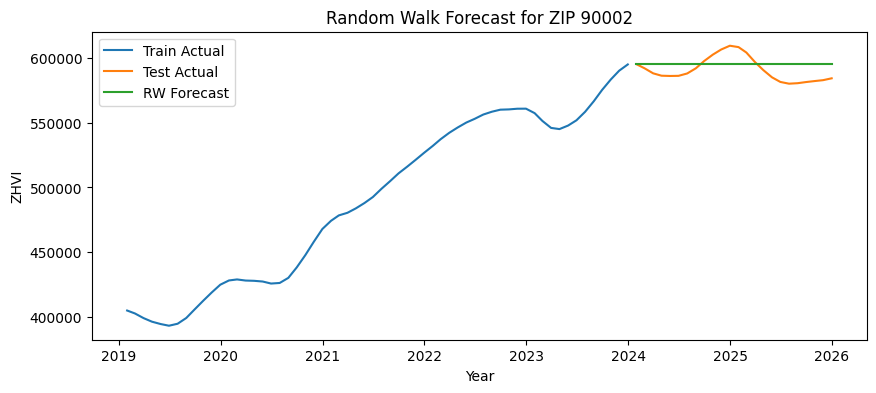

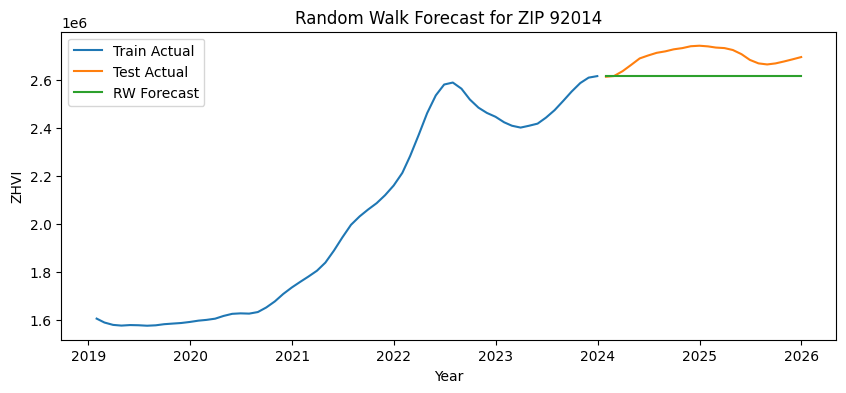

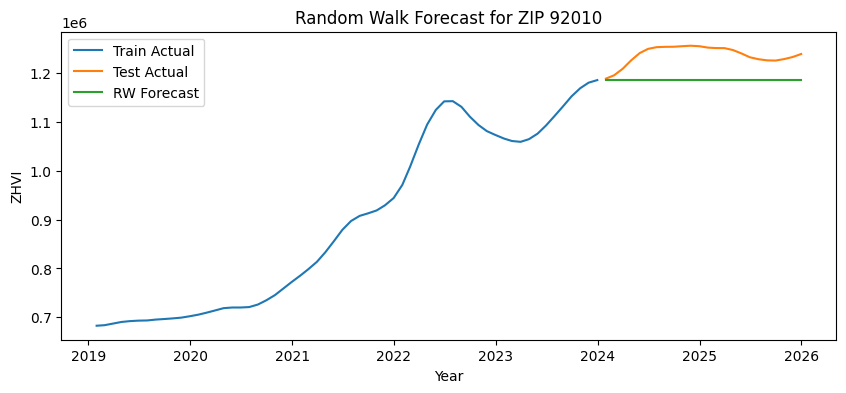

In [150]:
# 34. fit Baseline Models

#----------------------------------------------------------
# 
#   1. Random Walk with a Drift
#
#   2. ARIMA/ARMA 
#
#   3. Linear Mixed Models with Random Effects
#-----------------------------------------------------------
import seaborn as sns
import matplotlib.pyplot as plt


###############################################################

#34a. Model 1:  Random Walk 

################################################################

# subset final dataset
rw_2019_2025 = panel_final[["zip_code", "date", "zhvi"]].copy()
rw_2019_2025["zip_code"] = rw_2019_2025["zip_code"].astype(str)
rw_2019_2025["date"] = pd.to_datetime(rw_2019_2025["date"])
rw_2019_2025 = rw_2019_2025.sort_values(["zip_code", "date"])

# split the data
split_date = pd.Timestamp("2024-01-01")
rw_train = rw_2019_2025[rw_2019_2025["date"] < split_date].copy()
rw_test  = rw_2019_2025[rw_2019_2025["date"] >= split_date].copy()

# random walk forecasts
rw_forecasts = []

for zipcode, train_zip in rw_train.groupby("zip_code"):
    test_zip = rw_test[rw_test["zip_code"] == zipcode].copy()

    if len(test_zip) == 0:
        continue

    last_rwtrain_val = train_zip["zhvi"].iloc[-1]
    test_zip["rw_pred"] = last_rwtrain_val
    rw_forecasts.append(test_zip)

rw_res = pd.concat(rw_forecasts, ignore_index=True)
rw_res.to_csv("predicted_forecasts.csv", index=False)

# plot selected series
for zip_ts in ["90002", "92014", "92010"]:
    train_one = rw_train[rw_train["zip_code"] == zip_ts].copy()
    test_pred_one = rw_res[rw_res["zip_code"] == zip_ts].copy()

    plt.figure(figsize=(10, 4))
    #training actuals
    plt.plot(train_one["date"], train_one["zhvi"], label="Train Actual")
    #testing actuals
    plt.plot(test_pred_one["date"], test_pred_one["zhvi"], label="Test Actual")
    #test predictions
    plt.plot(test_pred_one["date"], test_pred_one["rw_pred"], label="RW Forecast")

    plt.title(f"Random Walk Forecast for ZIP {zip_ts}")
    plt.xlabel("Year")
    plt.ylabel("ZHVI")
    plt.legend()
    plt.show()

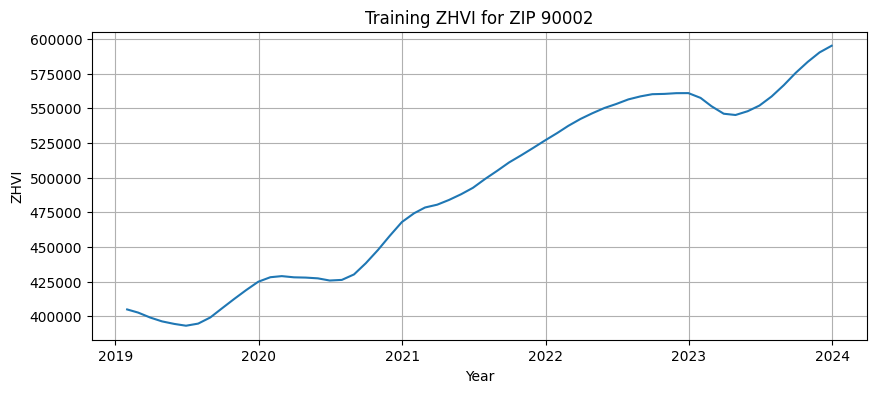

ADF Statistic for ZIP 90002: -0.9450
p-value for ZIP 90002: 0.7728


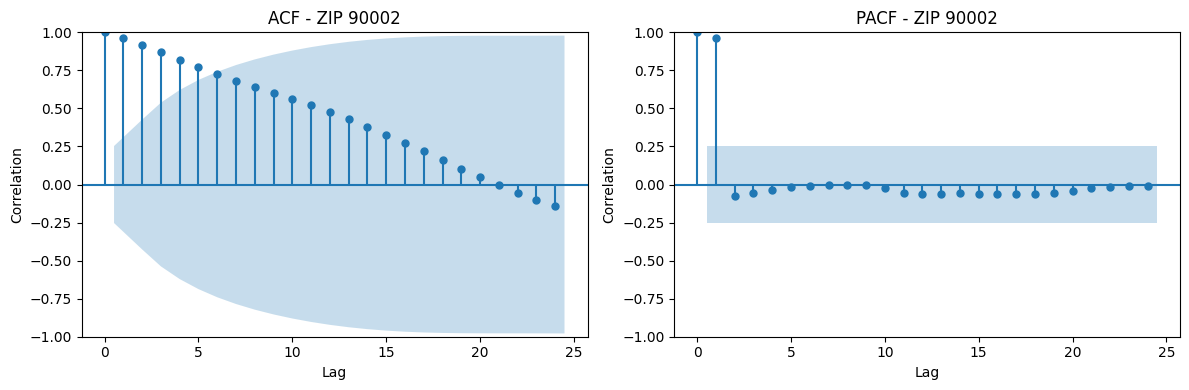

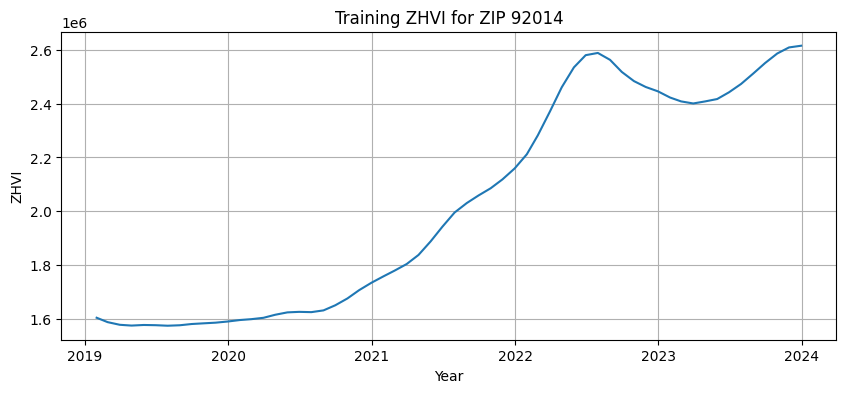

ADF Statistic for ZIP 92014: -1.0077
p-value for ZIP 92014: 0.7504


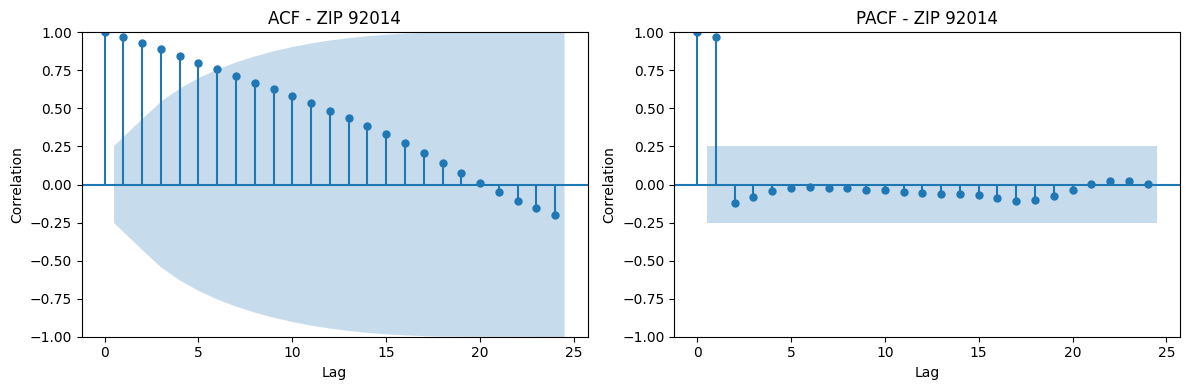

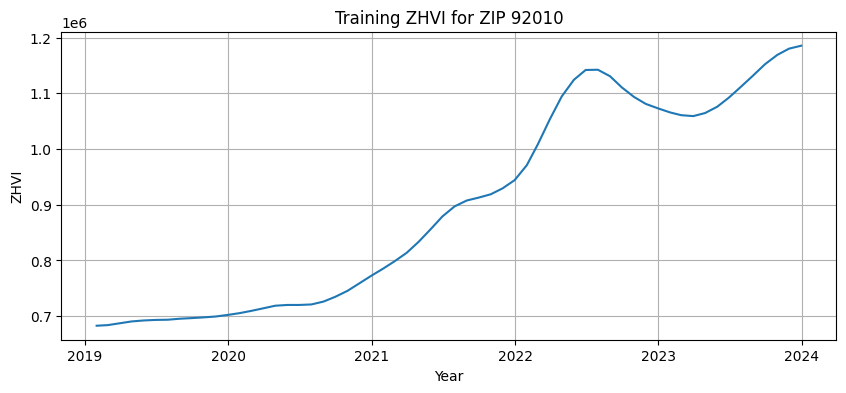

ADF Statistic for ZIP 92010: -0.8349
p-value for ZIP 92010: 0.8086


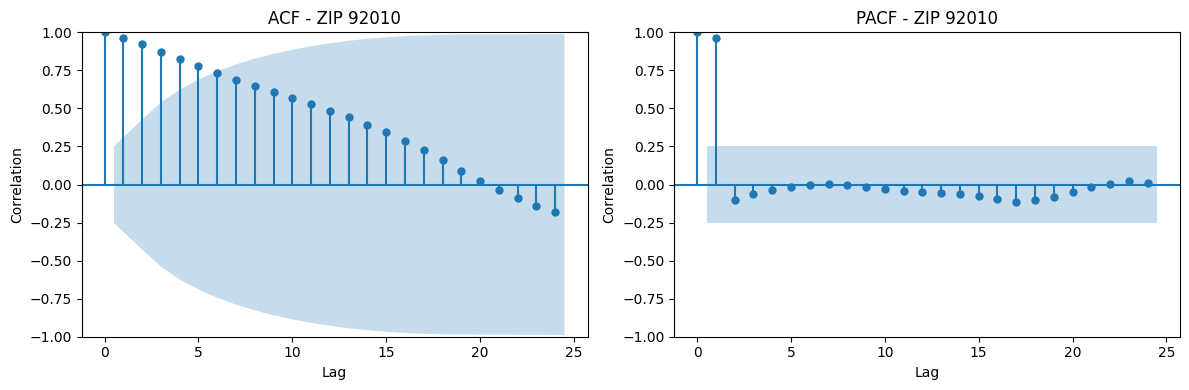

In [151]:
###############################################################

#34b. Model 2:  ARIMA/ARMA 

################################################################

#34b_1. plot the series to see if it is covariance stationary 

#--------------------------------------------------------------------
# Plot to see if it is covariance stationary.
# - ideally there should be no upward trend if covariance stationary
# - if upward trend we violated: 
#        1. constant mean 
#        2. constant variance
#   
#    we can fix this by either log transforming, differencing, or both if needed
#
#--------------------------------------------------------------------

#34c_1. diagnostics:

#-------------------------------------------------------------------------------------------------------------------------------------------
# - ACF      ( ACF and PACF give us parameters and form of the ARIMA)
# - PACF 

# ADF p-value: > 0.05 not stationary so d = 1 (needs differencing)
#
# Based on the ACF and PACF plots:
#       - we have AR(1) characteristics since the ACF has a slow exponential decay and the PACF cuts off after lag 1
#       - No MA(q) characteristics
#       - planning to fit ARIMA (1,1,0)
#---------------------------------------------------------------------------------------------------------------------------------------------
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima

# split data
split_date = pd.Timestamp("2024-01-01")

arima_train = rw_2019_2025[rw_2019_2025["date"] < split_date].copy()
arima_test  = rw_2019_2025[rw_2019_2025["date"] >= split_date].copy()

# start with one zipcode first
zip_codes  = ["90002","92014","92010"]

for zip_code in zip_codes:
    # subset 
    train_arima = arima_train[arima_train["zip_code"] == zip_code].copy()
    test_arima  = arima_test[arima_test["zip_code"] == zip_code].copy()

    # sort by date
    train_arima = train_arima.sort_values("date")
    test_arima = test_arima.sort_values("date")

    # define series
    y_train_arima = train_arima["zhvi"]
    y_test_arima = test_arima["zhvi"]

    # skip if too few observations
    if len(y_train_arima.dropna()) < 10:
        print(f"Skipping ZIP {zip_code}: not enough observations")
        continue

    #print(f"\n===== ZIP {zip_code} =====")
    #print(train_arima.head())
    #print(train_arima.tail())

    # --------------------------
    # 1. plot time series
    # --------------------------
    plt.figure(figsize=(10, 4))
    plt.plot(train_arima["date"], y_train_arima)
    plt.title(f"Training ZHVI for ZIP {zip_code}")
    plt.xlabel("Year")
    plt.ylabel("ZHVI")
    plt.grid(True)
    plt.show()

    # --------------------------
    # 2. ADF test
    # --------------------------
    adf_result = adfuller(y_train_arima.dropna())
    print(f"ADF Statistic for ZIP {zip_code}: {adf_result[0]:.4f}")
    print(f"p-value for ZIP {zip_code}: {adf_result[1]:.4f}")

    # --------------------------
    # 3. ACF and PACF
    # --------------------------
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    plot_acf(y_train_arima.dropna(), lags=24, ax=axes[0])
    axes[0].set_title(f"ACF - ZIP {zip_code}")
    axes[0].set_xlabel("Lag")
    axes[0].set_ylabel("Correlation")

    plot_pacf(y_train_arima.dropna(), lags=24, ax=axes[1], method="ywm")
    axes[1].set_title(f"PACF - ZIP {zip_code}")
    axes[1].set_xlabel("Lag")
    axes[1].set_ylabel("Correlation")

    plt.tight_layout()
    plt.show()

C:\Users\bphul\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\bphul\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\bphul\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\bphul\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\bphul\AppData\Local\Programs\Python\Python313\L

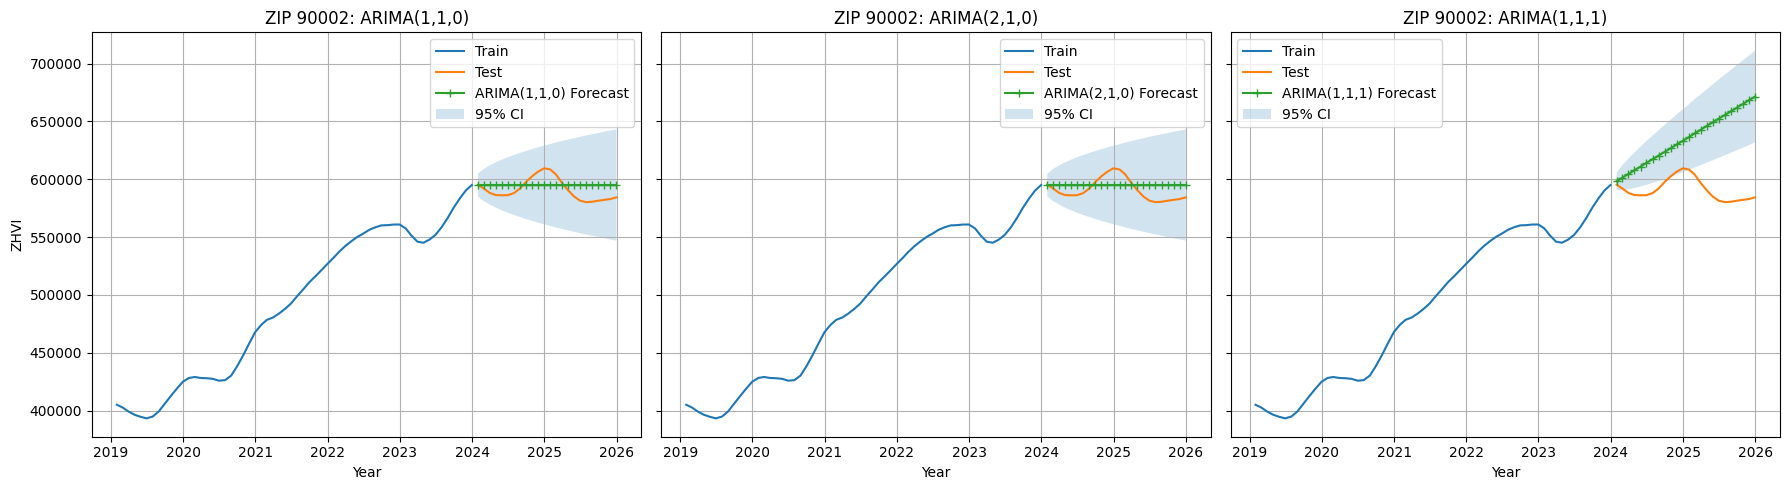

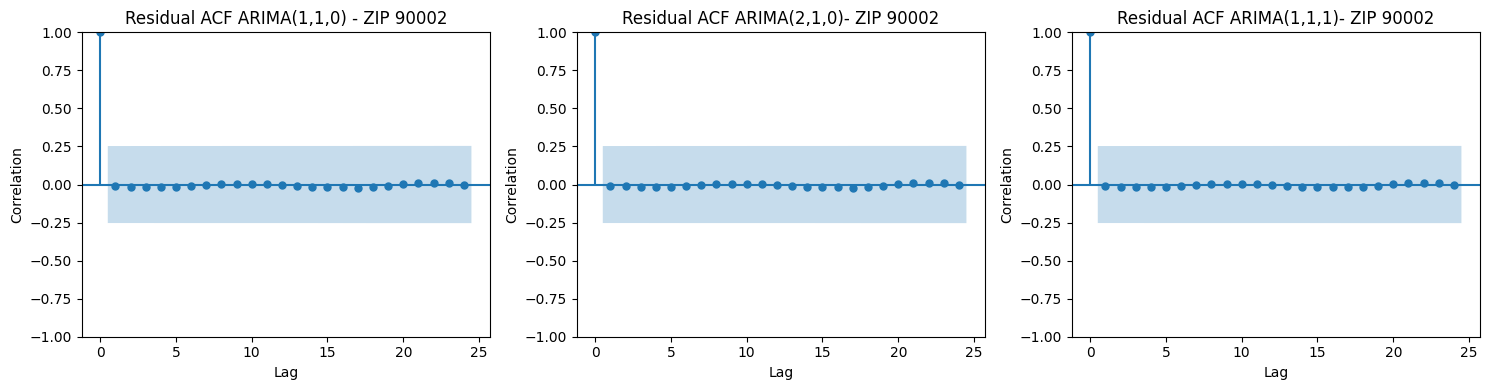

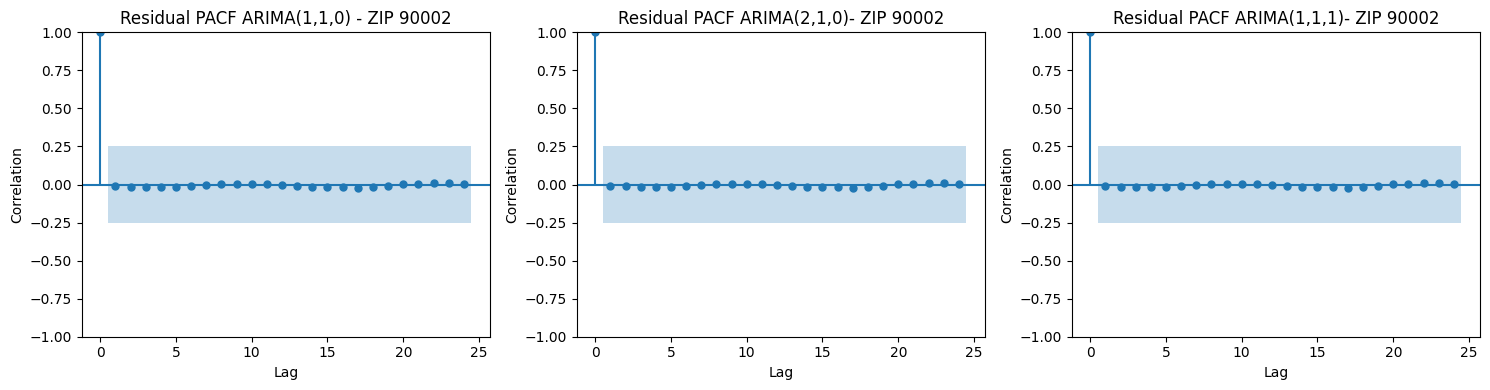

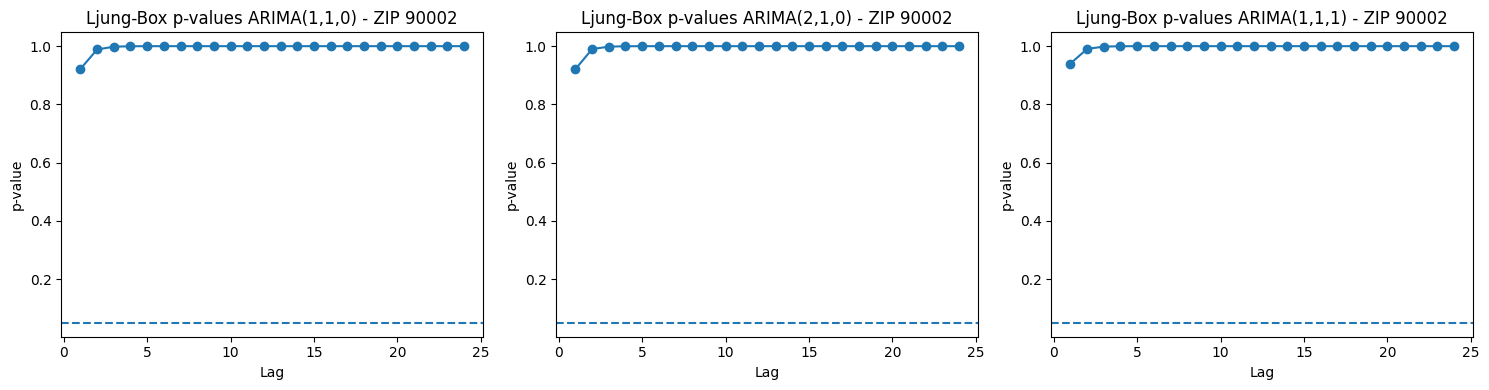

C:\Users\bphul\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\bphul\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\bphul\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\bphul\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\bphul\AppData\Local\Programs\Python\Python313\L

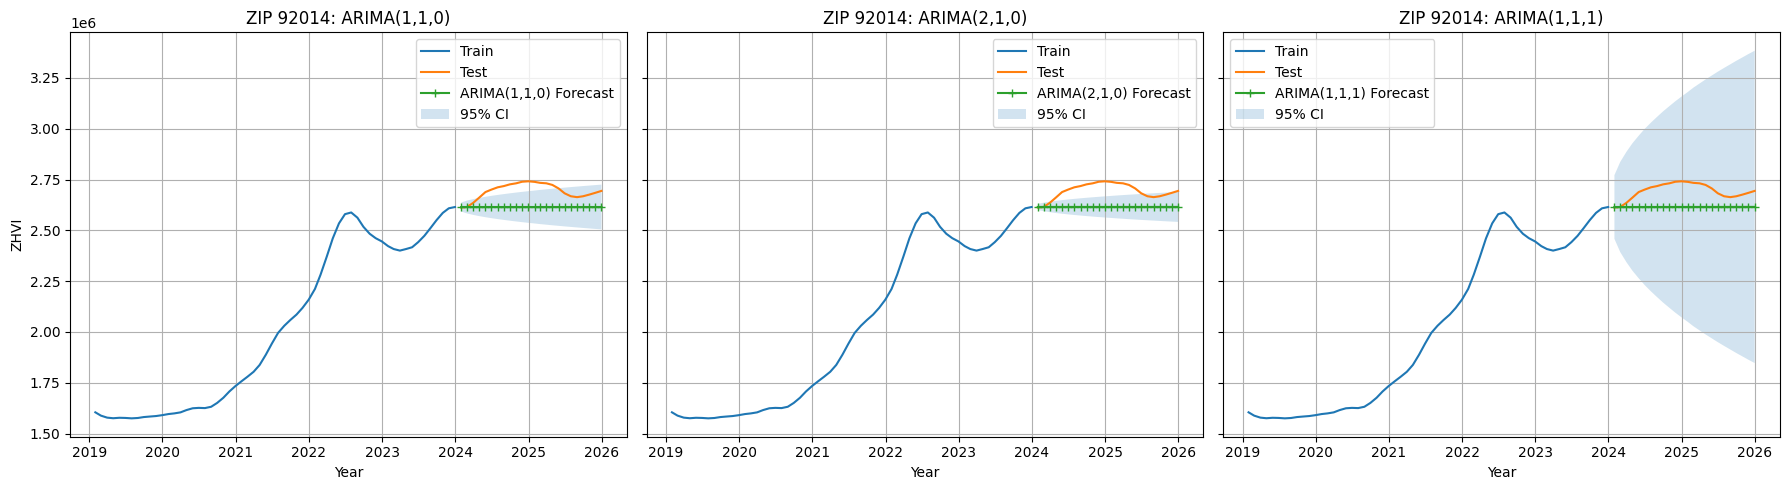

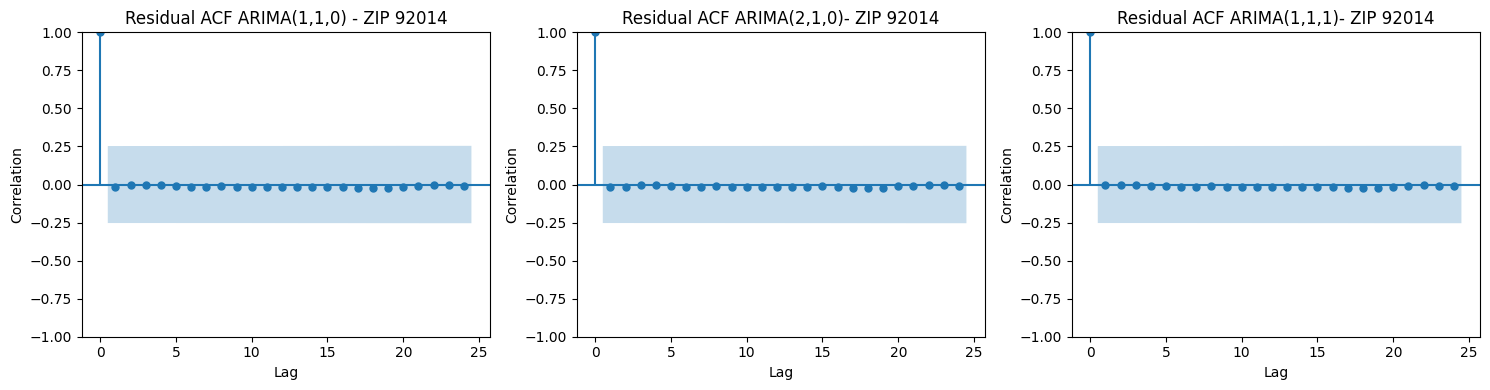

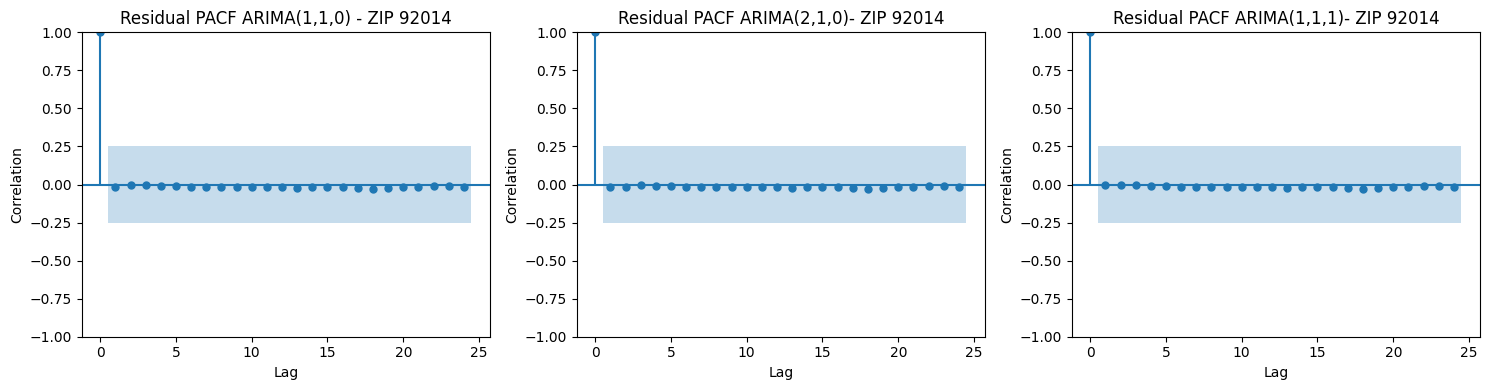

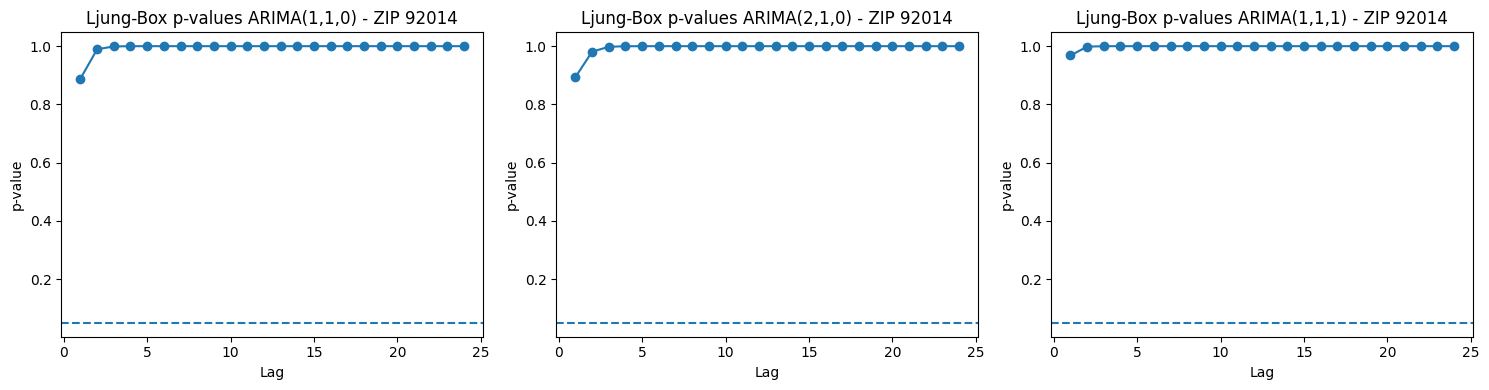

C:\Users\bphul\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\bphul\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\bphul\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\bphul\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\bphul\AppData\Local\Programs\Python\Python313\L

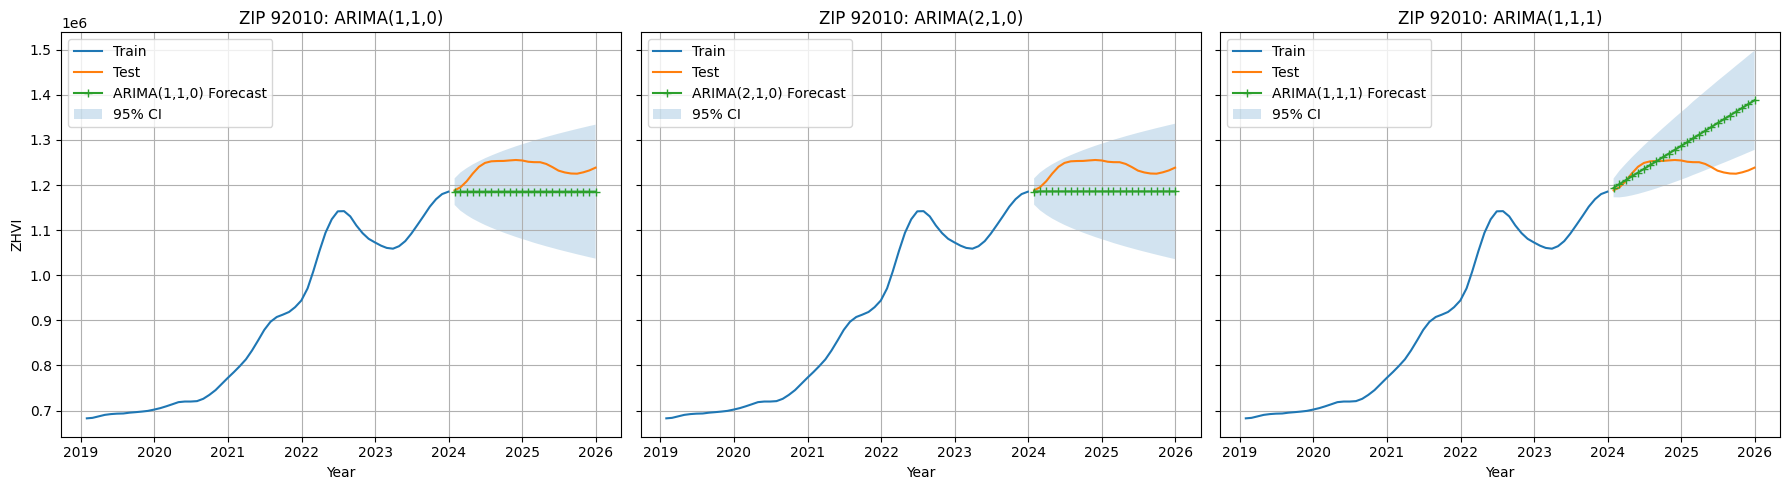

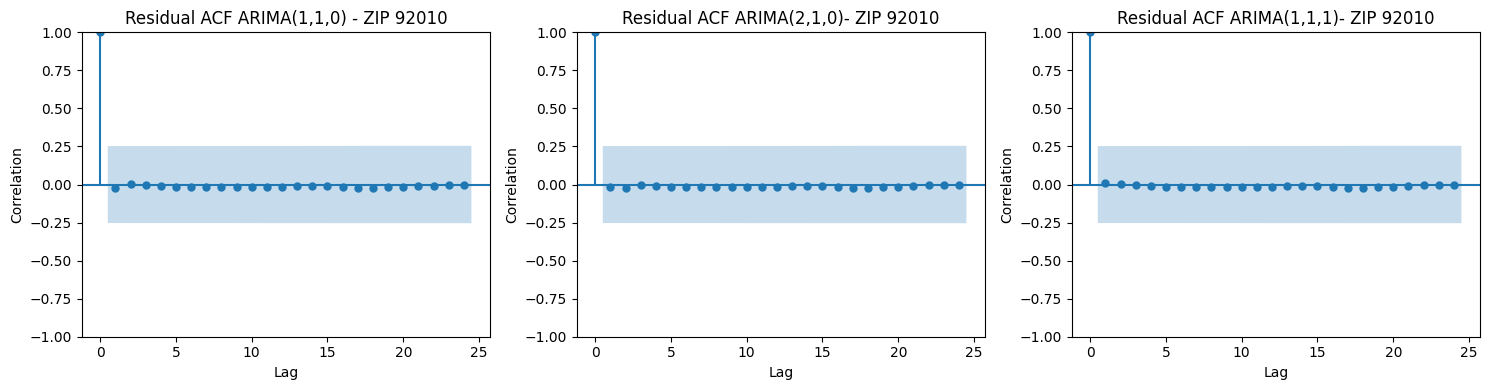

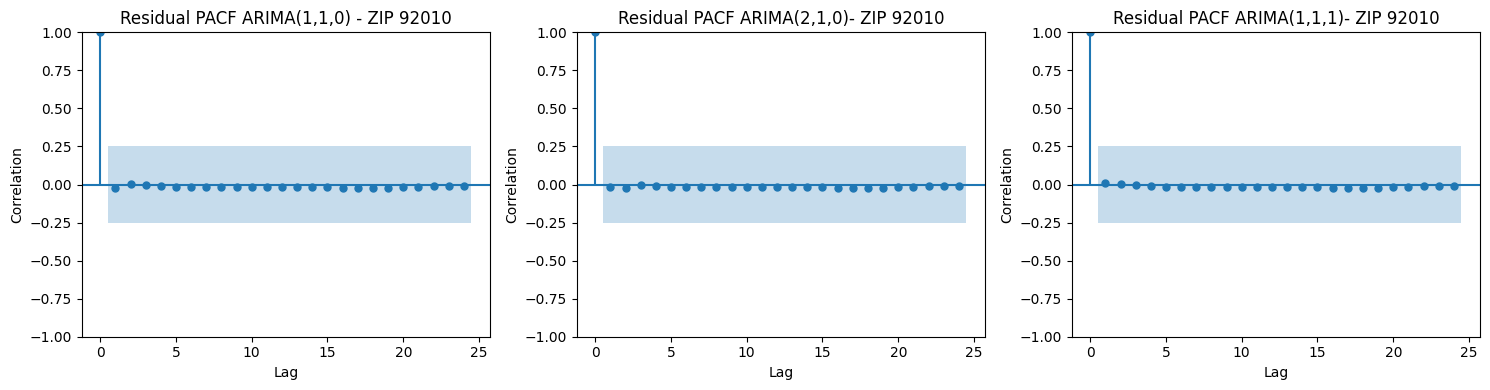

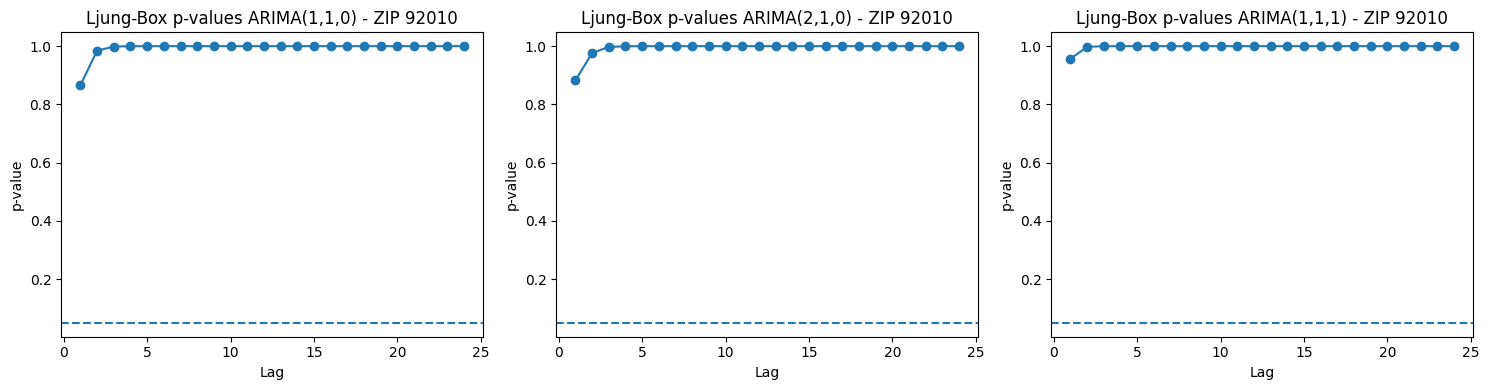

             Model 1       Model 2       Model 3
ar.L1   2.866171e-02  2.658670e-02  9.999997e-01
sigma2  2.264099e+08  2.209484e+08  1.118765e+08
ar.L2            NaN  2.600430e-02           NaN
ma.L1            NaN           NaN -9.999127e-01


In [152]:
#34d_1. fit the ARIMA (1,1,0)

#---------------------------------------------------------------------------
# Based on the ACF and PACF of the zipcodes the time series need differencing
# hence we need d = 1, no MA portion is present but AR(1) is -> ARIMA(1,1,0)
#
# Diagnostics: 
#       - ACF      
#       - PACF 
#       - Ljung Boxes for autocorrelation 
#----------------------------------------------------------------------------

# split data
split_date = pd.Timestamp("2024-01-01")
arima_train = rw_2019_2025[rw_2019_2025["date"] < split_date].copy()
arima_test  = rw_2019_2025[rw_2019_2025["date"] >= split_date].copy()

# get all zipcodes
zip_codes = arima_train["zip_code"].dropna().unique()

results_summary = []
forecast_dict = {}

zip_codes  = ["90002","92014","92010"]

for zip_code in zip_codes:
    # subset one zipcode
    train_arima = arima_train[arima_train["zip_code"] == zip_code].copy()
    test_arima  = arima_test[arima_test["zip_code"] == zip_code].copy()

    # sort by date
    train_arima = train_arima.sort_values("date")
    test_arima  = test_arima.sort_values("date")

    # set date index (helpful for forecasting)
    train_arima = train_arima.set_index("date")
    test_arima = test_arima.set_index("date")

    # define series
    y_train_arima = train_arima["zhvi"].dropna()
    y_test_arima  = test_arima["zhvi"].dropna()

    try:
        # fit ARIMA(1,1,0), ARIMA(2,1,0), and ARIMA(1,1,1)
        model = ARIMA(y_train_arima, order=(1, 1, 0))
        model2 = ARIMA(y_train_arima, order=(2, 1, 0))
        model3 = ARIMA(y_train_arima, order=(1, 1, 1))
        
        fitted_model = model.fit()
        fitted_model2 = model2.fit()
        fitted_model3 = model3.fit()

        # forecast for length of test set
        n_future = len(test_arima)  #2024 - 2025

        #forecast for ARIMA(1,1,0)
        forecast_obj = fitted_model.get_forecast(steps=n_future)
        future_forecast = forecast_obj.predicted_mean
        future_ci = forecast_obj.conf_int()

        #forecast for ARIMA(2,1,0)
        forecast_obj2 = fitted_model2.get_forecast(steps=n_future)
        future_forecast2 = forecast_obj2.predicted_mean
        future_ci2 = forecast_obj2.conf_int()

        #forecast for ARIMA(1,1,1)
        forecast_obj3 = fitted_model3.get_forecast(steps=n_future)
        future_forecast3 = forecast_obj3.predicted_mean
        future_ci3 = forecast_obj3.conf_int()

        # residuals from fitted model

        # Residuals for ARIMA(1,1,0),ARIMA(2,1,0),ARIMA(1,1,1)
        residuals = fitted_model.resid.dropna()
        residuals2 = fitted_model2.resid.dropna()
        residuals3 = fitted_model3.resid.dropna()
        
         # plot forecast vs actual
        # plot all 3 models side by side
        fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

        # ---------------- ARIMA(1,1,0) ----------------
        axes[0].plot(y_train_arima.index, y_train_arima, label="Train")
        axes[0].plot(y_test_arima.index, y_test_arima, label="Test")
        axes[0].plot(future_forecast.index, future_forecast, label="ARIMA(1,1,0) Forecast", marker="+")
        axes[0].fill_between(future_ci.index,future_ci.iloc[:, 0],future_ci.iloc[:, 1],alpha=0.2,label="95% CI")
        axes[0].set_title(f"ZIP {zip_code}: ARIMA(1,1,0)")
        axes[0].set_xlabel("Year")
        axes[0].set_ylabel("ZHVI")
        axes[0].grid(True)
        axes[0].legend()

        # ---------------- ARIMA(2,1,0) ----------------
        axes[1].plot(y_train_arima.index, y_train_arima, label="Train")
        axes[1].plot(y_test_arima.index, y_test_arima, label="Test")
        axes[1].plot(future_forecast2.index, future_forecast2, label="ARIMA(2,1,0) Forecast", marker="+")
        axes[1].fill_between(future_ci2.index,future_ci2.iloc[:, 0],future_ci2.iloc[:, 1],alpha=0.2,label="95% CI")
        axes[1].set_title(f"ZIP {zip_code}: ARIMA(2,1,0)")
        axes[1].set_xlabel("Year")
        axes[1].grid(True)
        axes[1].legend()

        # ---------------- ARIMA(1,1,1) ----------------
        axes[2].plot(y_train_arima.index, y_train_arima, label="Train")
        axes[2].plot(y_test_arima.index, y_test_arima, label="Test")
        axes[2].plot(future_forecast3.index, future_forecast3, label="ARIMA(1,1,1) Forecast", marker="+")
        axes[2].fill_between(future_ci3.index,future_ci3.iloc[:, 0],future_ci3.iloc[:, 1],alpha=0.2,label="95% CI")
        axes[2].set_title(f"ZIP {zip_code}: ARIMA(1,1,1)")
        axes[2].set_xlabel("Year")
        axes[2].grid(True)
        axes[2].legend()

        plt.tight_layout()
        plt.show()

        #------------ ACF and PACF of residuals--------------------
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))

        plot_acf(residuals, lags=24, ax=axes[0])
        axes[0].set_title(f"Residual ACF ARIMA(1,1,0) - ZIP {zip_code}")
        axes[0].set_xlabel("Lag")
        axes[0].set_ylabel("Correlation")

        plot_acf(residuals2, lags=24, ax=axes[1])
        axes[1].set_title(f"Residual ACF ARIMA(2,1,0)- ZIP {zip_code}")
        axes[1].set_xlabel("Lag")
        axes[1].set_ylabel("Correlation")

        plot_acf(residuals3, lags=24, ax=axes[2])
        axes[2].set_title(f"Residual ACF ARIMA(1,1,1)- ZIP {zip_code}")
        axes[2].set_xlabel("Lag")
        axes[2].set_ylabel("Correlation")

        plt.tight_layout()
        plt.show()
        
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))

        plot_pacf(residuals, lags=24, ax=axes[0], method="ywm")
        axes[0].set_title(f"Residual PACF ARIMA(1,1,0) - ZIP {zip_code}")
        axes[0].set_xlabel("Lag")
        axes[0].set_ylabel("Correlation")

        plot_pacf(residuals2, lags=24, ax=axes[1], method="ywm")
        axes[1].set_title(f"Residual PACF ARIMA(2,1,0)- ZIP {zip_code}")
        axes[1].set_xlabel("Lag")
        axes[1].set_ylabel("Correlation")

        plot_pacf(residuals3, lags=24, ax=axes[2], method="ywm")
        axes[2].set_title(f"Residual PACF ARIMA(1,1,1)- ZIP {zip_code}")
        axes[2].set_xlabel("Lag")
        axes[2].set_ylabel("Correlation")

        plt.tight_layout()
        plt.show()

        #----------- Ljung-Box test---------------------------------

        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        
        lb_results = acorr_ljungbox(residuals.dropna(),lags=range(1, 25),return_df=True)
        lb_results2 = acorr_ljungbox(residuals2.dropna(),lags=range(1, 25),return_df=True)
        lb_results3 = acorr_ljungbox(residuals3.dropna(),lags=range(1, 25),return_df=True)
    
        axes[0].plot(lb_results.index, lb_results["lb_pvalue"], marker="o")
        axes[0].axhline(y=0.05, linestyle="--")
        axes[0].set_title(f"Ljung-Box p-values ARIMA(1,1,0) - ZIP {zip_code}")
        axes[0].set_xlabel("Lag")
        axes[0].set_ylabel("p-value")

        axes[1].plot(lb_results2.index, lb_results2["lb_pvalue"], marker="o")
        axes[1].axhline(y=0.05, linestyle="--")
        axes[1].set_title(f"Ljung-Box p-values ARIMA(2,1,0) - ZIP {zip_code}")
        axes[1].set_xlabel("Lag")
        axes[1].set_ylabel("p-value")

        axes[2].plot(lb_results3.index, lb_results3["lb_pvalue"], marker="o")
        axes[2].axhline(y=0.05, linestyle="--")
        axes[2].set_title(f"Ljung-Box p-values ARIMA(1,1,1) - ZIP {zip_code}")
        axes[2].set_xlabel("Lag")
        axes[2].set_ylabel("p-value")

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Could not fit ZIP {zip_code}: {e}")



params_df = pd.concat(
    [
        fitted_model.params.rename("Model 1"),
        fitted_model2.params.rename("Model 2"),
        fitted_model3.params.rename("Model 3")
    ],
    axis=1
)

print(params_df) # AR coefficient ~ 0 pretty much a random walk since past changes don't help predict future changes by

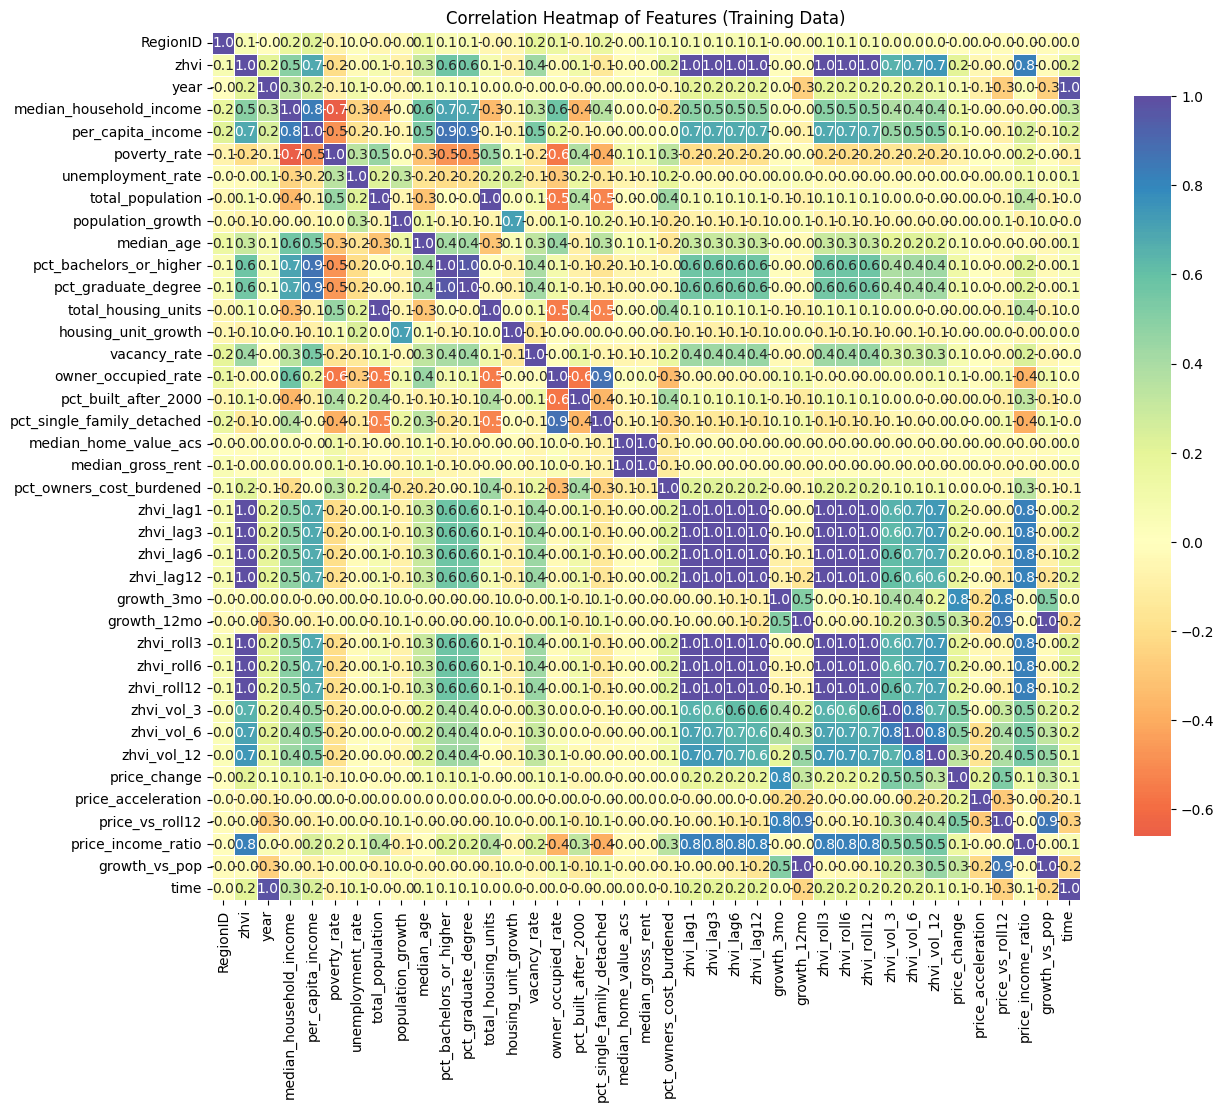

zhvi_roll3                    0.999759
zhvi_lag1                     0.999745
zhvi_roll6                    0.998848
zhvi_lag3                     0.997994
zhvi_roll12                   0.996633
zhvi_lag6                     0.994326
zhvi_lag12                    0.987344
price_income_ratio            0.821082
zhvi_vol_12                   0.741075
zhvi_vol_6                    0.707629
per_capita_income             0.676806
zhvi_vol_3                    0.652555
pct_bachelors_or_higher       0.568083
pct_graduate_degree           0.557975
median_household_income       0.490586
vacancy_rate                  0.429578
median_age                    0.298515
pct_owners_cost_burdened      0.211995
time                          0.206697
year                          0.203821
price_change                  0.203600
poverty_rate                 -0.202856
pct_single_family_detached   -0.144719
pct_built_after_2000          0.104656
housing_unit_growth          -0.079304
total_housing_units      

In [153]:
#####################################################################


#34c. Model 3: Linear Mixed Model 


#####################################################################

from datetime import datetime
import seaborn as sns

lmm_df = panel_final.copy()
lmm_df.head()

#34c_1. setup training and testing sets

#convert zipcodes as categories
lmm_df["zip_code"] = lmm_df["zip_code"].astype(str)

#sort and create time index
lmm_df = lmm_df.sort_values(["zip_code", "date"])
lmm_df["date"] = pd.to_datetime(lmm_df["date"])
lmm_df["time"] = lmm_df.groupby("zip_code").cumcount()
lmm_df.head()

#--------------------------------split into training and testing--------------------------------------- 
split_date = pd.Timestamp("2024-01-01")

lmm_train = lmm_df[lmm_df["date"] < split_date].copy()
lmm_test = lmm_df[lmm_df["date"] >= split_date].copy()

#outcome
y_lmm_train = lmm_train["zhvi"]
y_lmm_test  = lmm_test["zhvi"]

#create correlation heatmap to help identify correlated features to exclude

numeric_df = lmm_train.select_dtypes(include=["number"]).copy()

corr_matrix = numeric_df.corr()

plt.figure(figsize=(14,12))
sns.heatmap(
    corr_matrix,
    cmap="Spectral",
    annot = True,
    fmt=".1f",
    center=0,
    linewidths=0.5,
    square = True,
    cbar_kws = {"shrink": 0.8}
)

plt.title("Correlation Heatmap of Features (Training Data)")
plt.show()

# see correlations with zhvi 
corr = numeric_df.corr()["zhvi"].drop("zhvi")
corr.sort_values(key=abs, ascending=False)

In [154]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

#34b_1. Set up LMM Model 

# select initial features for model

features = [
    "time",                     #market direction over time
    "zhvi_lag1",                #momentum - captures how persistence market is
    "price_income_ratio",       #affordability - captures demand constraints
    "vacancy_rate",             #market structure - captures supply
    "pct_bachelors_or_higher"   #demographics - captures long-term demand/quality
    
]


#double check VIF

# keep only training rows and selected columns
vif_df = lmm_train[features].dropna().copy()

# add intercept
X = sm.add_constant(vif_df)

# calculate VIF
vif_results = pd.DataFrame({
    "feature": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})

# print(vif_results)

#                      feature        VIF                                           feature        VIF
# 0                      const  20.841442                   # 0                      const  96.788434
# 1                       time   1.163735                   # 1                       time   1.244692
# 2                  zhvi_lag1   7.172826                   # 2                  zhvi_lag1  23.313351
# 3         price_income_ratio   4.646926                   # 3         price_income_ratio  17.404707
# 4             vacancy_rate_%   1.330526                   # 4  median_household_income_$   8.834531
# 5  pct_bachelors_or_higher_%   2.104812                   # 5  pct_bachelors_or_higher_%   2.522325
                                                            # 6             vacancy_rate_%   1.345565

#-------------------- Model Setup ------------------------------------------------------------------------

#model variables 
model_vars = [
    "zip_code",
    "zhvi",
    "time",
    "zhvi_lag1",
    "price_income_ratio",
    "vacancy_rate",
    "pct_bachelors_or_higher"
]

#need to standardize the features because scales vary across the features
lmm_model_df = lmm_train[model_vars].dropna().copy()

# lmm_model_df["vacancy_rate"] = lmm_model_df["vacancy_rate"] / 100
# lmm_model_df["pct_bachelors_or_higher"] = lmm_model_df["pct_bachelors_or_higher"] / 100

scale_cols = [
    "zhvi_lag1",
    "price_income_ratio",
    "vacancy_rate",
    "pct_bachelors_or_higher"
]

scaler = StandardScaler()
lmm_model_df[scale_cols] = scaler.fit_transform(lmm_model_df[scale_cols])


#------------------------------ Nested Models and Outputs -----------------------------------------------------

##############################################################################################
# Fitted Model 1: Initial Full Model
##############################################################################################

lmm_model = smf.mixedlm(
    "zhvi ~ time + zhvi_lag1 + price_income_ratio + vacancy_rate + pct_bachelors_or_higher",
    data=lmm_model_df,
    groups=lmm_model_df["zip_code"],
    re_formula= "~time"
)

result = lmm_model.fit(method="lbfgs")  
print("Initial Full Model: ", result.summary())

######################################################################################################
#Fitted Model 2 : Dropped Vacancy Rate because it was not significant
######################################################################################################

lmm_model2 = smf.mixedlm(
    "zhvi ~ time + zhvi_lag1 + price_income_ratio + pct_bachelors_or_higher",
    data=lmm_model_df,
    groups=lmm_model_df["zip_code"],
    re_formula= "~time"
)

result2 = lmm_model2.fit(method="lbfgs")  
print("Original Model Results: ", result2.summary())

###########################################################################################################
#   Fitted Model 3 : Log Transformed ZHVI  (Final Model used: Best one out of the 5)
############################################################################################################

lmm_model_df2 = lmm_model_df.copy()
lmm_model_df2 = lmm_train[model_vars].copy()

#log-transform both zhvi and zhvi_lag1 because they need to be on same scales and they need to be positive so select values > 0
lmm_model_df2["log_zhvi"] = np.where(
    lmm_model_df2["zhvi"] > 0,
    np.log(lmm_model_df2["zhvi"]),
    np.nan
)

lmm_model_df2["log_zhvi_lag1"] = np.where(
    lmm_model_df2["zhvi_lag1"] > 0,
    np.log(lmm_model_df2["zhvi_lag1"]),
    np.nan
)

# lmm_model_df2["vacancy_rate"] = lmm_model_df2["vacancy_rate"] / 100
# lmm_model_df2["pct_bachelors_or_higher"] = lmm_model_df2["pct_bachelors_or_higher"] / 100

scale_cols = [
    "price_income_ratio",
    "vacancy_rate",
    "pct_bachelors_or_higher"
]

scaler = StandardScaler()
lmm_model_df2[scale_cols] = scaler.fit_transform(lmm_model_df2[scale_cols])

# drop any na values after log transformation
lmm_model_df2 = lmm_model_df2.replace([np.inf, -np.inf], np.nan).dropna()

#print(lmm_model_df2.shape)
#print(lmm_model_df2[[
#     "log_zhvi_$", "log_zhvi_lag1", "time",
#     "price_income_ratio", "pct_bachelors_or_higher_%"
# ]].isna().sum())

group_sizes = lmm_model_df2.groupby("zip_code").size()
lmm_model_df2 = lmm_model_df2[lmm_model_df2["zip_code"].isin(group_sizes[group_sizes >= 10].index)]

# print(group_sizes)
# print(lmm_model_df2)

#fit model 3
lmm_model3 = smf.mixedlm(
    "log_zhvi ~ time + log_zhvi_lag1 + price_income_ratio + pct_bachelors_or_higher",
    data=lmm_model_df2,
    groups=lmm_model_df2["zip_code"],
    re_formula= "~time"
)

result3 = lmm_model3.fit(method="lbfgs")  
print("Log Transformed Model Results: " ,result3.summary())

########################################################################################
#   Fitted Model 4 : added ahvi_lag2 to see if it improves ACF/PACF
#########################################################################################

#select features
lmm_model_df3 = lmm_train[[
    "zip_code",
    "date",
    "zhvi",
    "time",
    "price_income_ratio",
    "vacancy_rate",
    "pct_bachelors_or_higher"
]].copy()

lmm_model_df3 = lmm_model_df3.sort_values(["zip_code", "date"])

#add lags to data frame
lmm_model_df3["zhvi_lag1"] = lmm_model_df3.groupby("zip_code")["zhvi"].shift(1)
lmm_model_df3["zhvi_lag2"] = lmm_model_df3.groupby("zip_code")["zhvi"].shift(2)

#log transform zhvi_$ and zhvi_lag1 and zhvi_lag2
lmm_model_df3["log_zhvi"] = np.log(lmm_model_df3["zhvi"])
lmm_model_df3["log_zhvi_lag1"] = np.log(lmm_model_df3["zhvi_lag1"])
lmm_model_df3["log_zhvi_lag2"] = np.log(lmm_model_df3["zhvi_lag2"])

# scale so converges and values arent inflated
# lmm_model_df3["vacancy_rate"] = lmm_model_df3["vacancy_rate"] / 100
# lmm_model_df3["pct_bachelors_or_higher"] = lmm_model_df3["pct_bachelors_or_higher"] / 100

scale_cols = [
    "price_income_ratio",
    "vacancy_rate",
    "pct_bachelors_or_higher"
]

scaler = StandardScaler()
lmm_model_df3[scale_cols] = scaler.fit_transform(lmm_model_df3[scale_cols])

lmm_model_df3 = lmm_model_df3.replace([np.inf, -np.inf], np.nan).dropna()

# fit model 4
lmm_model4 = smf.mixedlm(
    "log_zhvi ~ time + log_zhvi_lag1 + log_zhvi_lag2 + price_income_ratio + pct_bachelors_or_higher",
    data=lmm_model_df3,
    groups=lmm_model_df3["zip_code"],
    re_formula="~time"
)

result4 = lmm_model4.fit(method="lbfgs")
print("Log Transformed with add zhvi_lag2 Results: ", result4.summary())

###############################################################################
# Fitted model 5 : log(price_income_ratio) for linearity issue
###############################################################################

#select features
lmm_model_df4 = lmm_train[[
    "zip_code",
    "date",
    "zhvi",
    "time",
    "price_income_ratio",
    "vacancy_rate",
    "pct_bachelors_or_higher"
]].copy()

lmm_model_df4 = lmm_model_df4.sort_values(["zip_code", "date"])

#add lags to data frame
lmm_model_df4["zhvi_lag1"] = lmm_model_df4.groupby("zip_code")["zhvi"].shift(1)


#log transform zhvi_$ and zhvi_lag1 and zhvi_lag2
lmm_model_df4["log_zhvi"] = np.log(lmm_model_df4["zhvi"])
lmm_model_df4["log_zhvi_lag1"] = np.log(lmm_model_df4["zhvi_lag1"])
lmm_model_df4["log_price_income_ratio"] = np.log(lmm_model_df4["price_income_ratio"])

# scale so converges and values arent inflated
# lmm_model_df4["vacancy_rate"] = lmm_model_df4["vacancy_rate"] / 100
# lmm_model_df4["pct_bachelors_or_higher"] = lmm_model_df4["pct_bachelors_or_higher"] / 100

scale_cols = [
    "log_price_income_ratio",
    "vacancy_rate",
    "pct_bachelors_or_higher"
]

scaler = StandardScaler()
lmm_model_df4[scale_cols] = scaler.fit_transform(lmm_model_df4[scale_cols])

lmm_model_df4 = lmm_model_df4.replace([np.inf, -np.inf], np.nan).dropna()

# fit model 5
lmm_model5 = smf.mixedlm(
    "log_zhvi ~ time + log_zhvi_lag1 + log_price_income_ratio + pct_bachelors_or_higher",
    data=lmm_model_df4,
    groups=lmm_model_df4["zip_code"],
    re_formula="~time"
)

result5 = lmm_model5.fit(method="lbfgs")
print("Log Transformed with add log(price_income_ratio) Results: ", result5.summary())

C:\Users\bphul\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\bphul\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\bphul\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 416.953404
  warnings.warn(msg, ConvergenceWarning)
C:\Users\bphul\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWa

Initial Full Model:                        Mixed Linear Model Regression Results
Model:                     MixedLM        Dependent Variable:        zhvi         
No. Observations:          21062          Method:                    REML         
No. Groups:                357            Scale:                     93063689.8320
Min. group size:           58             Log-Likelihood:            -225879.1937 
Max. group size:           59             Converged:                 No           
Mean group size:           59.0                                                   
----------------------------------------------------------------------------------
                            Coef.     Std.Err.    z    P>|z|   [0.025     0.975]  
----------------------------------------------------------------------------------
Intercept                  868181.012 1600.355 542.493 0.000 865044.374 871317.651
time                          805.619  434.824   1.853 0.064    -46.621   1657.859
zhvi_l

C:\Users\bphul\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


Log Transformed Model Results:                Mixed Linear Model Regression Results
Model:                MixedLM    Dependent Variable:    log_zhvi  
No. Observations:     21062      Method:                REML      
No. Groups:           357        Scale:                 0.0001    
Min. group size:      58         Log-Likelihood:        67760.0986
Max. group size:      59         Converged:             Yes       
Mean group size:      59.0                                        
------------------------------------------------------------------
                        Coef. Std.Err.    z    P>|z| [0.025 0.975]
------------------------------------------------------------------
Intercept               1.794    0.029  61.164 0.000  1.736  1.851
time                    0.001    0.000  46.316 0.000  0.001  0.001
log_zhvi_lag1           0.867    0.002 396.773 0.000  0.862  0.871
price_income_ratio      0.055    0.001  60.014 0.000  0.053  0.057
pct_bachelors_or_higher 0.017    0.001  15.96

C:\Users\bphul\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\bphul\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\bphul\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 1591.362690
  warnings.warn(msg, ConvergenceWarning)
C:\Users\bphul\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\bphul\A

Log Transformed with add zhvi_lag2 Results:                 Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     log_zhvi  
No. Observations:     20705       Method:                 REML      
No. Groups:           357         Scale:                  0.0000    
Min. group size:      57          Log-Likelihood:         82458.2314
Max. group size:      58          Converged:              No        
Mean group size:      58.0                                          
--------------------------------------------------------------------
                        Coef.  Std.Err.    z     P>|z| [0.025 0.975]
--------------------------------------------------------------------
Intercept                0.792    0.013   58.996 0.000  0.766  0.818
time                     0.000    0.000    7.495 0.000  0.000  0.000
log_zhvi_lag1            1.802    0.003  527.123 0.000  1.795  1.809
log_zhvi_lag2           -0.861    0.003 -284.259 0.000 -0.867 -0.855
price

C:\Users\bphul\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


Log Transformed with add log(price_income_ratio) Results:                 Mixed Linear Model Regression Results
Model:                 MixedLM    Dependent Variable:    log_zhvi  
No. Observations:      21062      Method:                REML      
No. Groups:            357        Scale:                 0.0001    
Min. group size:       58         Log-Likelihood:        68830.9895
Max. group size:       59         Converged:             Yes       
Mean group size:       59.0                                        
-------------------------------------------------------------------
                        Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------------------
Intercept                2.380    0.030  79.862 0.000  2.321  2.438
time                     0.001    0.000  47.714 0.000  0.001  0.001
log_zhvi_lag1            0.823    0.002 371.161 0.000  0.819  0.828
log_price_income_ratio   0.063    0.001  80.488 0.000  0.061  0.064
pct_

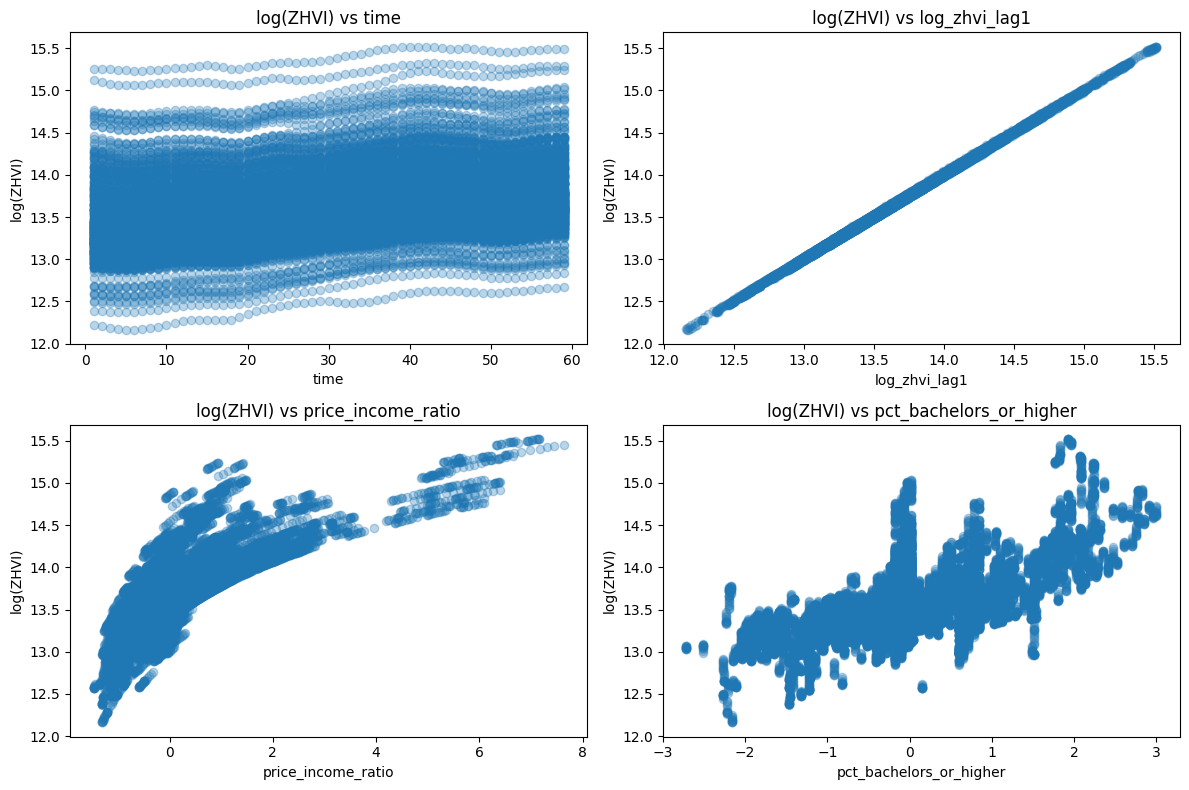

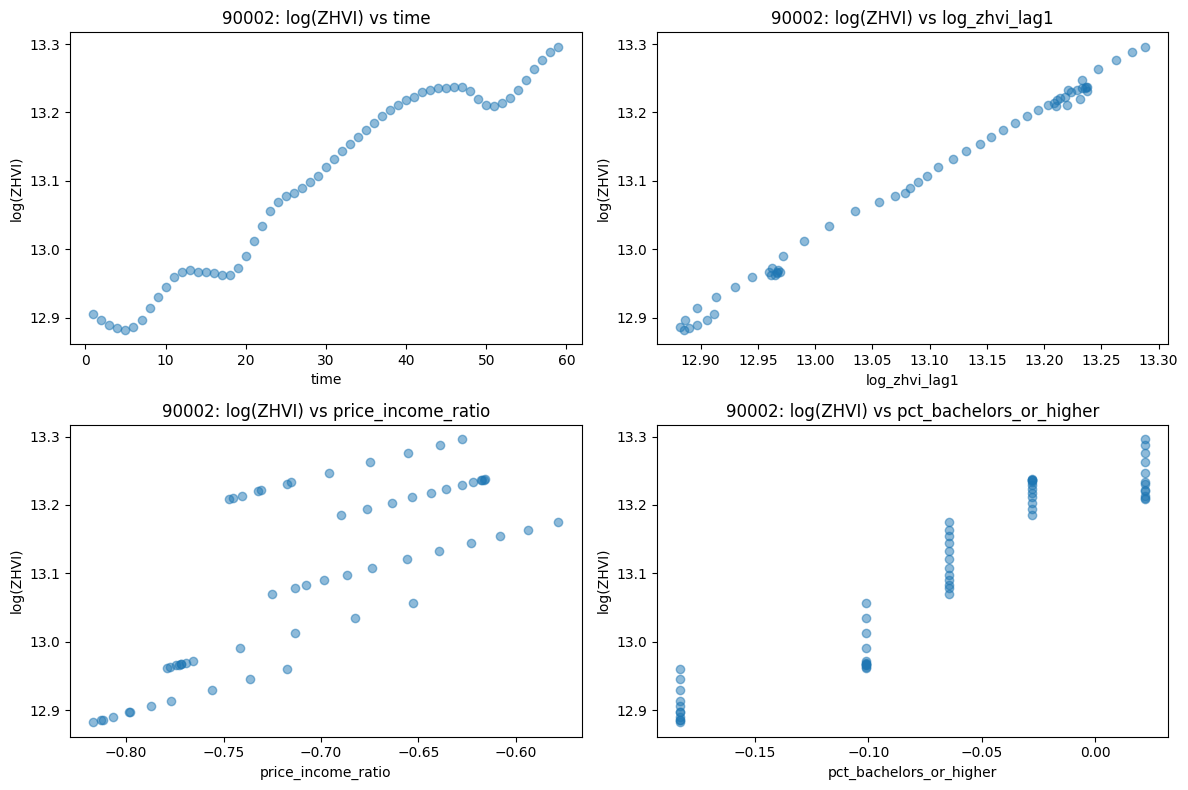

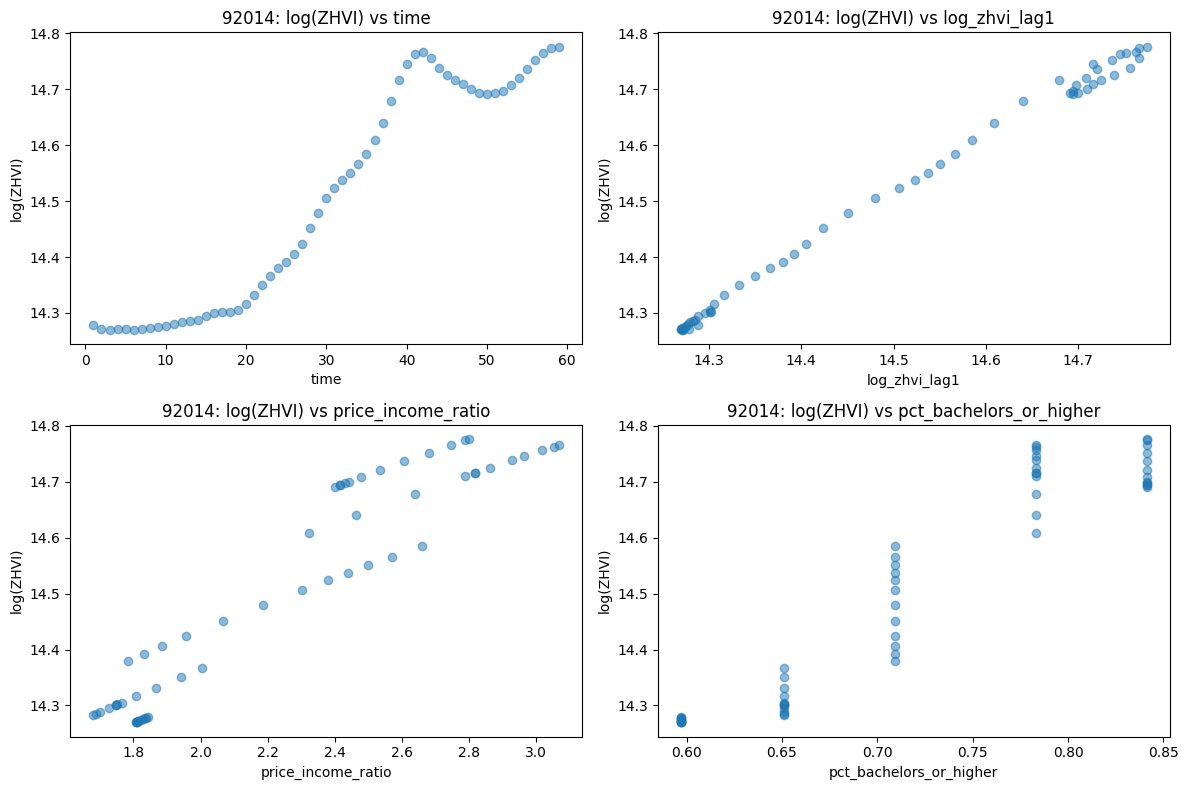

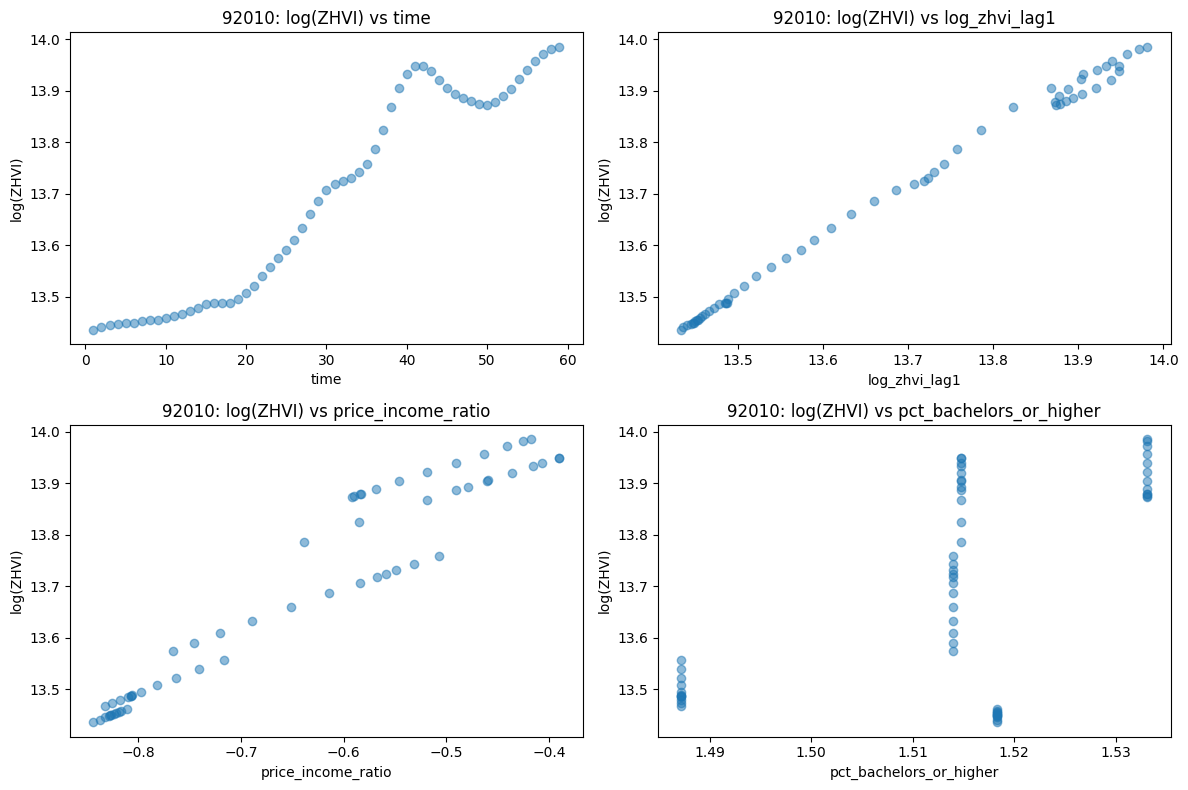

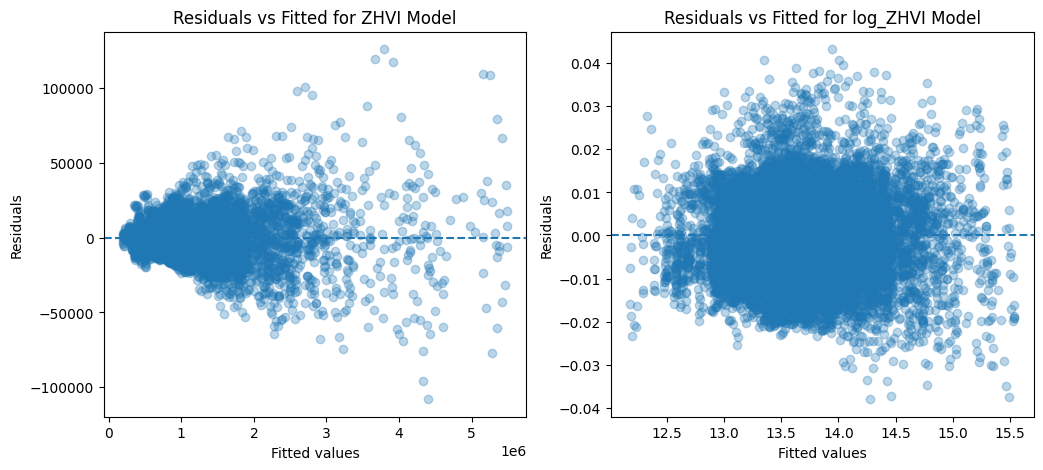

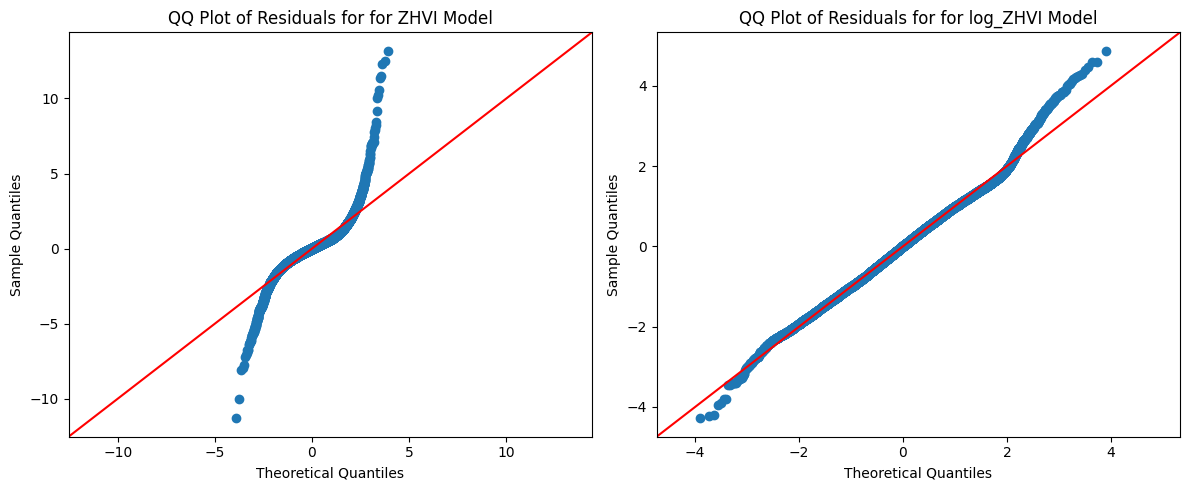

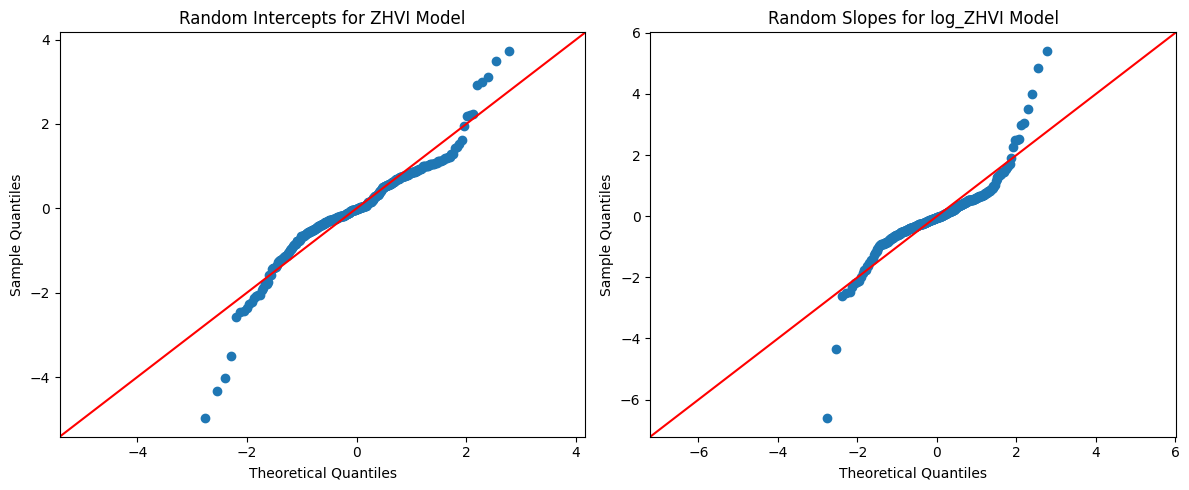

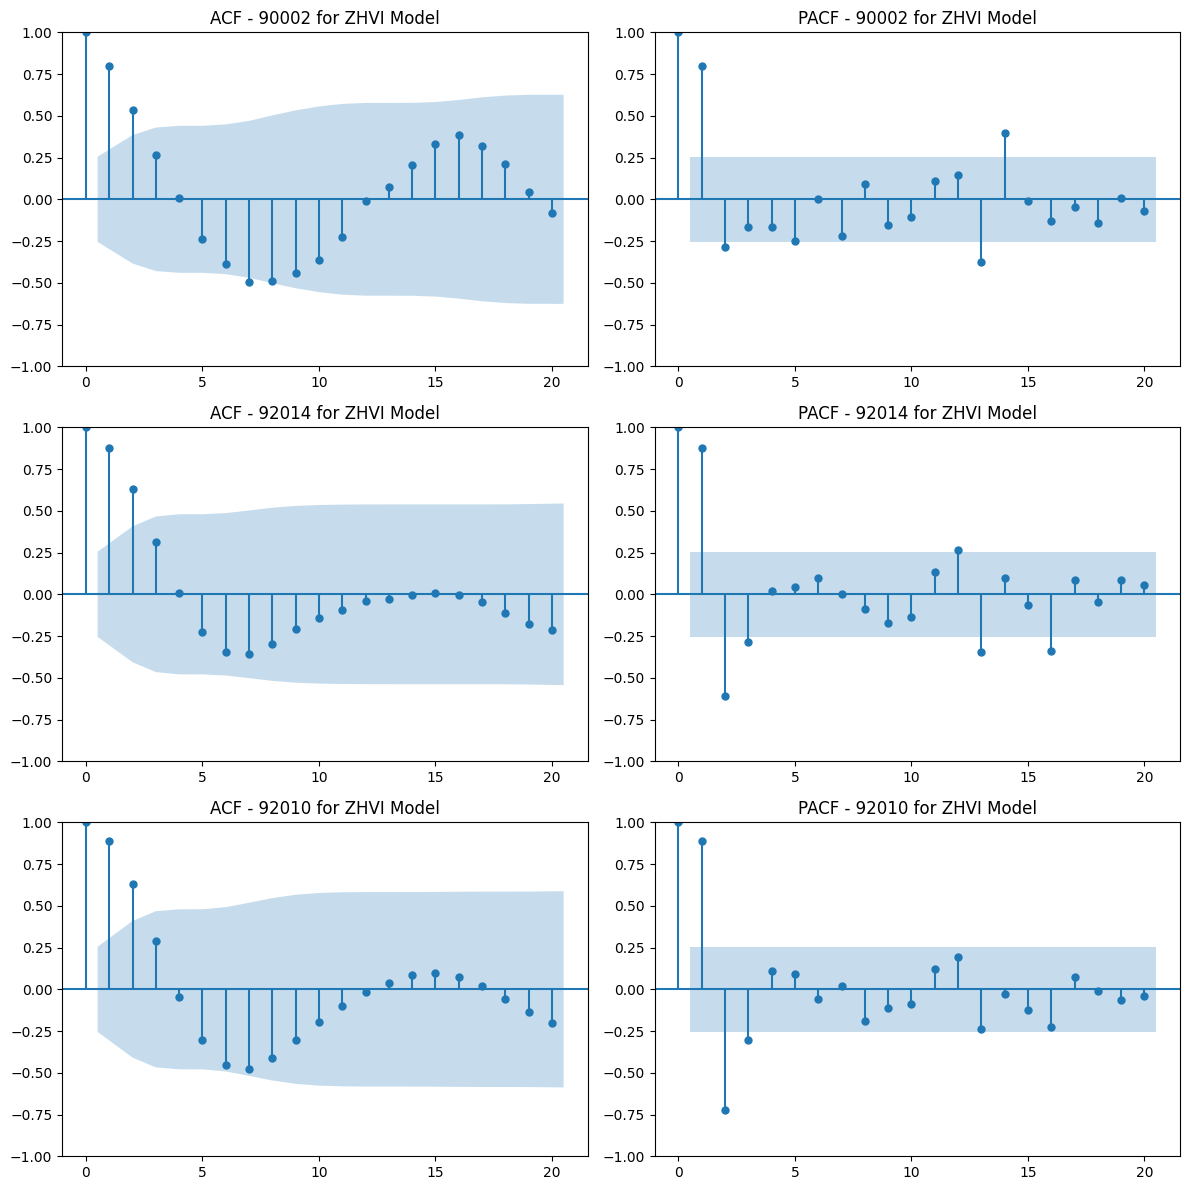

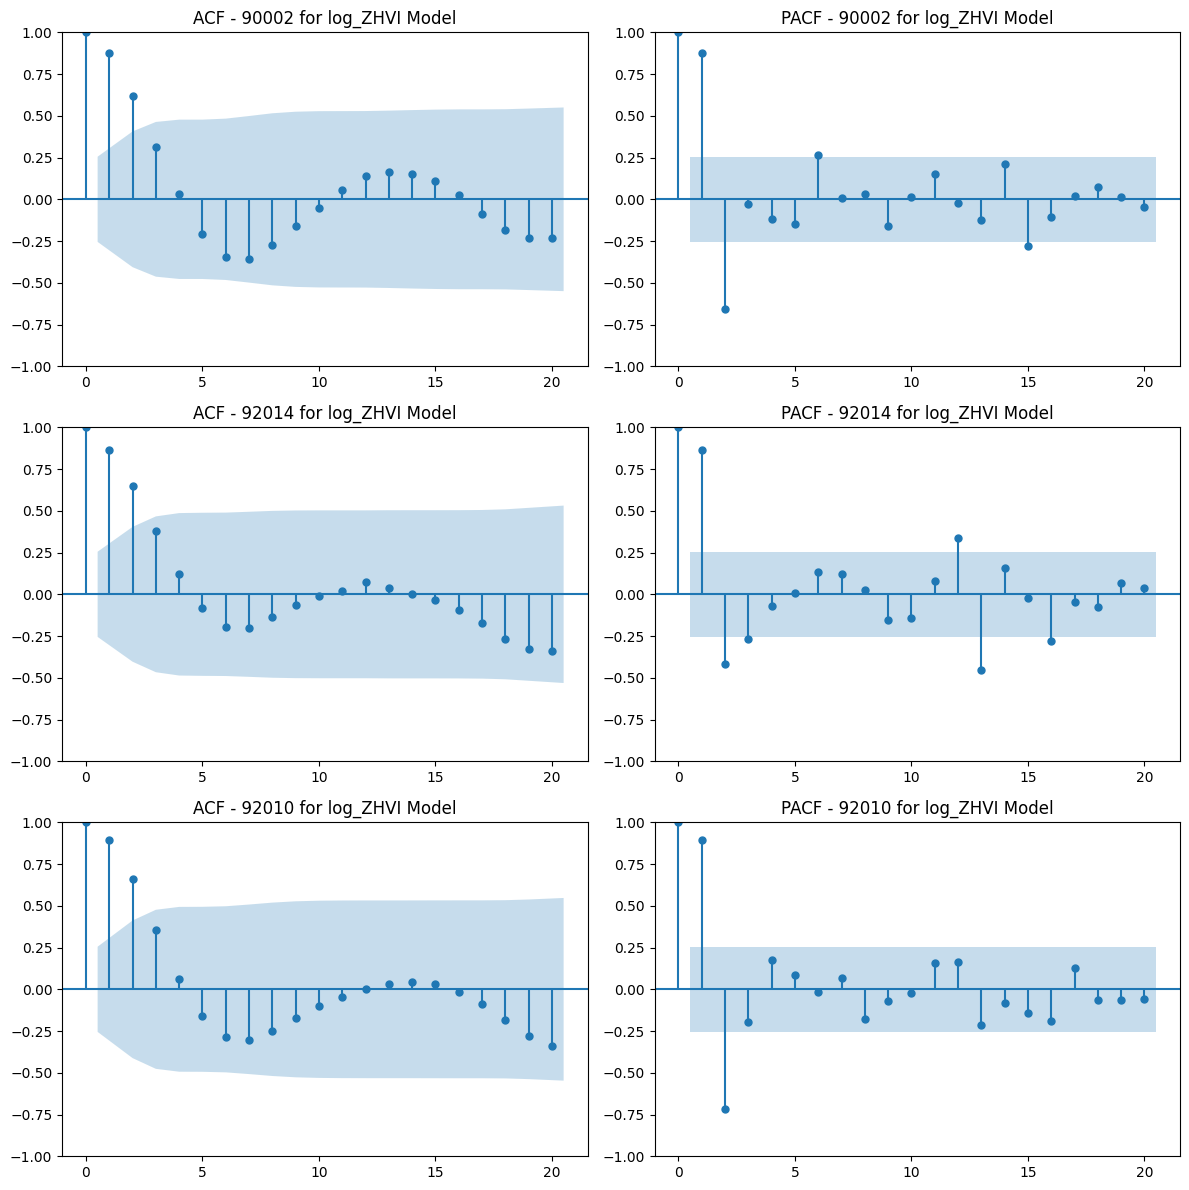

                   feature        VIF
0                    const  18.980442
1                     time   1.142116
2                zhvi_lag1   6.609508
3       price_income_ratio   4.519230
4  pct_bachelors_or_higher   2.089578
                   feature          VIF
0                    const  8321.927071
1                     time     1.436446
2            log_zhvi_lag1     8.775439
3       price_income_ratio     4.809147
4  pct_bachelors_or_higher     3.135336


In [155]:
# ---------------------------------Diagnostics---------------------------------------------------


# -----------------------------------------------
# Assumptions: 
# 1. linearity between predictor and response      - good
# 2. Normality of errors                           - okay, outliers might be pulling away from line, not severely violating
# 3. Normality of random effects                   - violated 
# 4. Homoscedasticity (constant variance)          - violated 
# 5. No multicollinearity                          - good
# 6. Independent observations                      - mostly white noise, some spikes around 10-15 that are above confidence band (not severely violating)
# -----------------------------------------------


# Residual vs Fitted: Linearity/Homoscedasticity

#scatterplots for linearity
lmm_model_df = lmm_model_df.copy()

predictors = [
    "time",
    "log_zhvi_lag1",
    "price_income_ratio",
    "pct_bachelors_or_higher"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, var in zip(axes, predictors):
    ax.scatter(lmm_model_df2[var], lmm_model_df2["log_zhvi"], alpha=0.3)
    ax.set_xlabel(var)
    ax.set_ylabel("log(ZHVI)")
    ax.set_title(f"log(ZHVI) vs {var}")

plt.tight_layout()
plt.show()

zips = ["90002", "92014", "92010"]


for region in zips:
    subset = lmm_model_df2[lmm_model_df2["zip_code"] == region]

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    for ax, var in zip(axes, predictors):
        ax.scatter(subset[var], subset["log_zhvi"], alpha=0.5)
        ax.set_title(f"{region}: log(ZHVI) vs {var}")
        ax.set_xlabel(var)
        ax.set_ylabel("log(ZHVI)")

    plt.tight_layout()
    plt.show()

#get residuals and fitted values

# -----model 2 ------------
lmm_model_df["fitted"] = result2.fittedvalues
lmm_model_df["resid"] = lmm_model_df["zhvi"] - lmm_model_df["fitted"]

# ---- model 3 -------------
lmm_model_df2["fitted"] = result3.fittedvalues
lmm_model_df2["resid"] = lmm_model_df2["log_zhvi"] - lmm_model_df2["fitted"]

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Residuals vs Fitted plot
axes[0].scatter(lmm_model_df["fitted"], lmm_model_df["resid"], alpha=0.3)
axes[0].axhline(0, linestyle="--")
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted for ZHVI Model")

axes[1].scatter(lmm_model_df2["fitted"], lmm_model_df2["resid"], alpha=0.3)
axes[1].axhline(0, linestyle="--")
axes[1].set_xlabel("Fitted values")
axes[1].set_ylabel("Residuals")
axes[1].set_title("Residuals vs Fitted for log_ZHVI Model")

#########
# NOTE  : there is a funnel shape which suggests heterscedacity (violation) so we likely need to transform the response (log transform) 
#######


# Normality of errors and random effects 

#--------------- model 2 -------------------------
resid = lmm_model_df["resid"].dropna().values
# standardized residuals because scaling is off in qq-plot for errors
resid_std = (resid - resid.mean()) / resid.std()


# --------------- model 3 --------------------
resid2 = lmm_model_df2["resid"].dropna().values
# standardized residuals because scaling is off in qq-plot for errors
resid_std2 = (resid2 - resid2.mean()) / resid2.std()

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# QQ Plot - heavy tails and skewed
sm.qqplot(resid_std, line="45", ax=axes[0])
axes[0].set_title("QQ Plot of Residuals for for ZHVI Model")

sm.qqplot(resid_std2, line="45", ax=axes[1])
axes[1].set_title("QQ Plot of Residuals for for log_ZHVI Model")

plt.tight_layout()
plt.show()

# random effects

# -------------- model 2 --------------------------------
re_df = pd.DataFrame(result2.random_effects).T

#rename columns (optional)
re_df.columns = ["Intercept_RE", "time_RE"]   # only if there are exactly 2 cols

intercept_re = re_df["Intercept_RE"]
time_re = re_df["time_RE"]

intercept_re_std = (intercept_re - intercept_re.mean()) / intercept_re.std()
time_re_std = (time_re - time_re.mean()) / time_re.std()


# -------------- model 3 --------------------------------
re_df2 = pd.DataFrame(result3.random_effects).T

#rename columns (optional)
re_df2.columns = ["Intercept_RE", "time_RE"]   # only if there are exactly 2 cols

intercept_re2 = re_df2["Intercept_RE"]
time_re2 = re_df2["time_RE"]

intercept_re_std2 = (intercept_re2 - intercept_re2.mean()) / intercept_re2.std()
time_re_std2 = (time_re2 - time_re2.mean()) / time_re2.std()

fig, axes = plt.subplots(1, 2, figsize=(12,5))

sm.qqplot(intercept_re_std, line="45", ax=axes[0])
axes[0].set_title("Random Intercepts for ZHVI Model")

sm.qqplot(time_re_std2, line="45", ax=axes[1])
axes[1].set_title("Random Slopes for log_ZHVI Model")

plt.tight_layout()
plt.show()


# autocorrelation in residuals - giving strong AR(1)
regions = ["90002","92014","92010"]


fig, axes = plt.subplots(len(regions), 2, figsize=(12, 4*len(regions)))

for i, region in enumerate(regions):
    
    subset = lmm_model_df[lmm_model_df["zip_code"] == region]
    resid = subset["resid"]

    plot_acf(resid, lags=20, ax=axes[i, 0])
    axes[i, 0].set_title(f"ACF - {region} for ZHVI Model")

    plot_pacf(resid, lags=20, ax=axes[i, 1])
    axes[i, 1].set_title(f"PACF - {region} for ZHVI Model")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(len(regions), 2, figsize=(12, 4*len(regions)))

for i, region in enumerate(regions):
    
    subset2 = lmm_model_df2[lmm_model_df2["zip_code"] == region]
    resid2 = subset2["resid"]

    plot_acf(resid2, lags=20, ax=axes[i, 0])
    axes[i, 0].set_title(f"ACF - {region} for log_ZHVI Model")

    plot_pacf(resid2, lags=20, ax=axes[i, 1])
    axes[i, 1].set_title(f"PACF - {region} for log_ZHVI Model")

plt.tight_layout()
plt.show()

# VIF for multicollinearity after fitting initial model 

#------------------- model 2 ----------------------------------------
lmm_vars = [
    "time",
    "zhvi_lag1",
    "price_income_ratio",
    "pct_bachelors_or_higher"
]


vif_lmm = lmm_train[lmm_vars].dropna().copy()
X = sm.add_constant(vif_lmm)

# calculate VIF
vif_lmm_res = pd.DataFrame({
    "feature": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})

#------------------- model 3 ----------------------------------------
lmm_vars2 = [
    "time",
    "log_zhvi_lag1",
    "price_income_ratio",
    "pct_bachelors_or_higher"
]


vif_lmm2 = lmm_model_df2[lmm_vars2].dropna().copy()
X2 = sm.add_constant(vif_lmm2)

# calculate VIF
vif_lmm_res2 = pd.DataFrame({
    "feature": X2.columns,
    "VIF": [variance_inflation_factor(X2.values, i) for i in range(X2.shape[1])]
})

print(vif_lmm_res)
print(vif_lmm_res2)

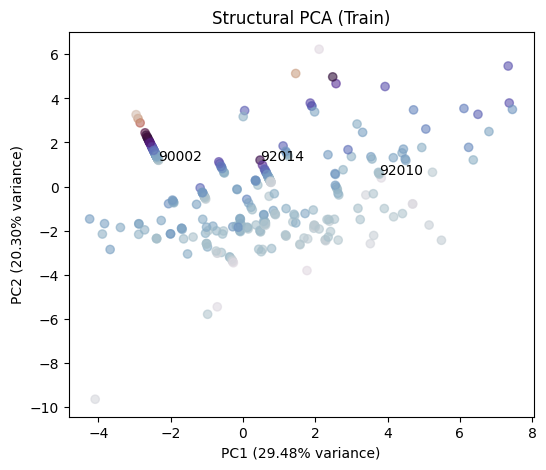

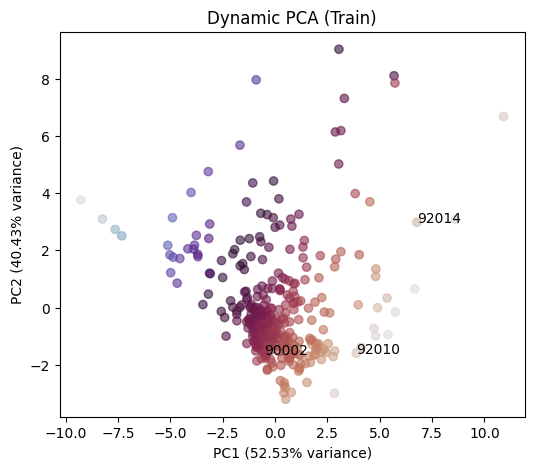

In [156]:
# 35. Unsupervised Models (PCA, K-means, t-sne)

#-----------------------------------------------------------------
#
# Principal Component Analysis (PCA)
#
#-----------------------------------------------------------------

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

#############################################################################################
# 35a. PCA (Structural: how do regions differ in socioeconomic and housing characteristics? affordability)
#          ( Dynamic: do those same regions behave differently over time?)
#############################################################################################

df = panel_final.copy()

# ensure the data is sorted in chronological order by zipcode
df = df.sort_values(["zip_code","date"])

#create time component
df["time"] = df.groupby("zip_code").cumcount()

#------------------ split to train and testing sets -----------------------------------

split_date = pd.Timestamp("2024-01-01")

train_df = df[df["date"] < split_date].copy()
test_df  = df[df["date"] >= split_date].copy()

#------------------ structural and dynamic PCA Dataset ----------------------------------------------
# structural 
struct_features = [
    'median_household_income',
    'per_capita_income', 'poverty_rate', 'unemployment_rate',
    'total_population', 'population_growth', 'median_age',
    'pct_bachelors_or_higher', 'pct_graduate_degree', 'total_housing_units',
    'housing_unit_growth', 'vacancy_rate', 'owner_occupied_rate',
    'pct_built_after_2000', 'pct_single_family_detached',
    'median_home_value_acs', 'median_gross_rent',
    'pct_owners_cost_burdened','price_income_ratio'
]

df_struct = train_df.copy()

# convert % → proportions
# pct_cols = [
#     "poverty_rate",
#     "unemployment_rate",
#     "pct_bachelors_or_higher",
#     "pct_graduate_degree",
#     "vacancy_rate",
#     "owner_occupied_rate"
# ]

# for col in pct_cols:
#     df_struct[col] = df_struct[col] / 100

# aggregate to one row per region
df_struct_region = df_struct.groupby("zip_code")[struct_features].mean().dropna()


# dynamic features 
dyn_features = [
    "growth_3mo",
    "growth_12mo",
    "zhvi_vol_3",
    "zhvi_vol_6",
    "zhvi_vol_12",
    "price_change",
    "price_acceleration",
    "price_vs_roll12",
    "growth_vs_pop"
]

df_dyn = train_df.copy()

df_dyn_region = df_dyn.groupby("zip_code")[dyn_features].mean().dropna()

#---------------------------- PCA ------------------------------------------------
scaler_struct = StandardScaler()
X_struct = scaler_struct.fit_transform(df_struct_region)

pca_struct = PCA(n_components=2)
X_struct_pca = pca_struct.fit_transform(X_struct)



scaler_dyn = StandardScaler()
X_dyn = scaler_dyn.fit_transform(df_dyn_region)

pca_dyn = PCA(n_components=2)
X_dyn_pca = pca_dyn.fit_transform(X_dyn)


#------------------------ Plots -------------------------------------------------

pc1_var = pca_struct.explained_variance_ratio_[0]
pc2_var = pca_struct.explained_variance_ratio_[1]

zips = ["90002", "92014", "92010"]

plt.figure(figsize=(6,5))
plt.scatter(X_struct_pca[:,0], 
            X_struct_pca[:,1], 
            c = df_struct_region["price_income_ratio"],
            cmap = "twilight",
            alpha=0.6)

for i, region in enumerate(df_struct_region.index):
    if region in zips:
        plt.text(
            X_struct_pca[i,0],
            X_struct_pca[i,1],
            region,
            fontsize=10,
            color="black"
        )

plt.title("Structural PCA (Train)")
plt.xlabel(f"PC1 ({pc1_var:.2%} variance)")
plt.ylabel(f"PC2 ({pc2_var:.2%} variance)")
plt.show()

pc1_var = pca_dyn.explained_variance_ratio_[0]
pc2_var = pca_dyn.explained_variance_ratio_[1]

plt.figure(figsize=(6,5))
plt.scatter(X_dyn_pca[:,0], 
            X_dyn_pca[:,1],
            c = df_dyn_region["growth_12mo"],
            cmap = "twilight",
            alpha=0.6
           )
for i, region in enumerate(df_dyn_region.index):
    if region in zips:
        plt.text(
            X_dyn_pca[i,0],
            X_dyn_pca[i,1],
            region,
            fontsize=10,
            color="black"
        )
            
plt.title("Dynamic PCA (Train)")
plt.xlabel(f"PC1 ({pc1_var:.2%} variance)")
plt.ylabel(f"PC2 ({pc2_var:.2%} variance)")
plt.show()

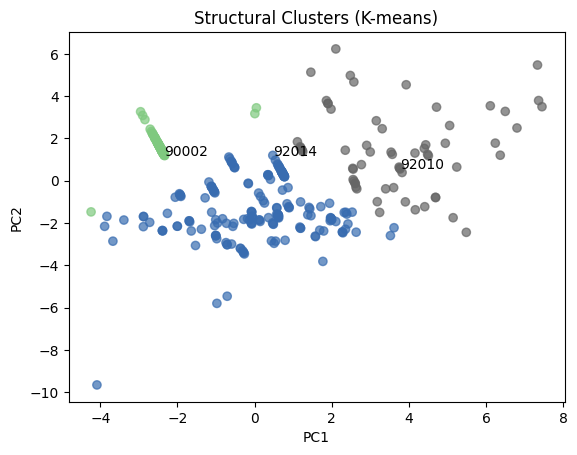

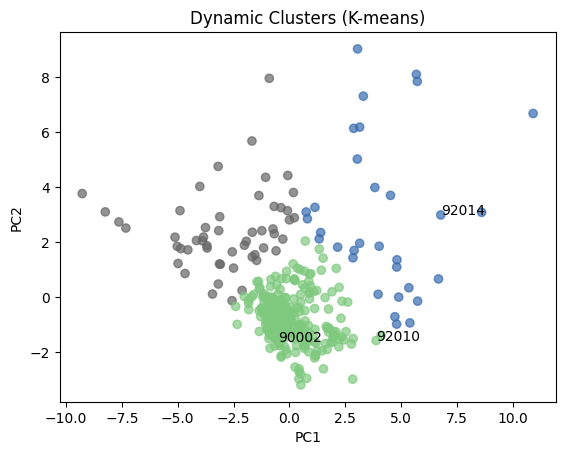

In [157]:
#--------------------------------------------------------------------------

# 35b. K-Means ( Which regions belong in similar clusters?)

#--------------------------------------------------------------------------

from sklearn.cluster import KMeans

X_struct_km = X_struct.copy()
X_dyn_km = X_dyn.copy()

#-------------- K - Means ---------------------------

# structural
kmeans = KMeans(n_clusters=3, random_state=42)
clusters_struct = kmeans.fit_predict(X_struct_km)

df_struct_region["cluster"] = clusters_struct

#dynamic
kmeans = KMeans(n_clusters=3, random_state=42)
clusters_dyn = kmeans.fit_predict(X_dyn_km)

df_dyn_region["cluster"] = clusters_dyn

# structural alignment
df_struct_region = df_struct_region.loc[df_struct_region.index]
# dynamic alignment
df_dyn_region = df_dyn_region.loc[df_dyn_region.index]

#-------------- Plot ------------------------------
zips = ["90002", "92014", "92010"]

plt.scatter(
    X_struct_pca[:,0],
    X_struct_pca[:,1],
    c=clusters_struct,
    cmap="Accent",
    alpha=0.7
)

for i, region in enumerate(df_struct_region.index):
    if region in zips:
        plt.text(
            X_struct_pca[i, 0],
            X_struct_pca[i, 1],
            region,
            fontsize=10
        )

plt.title("Structural Clusters (K-means)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

plt.scatter(
    X_dyn_pca[:,0],
    X_dyn_pca[:,1],
    c=clusters_dyn,
    cmap="Accent",
    alpha=0.7
)

for i, region in enumerate(df_dyn_region.index):
    if region in zips:
        plt.text(
            X_dyn_pca[i, 0],
            X_dyn_pca[i, 1],
            region,
            fontsize=10
        )

plt.title("Dynamic Clusters (K-means)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [158]:
# ============================================================
# 36. Statistical Model Evaluations
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.arima.model import ARIMA
import statsmodels.formula.api as smf

# ------------------------------------------------------------
# Error metric functions
# ------------------------------------------------------------

def calc_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def calc_mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)


# ============================================================
# 36a. Random Walk
# ============================================================

# overall metrics
rw_overall_metrics_df = pd.DataFrame([{
    "Model": "Random Walk",
    "RMSE": calc_rmse(rw_res["zhvi"], rw_res["rw_pred"]),
    "MAE": calc_mae(rw_res["zhvi"], rw_res["rw_pred"])
}])

# metrics by zip code
rw_zip_metrics = []

for zip_code, df_zip in rw_res.groupby("zip_code"):
    rw_zip_metrics.append({
        "zip_code": zip_code,
        "Model": "Random Walk",
        "RMSE": calc_rmse(df_zip["zhvi"], df_zip["rw_pred"]),
        "MAE": calc_mae(df_zip["zhvi"], df_zip["rw_pred"])
    })

rw_zip_metrics_df = pd.DataFrame(rw_zip_metrics)

#print(rw_overall_metrics_df)
#print(rw_zip_metrics_df.head())


# ============================================================
# 36b. ARIMA
# ============================================================

# make sure zip_code and date are in the right format
arima_data = rw_2019_2025.copy()
arima_data["zip_code"] = arima_data["zip_code"].astype(str)
arima_data["date"] = pd.to_datetime(arima_data["date"])

split_date = pd.Timestamp("2024-01-01")

arima_train = arima_data[arima_data["date"] < split_date].copy()
arima_test  = arima_data[arima_data["date"] >= split_date].copy()

zip_codes = ["90002", "92014", "92010"]

arima_results = []
arima_metrics = []

for zip_code in zip_codes:
    train_arima = arima_train[arima_train["zip_code"] == zip_code].copy()
    test_arima  = arima_test[arima_test["zip_code"] == zip_code].copy()

    train_arima = train_arima.sort_values("date").set_index("date")
    test_arima  = test_arima.sort_values("date").set_index("date")

    y_train_arima = train_arima["zhvi"].dropna()
    y_test_arima  = test_arima["zhvi"].dropna()

    if len(y_train_arima) < 10 or len(y_test_arima) == 0:
        print(f"Skipping ZIP {zip_code}: insufficient data")
        continue

    try:
        model1 = ARIMA(y_train_arima, order=(1, 1, 0)).fit()
        model2 = ARIMA(y_train_arima, order=(2, 1, 0)).fit()
        model3 = ARIMA(y_train_arima, order=(1, 1, 1)).fit()

        n_future = len(y_test_arima)

        fc1 = model1.get_forecast(steps=n_future).predicted_mean
        fc2 = model2.get_forecast(steps=n_future).predicted_mean
        fc3 = model3.get_forecast(steps=n_future).predicted_mean

        temp = pd.DataFrame({
            "zip_code": zip_code,
            "date": y_test_arima.index,
            "actual": y_test_arima.values,
            "ARIMA_110_pred": fc1.values,
            "ARIMA_210_pred": fc2.values,
            "ARIMA_111_pred": fc3.values
        })

        arima_results.append(temp)

        arima_metrics.append({
            "zip_code": zip_code,
            "Model": "ARIMA(1,1,0)",
            "RMSE": calc_rmse(y_test_arima, fc1),
            "MAE": calc_mae(y_test_arima, fc1),
            "AIC": model1.aic
        })

        arima_metrics.append({
            "zip_code": zip_code,
            "Model": "ARIMA(2,1,0)",
            "RMSE": calc_rmse(y_test_arima, fc2),
            "MAE": calc_mae(y_test_arima, fc2),
            "AIC": model2.aic
        })

        arima_metrics.append({
            "zip_code": zip_code,
            "Model": "ARIMA(1,1,1)",
            "RMSE": calc_rmse(y_test_arima, fc3),
            "MAE": calc_mae(y_test_arima, fc3),
            "AIC": model3.aic
        })

    except Exception as e:
        print(f"Could not fit ZIP {zip_code}: {e}")

# combine row-level predictions
arima_results_df = pd.concat(arima_results, ignore_index=True)

# zip-level metrics
arima_metrics_df = pd.DataFrame(arima_metrics)

# overall metrics
overall_arima_metrics = []

for model_col, model_name in [
    ("ARIMA_110_pred", "ARIMA(1,1,0)"),
    ("ARIMA_210_pred", "ARIMA(2,1,0)"),
    ("ARIMA_111_pred", "ARIMA(1,1,1)")
]:
    overall_arima_metrics.append({
        "Model": model_name,
        "RMSE": calc_rmse(arima_results_df["actual"], arima_results_df[model_col]),
        "MAE": calc_mae(arima_results_df["actual"], arima_results_df[model_col])
    })

overall_arima_metrics_df = pd.DataFrame(overall_arima_metrics)

#print(arima_results_df.head())
#print(arima_metrics_df.head())
#print(overall_arima_metrics_df)


# ============================================================
# 36c. Linear Mixed Model
# ============================================================

panel_final = panel_final.sort_values(["zip_code", "date"]).copy()
panel_final["zip_code"] = panel_final["zip_code"].astype(str)
panel_final["date"] = pd.to_datetime(panel_final["date"])

# create time index within each ZIP
panel_final["time"] = panel_final.groupby("zip_code").cumcount() + 1

split_date = pd.Timestamp("2024-01-01")

lmm_train = panel_final[panel_final["date"] < split_date].copy()
lmm_test  = panel_final[panel_final["date"] >= split_date].copy()

# variables needed for LMM Model 3
model3_vars = [
    "zip_code",
    "time",
    "date",
    "zhvi",
    "zhvi_lag1",
    "price_income_ratio",
    "pct_bachelors_or_higher"
]

train_m3 = lmm_train[model3_vars].copy()
train_m3["date"] = pd.to_datetime(train_m3["date"])

# log transforms
train_m3["log_zhvi"] = np.where(train_m3["zhvi"] > 0, np.log(train_m3["zhvi"]), np.nan)
train_m3["log_zhvi_lag1"] = np.where(train_m3["zhvi_lag1"] > 0, np.log(train_m3["zhvi_lag1"]), np.nan)

# convert percentage to proportion
# train_m3["pct_bachelors_or_higher"] = train_m3["pct_bachelors_or_higher"] / 100

# scale predictors
scale_cols_m3 = ["price_income_ratio", "pct_bachelors_or_higher"]

scaler_m3 = StandardScaler()
train_m3[scale_cols_m3] = scaler_m3.fit_transform(train_m3[scale_cols_m3])

# clean training data
train_m3 = train_m3.replace([np.inf, -np.inf], np.nan).dropna()

# keep ZIPs with enough observations
group_sizes = train_m3.groupby("zip_code").size()
valid_zips_m3 = group_sizes[group_sizes >= 10].index
train_m3 = train_m3[train_m3["zip_code"].isin(valid_zips_m3)].copy()

# fit LMM model
lmm_model3 = smf.mixedlm(
    "log_zhvi ~ time + log_zhvi_lag1 + price_income_ratio + pct_bachelors_or_higher",
    data=train_m3,
    groups=train_m3["zip_code"],
    re_formula="~time"
)

result3 = lmm_model3.fit(method="lbfgs")

#print(result3.summary())

# prepare test data
test_m3 = lmm_test[[
    "zip_code",
    "date",
    "zhvi",
    "time",
    "zhvi_lag1",
    "price_income_ratio",
    "pct_bachelors_or_higher"
]].copy()

test_m3["zip_code"] = test_m3["zip_code"].astype(str)
test_m3["date"] = pd.to_datetime(test_m3["date"])

# keep only ZIPs from training
test_m3 = test_m3[test_m3["zip_code"].isin(valid_zips_m3)].copy()

# convert percentage to proportion
# test_m3["pct_bachelors_or_higher"] = test_m3["pct_bachelors_or_higher"] / 100

test_m3 = test_m3.sort_values(["zip_code", "date"]).copy()

# forecasts
lmm3_forecasts = []

for zip_code in test_m3["zip_code"].unique():
    test_zip = test_m3[test_m3["zip_code"] == zip_code].sort_values("date").copy()

    if len(test_zip) == 0:
        continue

    # need positive lag values for log transform
    test_zip = test_zip[test_zip["zhvi_lag1"] > 0].copy()
    if len(test_zip) == 0:
        continue

    test_zip["log_zhvi_lag1"] = np.log(test_zip["zhvi_lag1"])

    # scale predictors using training scaler
    exog_raw = test_zip[["price_income_ratio", "pct_bachelors_or_higher"]].copy()
    exog_scaled = scaler_m3.transform(exog_raw)

    test_zip["price_income_ratio"] = exog_scaled[:, 0]
    test_zip["pct_bachelors_or_higher"] = exog_scaled[:, 1]

    # prediction dataframe
    pred_row = test_zip[[
        "time",
        "log_zhvi_lag1",
        "price_income_ratio",
        "pct_bachelors_or_higher"
    ]].copy()

    # predict in log scale
    log_preds = result3.predict(pred_row)

    # convert back to original dollar scale
    zhvi_preds = np.exp(log_preds)

    temp = pd.DataFrame({
        "zip_code": test_zip["zip_code"].values,
        "date": test_zip["date"].values,
        "actual": test_zip["zhvi"].values,
        "LMM3_pred": zhvi_preds.values
    })

    lmm3_forecasts.append(temp)

lmm3_results_df = pd.concat(lmm3_forecasts, ignore_index=True)

#print(lmm3_results_df.head())

# overall metrics
lmm3_overall_metrics_df = pd.DataFrame([{
    "Model": "LMM Model 3",
    "RMSE": calc_rmse(lmm3_results_df["actual"], lmm3_results_df["LMM3_pred"]),
    "MAE": calc_mae(lmm3_results_df["actual"], lmm3_results_df["LMM3_pred"])
}])

# zip-level metrics
lmm3_zip_metrics = []

for zip_code, df_zip in lmm3_results_df.groupby("zip_code"):
    lmm3_zip_metrics.append({
        "zip_code": zip_code,
        "Model": "LMM Model 3",
        "RMSE": calc_rmse(df_zip["actual"], df_zip["LMM3_pred"]),
        "MAE": calc_mae(df_zip["actual"], df_zip["LMM3_pred"])
    })

lmm3_zip_metrics_df = pd.DataFrame(lmm3_zip_metrics)

#print(lmm3_overall_metrics_df)
#print(lmm3_zip_metrics_df.head())

C:\Users\bphul\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\bphul\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\bphul\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\bphul\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\bphul\AppData\Local\Programs\Python\Python313\L

In [159]:
# ============================================================
# 36d. Combine model evaluation tables
# ============================================================

# overall comparison table
overall_model_comparison = pd.concat([
    rw_overall_metrics_df,
    overall_arima_metrics_df,
    lmm3_overall_metrics_df
], ignore_index=True)

# zip-level comparison table
zip_model_comparison = pd.concat([
    rw_zip_metrics_df,
    arima_metrics_df[["zip_code", "Model", "RMSE", "MAE"]],
    lmm3_zip_metrics_df
], ignore_index=True)

print("Overall Model Comparison")
print(overall_model_comparison)

Overall Model Comparison
          Model          RMSE           MAE
0   Random Walk  52938.300764  29992.918707
1  ARIMA(1,1,0)  59753.075610  46438.239266
2  ARIMA(2,1,0)  59454.856997  46174.355738
3  ARIMA(1,1,1)  73969.331663  60039.204483
4   LMM Model 3  74285.223988  27048.175170


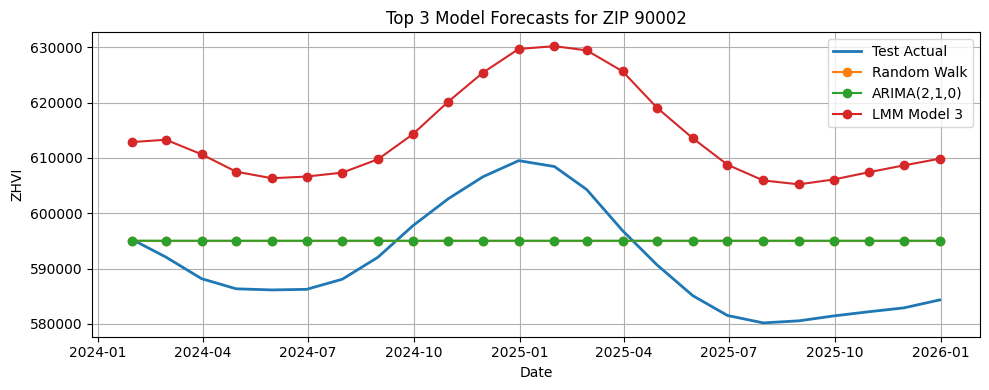

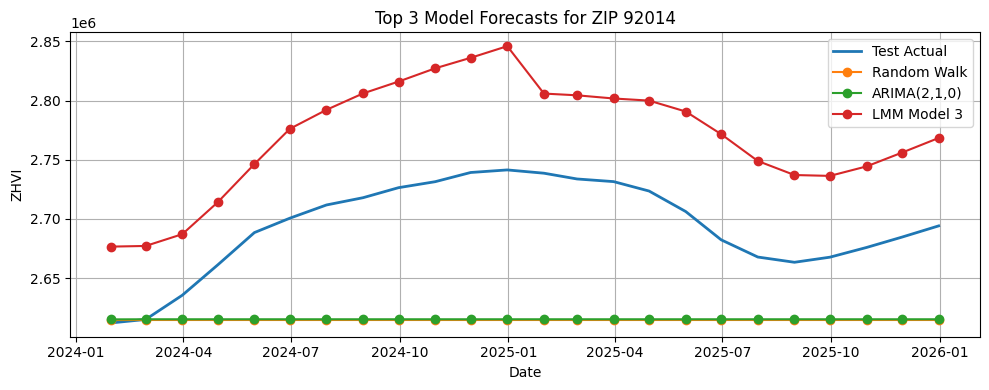

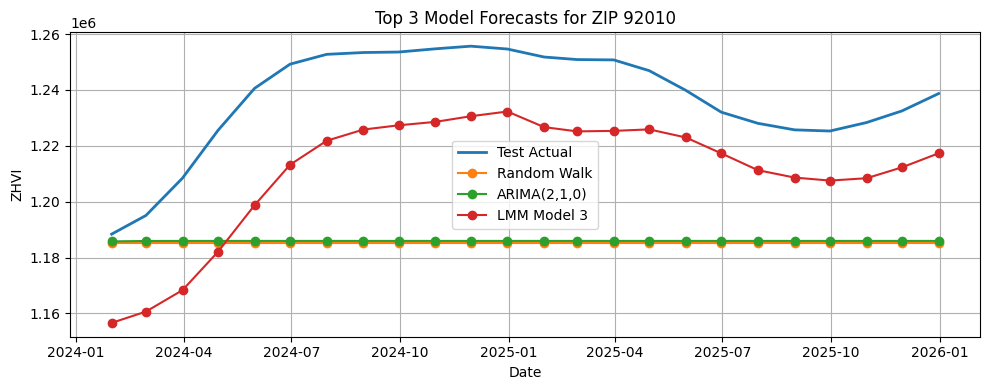

In [160]:
# 37. Forecast Plots of top 3 models

# Random Walk
rw_plot_df = rw_res[["zip_code", "date", "zhvi", "rw_pred"]].copy()
rw_plot_df = rw_plot_df.rename(columns={
    "zhvi": "actual",
    "rw_pred": "pred"
})
rw_plot_df["Model"] = "Random Walk"

# ARIMA(2,1,0)
arima210_plot_df = arima_results_df[["zip_code", "date", "actual", "ARIMA_210_pred"]].copy()
arima210_plot_df = arima210_plot_df.rename(columns={
    "ARIMA_210_pred": "pred"
})
arima210_plot_df["Model"] = "ARIMA(2,1,0)"

# LMM Model 3
lmm3_plot_df = lmm3_results_df[["zip_code", "date", "actual", "LMM3_pred"]].copy()
lmm3_plot_df = lmm3_plot_df.rename(columns={
    "LMM3_pred": "pred"
})
lmm3_plot_df["Model"] = "LMM Model 3"

# Combine all top 3 models
top3_plot_df = pd.concat(
    [rw_plot_df, arima210_plot_df, lmm3_plot_df],
    ignore_index=True
)

top3_plot_df["date"] = pd.to_datetime(top3_plot_df["date"])

zip_list = ["90002", "92014", "92010"]
split_date = pd.to_datetime("2024-01-01")

 # by zipcodes
zip_list = ["90002", "92014", "92010"]

for zip_code in zip_list:
    plt.figure(figsize=(10, 4))

    actual_zip = panel_final[panel_final["zip_code"] == zip_code].copy()
    actual_zip["date"] = pd.to_datetime(actual_zip["date"])
    actual_zip = actual_zip.sort_values("date")
    actual_zip = actual_zip[actual_zip["date"] >= split_date]

    plt.plot(actual_zip["date"], actual_zip["zhvi"], label="Test Actual", linewidth=2)

    pred_zip = top3_plot_df[top3_plot_df["zip_code"] == zip_code].copy()

    for model_name in ["Random Walk", "ARIMA(2,1,0)", "LMM Model 3"]:
        model_df = pred_zip[pred_zip["Model"] == model_name].sort_values("date")
        plt.plot(model_df["date"], model_df["pred"], label=model_name, marker="o")

    plt.title(f"Top 3 Model Forecasts for ZIP {zip_code}")
    plt.xlabel("Date")
    plt.ylabel("ZHVI")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()